# Connectome Analyses (Square Proofread Connectome)

# Setup

## Imports

In [1]:
# IMPORTS
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from itertools import product
from scipy import stats, special
import seaborn as sns
import networkx as nx
import pickle
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import norm, chi2_contingency, chisquare
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any
import warnings, time, random
from pathlib import Path
#from funconnect.utility import proximities as prx
from scipy.spatial import cKDTree

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

warnings.filterwarnings("ignore")

## Functions

### Connection Type Definitions

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

def assembly(pre, post, A):
    return (pre not in no_A) and (post not in no_A)
    
# def assembly(pre, post, A):
#     try:
#         return not A[pre].isdisjoint(A[post])
#     except KeyError:
#         return False

def nonassembly(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

comparison_functions = [assembly, nonassembly]
all_connection_types = ['assembly', 'nonassembly']
focused_connection_types = ['assembly', 'nonassembly']

### Effect Size Bootstrapped

In [3]:
# EFFECT SIZES BOOTSTRAPPED

# helpers
def _dir_from_alt(alternative: str) -> int:
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    sk = set(comparison_dict.get('assembly', {}).keys())
    dk = set(comparison_dict.get('nonassembly', {}).keys())
    common = sorted(sk & dk)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["assembly"][k] for k in common], float)
    d = np.array([comparison_dict["nonassembly"][k] for k in common], float)
    z = s - d
    return s, d, z

# ---------- effect sizes ----------

def cohens_d(assembly, nonassembly, *, alternative="greater", paired=False) -> float:
    s = np.asarray(assembly, float); d = np.asarray(nonassembly, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        return sign * (np.mean(z) / sd)

    n1, n2 = s.size, d.size
    if n1 < 2 or n2 < 2:
        return np.nan
    sp2 = ((n1 - 1)*np.var(s, ddof=1) + (n2 - 1)*np.var(d, ddof=1)) / (n1 + n2 - 2)
    sp = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return sign * ((np.mean(s) - np.mean(d)) / sp)


def hodges_lehmann(assembly, nonassembly, *, alternative="greater", paired=False,
                   max_pairs=5_000_000, rng=None, approx_pairs=2_000_000) -> float:
    s = np.asarray(assembly, float); d = np.asarray(nonassembly, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        return float(sign * np.median(s - d))

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan

    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()
        base = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k = int(min(approx_pairs, total))
        diffs = s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)

    return float(sign * base)

def ps_and_delta(assembly, nonassembly, *, alternative="greater", paired=False,
                 eps=0.0) -> Tuple[float, float]:
    s = np.asarray(assembly, float); d = np.asarray(nonassembly, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n   # P(z>0)+0.5P(z=0)
        delta= 2.0*A_sh - 1.0
        return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    U_sh, _ = stats.mannwhitneyu(s, d, alternative="greater")
    A_sh = U_sh / (n1 * n2)
    delta = 2.0*A_sh - 1.0
    return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)


# ---------- BCa CI implementation (generic) ----------

def _phi_inv(p: float) -> float:
    """
    Inverse CDF (quantile) for the standard normal distribution.
    Uses scipy.stats.norm.ppf for stability.
    """
    return stats.norm.ppf(p)

def _bca_ci_from_boot_and_jack(theta_hat: float, boot: np.ndarray, jack: np.ndarray, alpha=0.05) -> Tuple[float, float]:
    boot = np.asarray(boot, float)
    jack = np.asarray(jack, float)
    B = np.isfinite(boot).sum()
    if B == 0 or jack.size == 0:
        return (np.nan, np.nan)

    # bias-correction z0
    prop_lt = np.mean(boot < theta_hat)
    z0 = _phi_inv(prop_lt)

    # acceleration a via jackknife influence
    jack_mean = np.mean(jack)
    u = jack_mean - jack
    num = np.sum(u**3)
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # adjusted quantiles
    al = alpha/2
    au = 1 - alpha/2
    z_al = _phi_inv(al)
    z_au = _phi_inv(au)

    adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
    adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))

    lo = np.quantile(boot, adj_al, method="nearest")
    hi = np.quantile(boot, adj_au, method="nearest")
    return (float(lo), float(hi))


def _jackknife_stat(effect_fn, s: np.ndarray, d: np.ndarray, *, paired: bool, alternative: str) -> np.ndarray:
    # Leave-one-out across the combined data (pairs as units when paired)
    if paired:
        n = s.size
        out = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            out[i] = effect_fn(s[mask], d[mask], alternative=alternative, paired=True)
        return out
    else:
        n1, n2 = s.size, d.size
        out = np.empty(n1 + n2)
        # leave-one-out from group 1
        for i in range(n1):
            out[i] = effect_fn(np.delete(s, i), d, alternative=alternative, paired=False)
        # leave-one-out from group 2
        for j in range(n2):
            out[n1 + j] = effect_fn(s, np.delete(d, j), alternative=alternative, paired=False)
        return out


def _ci_wrapper(theta_hat, boot_vals, jack_vals, alpha, method="bca"):
    boot_vals = np.asarray(boot_vals)
    if method == "percentile" or jack_vals.size == 0:
        return (float(np.percentile(boot_vals, 2.5)),
                float(np.percentile(boot_vals, 97.5)))
    elif method == "bca":
        try:
            return _bca_ci_from_boot_and_jack(theta_hat, boot_vals, jack_vals, alpha)
        except ValueError:
            # fallback if adjusted quantiles go out of bounds
            return (float(np.percentile(boot_vals, 2.5)),
                    float(np.percentile(boot_vals, 97.5)))


# ---------- main: bootstrap + reporting ----------

def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 10_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(list(comparison_dict["assembly"].values()), float)
        d = np.array(list(comparison_dict["nonassembly"].values()), float)
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.ranksums(s, d, alternative=alt)
        p_point = float(mw.pvalue)
        median_info = f"Assembly median = {np.median(s):.6g}, Nonassembly median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

### Testing and Visualization

#### Save Functions

In [4]:
# SAVING
SAVE_DIR = Path("master_outputs/square/figures/a_noa/scan_13")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DIR_SETS = Path("master_outputs/square/sets/a_noa/scan_13")
SAVE_DIR_SETS.mkdir(parents=True, exist_ok=True)

# sets (batch)
def dump_dicts_to_folder(SAVE_DIR_SETS, **objects):
    Path(SAVE_DIR_SETS).mkdir(parents=True, exist_ok=True)
    for name, obj in objects.items():
        with open(Path(SAVE_DIR_SETS) / f"{name}.pkl", "wb") as f:
            pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)

# figures
def save_figure(figure_name):
        plt.savefig(
        SAVE_DIR / f"{figure_name}.pdf",
        dpi=500)

#### Binary Data

In [5]:
def build_2x2_table(y, group):
    df = pd.DataFrame({"y": y, "group": group})

    tab = (
        df.groupby(["group", "y"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=["assembly", "nonassembly"], columns=[1, 0], fill_value=0)
        .rename(columns={1: "Conn", 0: "No Conn"})
    )

    tab["Total"] = tab.sum(axis=1)
    tab["p_hat"] = tab["Conn"] / tab["Total"]
    tab.index = ["assembly", "nonassembly"]
    return tab

# ============================================================
# Chi-squared test with conditional Yates (expected < 5)
# ============================================================
def chi2_test(tab):
    obs = tab.loc[["assembly", "nonassembly"], ["Conn", "No Conn"]].to_numpy()

    chi2_nc, p_nc, dof, exp = stats.chi2_contingency(obs, correction=True)
    use_yates = np.any(exp < 5)

    if use_yates:
        chi2, p, dof, exp = stats.chi2_contingency(obs, correction=True)
    else:
        chi2, p, dof = chi2_nc, p_nc, dof

    return {
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "expected": exp,
        "yates": use_yates,
        "n": int(obs.sum()),
    }

# ============================================================
# Effect sizes: RD + RR
# ============================================================
def effect_sizes(tab):
    a, b = tab.loc["assembly", ["Conn", "No Conn"]]
    c, d = tab.loc["nonassembly", ["Conn", "No Conn"]]

    p_s = a / (a + b)
    p_d = c / (c + d)

    return {
        "p_assembly": p_s,
        "p_nonassembly": p_d,
        "RD": p_s - p_d,
        "RR": p_s / p_d if p_d > 0 else np.nan,
    }

# ============================================================
# BCa CI
# ============================================================
def bca_ci(theta_hat, boot, jack, alpha=0.05):
    boot = np.asarray(boot)
    jack = np.asarray(jack)

    prop = np.clip(np.mean(boot < theta_hat), 1e-6, 1 - 1e-6)
    z0 = stats.norm.ppf(prop)

    jack_mean = jack.mean()
    u = jack_mean - jack
    denom = np.sum(u**2)
    a = np.sum(u**3) / (6 * denom**1.5) if denom > 0 else 0.0

    z_lo, z_hi = stats.norm.ppf(alpha / 2), stats.norm.ppf(1 - alpha / 2)

    pct_lo = stats.norm.cdf(z0 + (z0 + z_lo) / (1 - a * (z0 + z_lo)))
    pct_hi = stats.norm.cdf(z0 + (z0 + z_hi) / (1 - a * (z0 + z_hi)))

    return np.quantile(boot, pct_lo), np.quantile(boot, pct_hi)

# ============================================================
# Pair-level BCa bootstrap runner
# ============================================================
def run_pairwise_chi2_BCa(y, group, *, B=10_000, seed=747):
    rng = default_rng(seed)

    y = np.asarray(y, dtype=int)
    group = np.asarray(group)
    n = len(y)

    # Point estimate
    tab_hat = build_2x2_table(y, group)
    chi2_hat = chi2_test(tab_hat)
    eff_hat = effect_sizes(tab_hat)

    # Bootstrap
    rd_b = np.empty(B)
    rr_b = np.empty(B)

    for i in range(B):
        idx = rng.integers(0, n, size=n)
        tab_b = build_2x2_table(y[idx], group[idx])
        eff_b = effect_sizes(tab_b)
        rd_b[i] = eff_b["RD"]
        rr_b[i] = eff_b["RR"]

    # Jackknife
    rd_j, rr_j = [], []
    for i in range(n):
        keep = np.arange(n) != i
        tab_j = build_2x2_table(y[keep], group[keep])
        eff_j = effect_sizes(tab_j)
        rd_j.append(eff_j["RD"])
        rr_j.append(eff_j["RR"])

    return {
        "table": tab_hat,
        "chi2": chi2_hat,
        "effect": eff_hat,
        "CI95_BCa": {
            "RD": bca_ci(eff_hat["RD"], rd_b, rd_j),
            "RR": bca_ci(eff_hat["RR"], rr_b, rr_j),
        },
    }

# ============================================================
# Output: print + plot/save
# ============================================================
def pretty_print(out, title):
    tab = out["table"]
    chi2 = out["chi2"]
    eff = out["effect"]
    ci = out.get("CI95_BCa", None)


    print(f"\n{title}")
    print(
        f"Chi-squared test (Yates={chi2['yates']}): "
        f"χ²={chi2['chi2']:.4g}, dof={chi2['dof']}, n={chi2['n']}, p={chi2['p_value']:.4g}"
    )

    # ---- Effect sizes ----
    if ci is not None:
        print("\nEffect sizes (95% BCa CI):")
        print(
            f"  Risk difference (pp): {100*eff['RD']:.3f} "
            f"[{100*ci['RD'][0]:.3f}, {100*ci['RD'][1]:.3f}]"
        )
        print(
            f"  Risk ratio: {eff['RR']:.3f} "
            f"[{ci['RR'][0]:.3f}, {ci['RR'][1]:.3f}]"
        )
    else:
        print("\nEffect sizes:")
        print(f"  Risk difference (pp): {100*eff['RD']:.3f}")
        print(f"  Risk ratio: {eff['RR']:.3f}")

def plot_and_save_contingency(tab, title, p_value, save_name):
    disp = tab.copy()
    disp["p̂ (%)"] = (100 * disp["p_hat"]).round(2)
    disp = disp[["Conn", "No Conn", "Total", "p̂ (%)"]]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.axis("off")

    table = ax.table(
        cellText=disp.values,
        rowLabels=disp.index,
        colLabels=disp.columns,
        cellLoc="center",
        loc="center",
        bbox=[0.02, 0.0, 0.96, 0.78],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(20)
    table.scale(1.4, 2.0)

    ax.set_title(f"{title}\nχ² test: p = {p_value:.3g}", fontsize=28)

    save_figure(save_name)  # <-- your function
    plt.show()
    plt.close()

# ============================================================
# Construct y/group for MONOSYNAPTIC (B_pairwise already includes all pairs)
# ============================================================
def build_y_group_monosynaptic(B_pairwise):
    y, group = [], []
    for comp in ["assembly", "nonassembly"]:
        for pair, v in B_pairwise[comp].items():
            y.append(int(v))
            group.append(comp)
    return np.array(y, dtype=int), np.array(group)

# ============================================================
# Construct y/group for CHAINS
# - denominator: all pairs in B_pairwise[comp]
# - numerator: realized pairs in R_pairwise_chain[chain_group][comp]
# ============================================================
def build_y_group_chains(B_pairwise, R_pairwise_chain, chain_group):
    y, group = [], []

    realized_shared = set(R_pairwise_chain[chain_group]["assembly"].keys())
    realized_disjoint = set(R_pairwise_chain[chain_group]["nonassembly"].keys())

    # Shared: iterate ONLY over the shared denominator pairs
    for pair in B_pairwise["assembly"].keys():
        y.append(int(pair in realized_shared))
        group.append("assembly")

    # Disjoint: iterate ONLY over the disjoint denominator pairs
    for pair in B_pairwise["nonassembly"].keys():
        y.append(int(pair in realized_disjoint))
        group.append("nonassembly")

    return np.array(y, dtype=int), np.array(group)

#### Continuous Data

In [6]:
def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values[shared_values > 0])
    disjoint_log = np.log10(disjoint_values[disjoint_values > 0])

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
    y="Values",
    x="Group",
    hue="Group",
    data=data,
    palette=[(.4, .6, .8, .5), 'grey'],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v",
    ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(
    ax_main,
    pairs,
    data=data,
    x="Group",
    y="Values",
    order=y_labels
)
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Assembly", "NonAssembly"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()

def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Weight by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Weight (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            if data_type == 'synaptic_count':
                title = f"{chain_description} Chain Synaptic Count"
                y_lab = "Synaptic Counts"
            elif data_type == 'summed_psd':
                title = f"{chain_description} Chain Weight Product"
                y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} {chain_description} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} {chain_description} Chain Weight Product by Cell"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'synaptic_count':
            title = f"Average Nonzero {directionality.capitalize()} {chain_description} Chain Synaptic Count by Cell"
            y_lab = "Synaptic Counts" 

    shared_values = np.array(list(comparison_dict["assembly"].values()))
    disjoint_values = np.array(list(comparison_dict["nonassembly"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('assembly', {}).keys())
        disjoint_keys = set(comparison_dict.get('nonassembly', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    # plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)
    return {
        "p_value": rank_sum_p,
        "alternative": "less" if chain_description == "Inhibitory" else "greater",
        "statistic": rank_sum_stat,
        "n_shared": len(shared_values),
        "n_disjoint": len(disjoint_values),
    }

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None, nonzero = False):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if nonzero == True:
        values = [v for v in values if v > 0]
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )
    if nonzero == True:
        plt.title(f'Histogram of Nonzero Synaptic Counts for {connection_type.capitalize()} Connections')
    else:
        plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    if save and figure_name is not None:
        save_figure(figure_name)

    plt.show()
    plt.close()

In [7]:
def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Assembly\n(n={n_shared})", f"NonAssembly\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values[shared_values > 0])
    disjoint_log = np.log10(disjoint_values[disjoint_values > 0])

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
    y="Values",
    x="Group",
    hue="Group",
    data=data,
    palette=[(.4, .6, .8, .5), 'grey'],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v",
    ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(
    ax_main,
    pairs,
    data=data,
    x="Group",
    y="Values",
    order=y_labels
)
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Assembly", "NonAssembly"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()

def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Weight by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Weight (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Products"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} {chain_description} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} {chain_description} Chain Weight Product by Cell"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'synaptic_count':
            title = f"Average Nonzero {directionality.capitalize()} {chain_description} Chain Synaptic Count by Cell"
            y_lab = "Synaptic Counts" 

    shared_values = np.array(list(comparison_dict["assembly"].values()))
    disjoint_values = np.array(list(comparison_dict["nonassembly"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["assembly"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["nonassembly"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    # plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)
    return {
        "p_value": rank_sum_p,
        "alternative": "less" if chain_description == "Inhibitory" else "greater",
        "statistic": rank_sum_stat,
        "n_shared": len(shared_values),
        "n_disjoint": len(disjoint_values),
    }

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None, nonzero = False):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if nonzero == True:
        values = [v for v in values if v > 0]
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )
    if nonzero == True:
        plt.title(f'Histogram of Nonzero Synaptic Counts for {connection_type.capitalize()} Connections')
    else:
        plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    if save and figure_name is not None:
        save_figure(figure_name)

    plt.show()
    plt.close()

#### Centrality

In [8]:
# same plotting to centrality
def centrality_bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(comparison_dict["All A"])
        d = np.array(comparison_dict["No A"])
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.ranksums(s, d, alternative=alt)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

def produce_centrality_plot(input_centrality_dict: dict,
                                     just_pyramidal=False,
                                     outdegree=False,
                                     indegree=False, 
                                     closeness=False, 
                                     betweenness=False,
                                     save=False,
                                     figure_name=None):
    """
    Produces a raincloud plot for centrality metrics.

    Parameters:
        input_centrality_dict (dict): Dictionary containing centrality values.
        just_pyramidal (bool): Whether to filter to pyramidal cells only.
        outdegree (bool): Whether to use outdegree centrality.
        indegree (bool): Whether to use indegree centrality.
        closeness (bool): Whether to use closeness centrality.
        betweenness (bool): Whether to use betweenness centrality.

    Returns:
        None
    """
    if outdegree and indegree:
        raise ValueError("Must either be working with outdegree or indegree.")
    if closeness and betweenness:
        raise ValueError("Must either be working with closeness or betweenness.")
    if (outdegree or indegree) and (closeness or betweenness):
        raise ValueError("Must either be working with directionality (indegree/outdegree) or higher-order (betweenness/closeness).")

    suffix = "of Co-Registered Cells"

    # Based on the connectome flags, set the correct y_label and plot title
    if outdegree:
        centrality_desc = "Outdegree_Centrality"
        suffix = "Outdegree Centrality " + suffix
        y_lab = "Outdegree Centrality"
    elif indegree:
        centrality_desc = "Indegree_Centrality"
        suffix = "Indegree Centrality " + suffix
        y_lab = "Indegree Centrality"
    elif closeness: 
        centrality_desc = "Closeness_Centrality"
        suffix = "Closeness Centrality " + suffix
        y_lab = "Closeness Centrality"
    elif betweenness:
        centrality_desc = "Betweenness_Centrality"
        suffix = "Betweenness Centrality " + suffix
        y_lab = "Betweenness Centrality"
    else:
        raise ValueError("Must Specify Degree")

    centrality_dict = {}
    for key in input_centrality_dict.keys():
        centrality_dict[key] = np.array(input_centrality_dict[key])

    all_arr = [centrality_dict['All A'], centrality_dict['No A']]
    result = stats.ranksums(centrality_dict['All A'], centrality_dict['No A'], 'greater')
    print(f"Rank-Sum Test (unpaired, All A > No A):\nStatistic: {result.statistic:.4g}, P-value: {result.pvalue:.4g}")
    centrality_bootstrap_effects_and_p(input_centrality_dict, alternative='greater')

    # Calculate sample sizes
    n_all_a = len(centrality_dict['All A'])
    n_no_a = len(centrality_dict['No A'])

    # Create a figure
    plt.figure(figsize=(12,10))
    sns.set_theme(style="whitegrid")

    # Prepare data for raincloud plot
    data = pd.DataFrame({
        "Values": np.concatenate(all_arr),
        "Group": [f"Assembly\n(n={n_all_a})"] * len(centrality_dict['All A']) + \
                 [f"Non-Assembly\n(n={n_no_a})"] * len(centrality_dict['No A'])
    })

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  # Adjust violin width
        alpha=0.8,  # Transparency of the cloud
        move=0.25,  # Adjust position of violins
        point_size = 6,
        orient="v"  # Horizontal orientation
    )

    # Set markings for significance
    y_labels = [f"Assembly\n(n={n_all_a})", f"Non-Assembly\n(n={n_no_a})"]
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([result.pvalue])
    annot.configure(text_format="star", loc="inside", fontsize=32)
    annot.annotate()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(32)

    # Add a multiline title to include the p-value, add y_label
    title = f'{suffix}\nRank-Sum P-value: {result.pvalue:.2g}'
    plt.title(title, size=32)
    plt.ylabel(y_lab, size=32)
    plt.xticks(fontsize=32)  # Adjust size of xticks
    plt.yticks(fontsize=32)  # Adjust size of yticks
    plt.xlabel("Assigned Assembly Status", size=32)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

### Cotravel

In [9]:
# # COTRAVEL
# CACHE_DIR = Path("data_files/v1dd/structural/742/skeletons")
# CACHE_DIR.mkdir(parents=True, exist_ok=True)

# def plot_cotravel(axon_disc_verts, axon_disc_edges,
#                   dend_disc_verts, dend_disc_edges,
#                   proximity_data=None, dend_edges_prx=None):
#     """
#     3D plot showing discretized axon (red), dendrite (green),
#     and proximal co-travel regions (black).
#     """

#     fig = plt.figure(figsize=(8, 8))
#     ax = fig.add_subplot(111, projection="3d")

#     # --- Plot axon (red) ---
#     for e0, e1 in axon_disc_edges:
#         ax.plot(*(axon_disc_verts[[e0, e1]].T / 1000),
#                 color='r', lw=0.6, alpha=0.5)

#     # --- Plot dendrite (green) ---
#     for e0, e1 in dend_disc_edges:
#         ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
#                 color='g', lw=0.6, alpha=0.5)

#     # --- Highlight proximity region (black, thicker) ---
#     if proximity_data and dend_edges_prx is not None and len(dend_edges_prx) > 0:
#         for e0, e1 in dend_edges_prx:
#             ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
#                     color='k', lw=1.5, alpha=1.0)

#     # --- Determine global limits with padding ---
#     all_points = np.vstack([axon_disc_verts, dend_disc_verts]) / 1000
#     mins, maxs = all_points.min(axis=0), all_points.max(axis=0)
#     center = (mins + maxs) / 2
#     zoom = 150
#     ax.set_xlim(center[0] - zoom, center[0] + zoom)
#     ax.set_ylim(center[1] - zoom, center[1] + zoom)
#     ax.set_zlim(center[2] - zoom, center[2] + zoom)

#     # --- Axis labels and view ---
#     ax.set_xlabel("X (µm)")
#     ax.set_ylabel("Y (µm)")
#     ax.set_zlabel("Z (µm)")
#     ax.set_title("Axonal Pre-Cell Skeleton – Dendritic Post-Cell Skeleton")

#     # --- Legend with color-coded labels ---
#     handles = [
#         plt.Line2D([0], [0], color='r', lw=2, label='Axon'),
#         plt.Line2D([0], [0], color='g', lw=2, label='Dendrite '),
#         plt.Line2D([0], [0], color='k', lw=2, label='Proximity')
#     ]
#     ax.legend(handles=handles, loc='upper right', frameon=False)

#     ax.view_init(elev=30, azim=45)
#     plt.tight_layout()
#     plt.show()

# def compute_cotravel_length(
#     pre_id,
#     post_id,
#     radius=5000,
#     max_len=1000,
#     plot=False
# ):
#     """
#     Compute dendritic co-travel distance between an axonal pre-cell skeleton → dendritic post-cell skeleton pair

#     Parameters
#     ----------
#     pre_id : int
#         Presynaptic root ID. Uses cached axon skeleton.
#     post_id : int
#         Postsynaptic root ID. Uses cached dendrite skeleton.
#     radius : float
#         Proximity radius in nanometers. Default = 5000 nm (5 µm).
#     max_len : float
#         Max discretized segment length in nm. Default = 1000 nm
#     plot : bool
#         If True, plot cotravel in 3D

#     Returns
#     -------
#     dend_cotravel_nm : float
#         Total dendritic co-travel distance in nanometers.
#     """

#     try:
#         # ------------------------------------------------------
#         # Load cached skeletons
#         # ------------------------------------------------------
#         npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
#         npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

#         # Axon skeleton from pre cell
#         axon_verts = npz_pre["coords_ax"]
#         axon_edges = npz_pre["edges_ax"]

#         # Dendrite skeleton from post cell
#         dend_verts = npz_post["coords_de"]
#         dend_edges = npz_post["edges_de"]

#         # print(f"✅ Loaded cached skeletons:")
#         # print(f"    Pre (axon): {pre_id} — {axon_verts.shape[0]} verts")
#         # print(f"    Post (dend): {post_id} — {dend_verts.shape[0]} verts")

#         # Edge case: no skeleton
#         if axon_verts.size == 0 or dend_verts.size == 0:
#             # print("⚠️ One or both skeletons empty → cotravel = 0")
#             return 0

#         # ------------------------------------------------------
#         # Discretize both skeletons
#         # ------------------------------------------------------
#         axon_segments = axon_verts[axon_edges]
#         dend_segments = dend_verts[dend_edges]

#         axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
#         dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

#         axon_disc_verts, axon_disc_edges = prx.convert_skeleton_to_nodes_edges(axon_disc)
#         dend_disc_verts, dend_disc_edges = prx.convert_skeleton_to_nodes_edges(dend_disc)

#         # ------------------------------------------------------
#         # Compute proximities
#         # ------------------------------------------------------
#         proximity_data = prx.compute_proximities(axon_disc_verts, dend_disc_verts, radius=radius)

#         if not proximity_data:
#             # print(f"  No proximities found for ({pre_id} → {post_id})")
#             return 0

#         axon_prx_inds = np.unique(proximity_data["verts1_inds_prx"])
#         dend_prx_inds = np.unique(proximity_data["verts2_inds_prx"])

#         axon_disc_edges_prx = prx.filter_edges(axon_disc_edges, axon_prx_inds)
#         dend_disc_edges_prx = prx.filter_edges(dend_disc_edges, dend_prx_inds)

#         # ------------------------------------------------------
#         # Compute cotravel length
#         # ------------------------------------------------------
#         axon_len_prx = prx.compute_skeletal_length(axon_disc_verts, axon_disc_edges_prx)
#         dend_len_prx = prx.compute_skeletal_length(dend_disc_verts, dend_disc_edges_prx)

#         # print(f"✅ Co-travel for ({pre_id} → {post_id}):")
#         # print(f"    Axonal  co-travel = {axon_len_prx:.1f} nm")
#         # print(f"    Dendritic co-travel = {dend_len_prx:.1f} nm")

#         if plot:
#             plot_cotravel(
#                 axon_disc_verts, axon_disc_edges,
#                 dend_disc_verts, dend_disc_edges,
#                 proximity_data=proximity_data,
#                 dend_edges_prx=dend_disc_edges_prx
#             )

#         return dend_len_prx

#     except Exception as e:
#         # print(f"❌ compute_cotravel_length_cached failed for ({pre_id}, {post_id}): {e}")
#         return 0
    

# def compute_min_distance(pre_id, post_id, max_len=1000):
#     """
#     Compute the minimum Euclidean distance (nm) between discretized
#     axonal and dendritic skeleton vertices.

#     This is *independent* of compute_cotravel_length().
#     """

#     try:
#         # Load cached skeletons
#         npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
#         npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

#         axon_verts = npz_pre["coords_ax"]
#         axon_edges = npz_pre["edges_ax"]

#         dend_verts = npz_post["coords_de"]
#         dend_edges = npz_post["edges_de"]

#         if axon_verts.size == 0 or dend_verts.size == 0:
#             return np.inf

#         # Discretize skeletons (same logic as cotravel code)
#         axon_segments = axon_verts[axon_edges]
#         dend_segments = dend_verts[dend_edges]

#         axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
#         dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

#         axon_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(axon_disc)
#         dend_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(dend_disc)

#         # KD-tree distance
#         tree = cKDTree(axon_disc_verts)
#         dists, _ = tree.query(dend_disc_verts, k=1)

#         return float(dists.min())  # nm

#     except Exception as e:
#         print(f"⚠️ compute_min_distance failed for ({pre_id} → {post_id}): {e}")
#         return np.inf

# Data and Preprocessing

## Primary Data: All Proofread Cells Set

In [10]:
# Pull Data from LSMM Data
with open('all_cells_proofread_connectome_13.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to 1 cells per type
852
Generating Connectome...


100%|██████████| 137706/137706 [03:33<00:00, 643.85it/s]


Generating Connectome...


100%|██████████| 137706/137706 [04:32<00:00, 506.00it/s]


## Cells and Assembly Relations

### Graph Creation

In [11]:
# Initialize pre, post cell tables
pre_cell_table = data_a['structural']['pre_cell'].copy()
post_cell_table = data_a['structural']['post_cell'].copy() 
pre_cell_table['connectome_index'] = pre_cell_table.index
post_cell_table['connectome_index'] = post_cell_table.index

# initialize connectomes
binary_connectome = data_a['structural']['binary_connectome']
synapse_count_connectome = data_a['structural']['synapse_count_connectome']
summed_size_connectome = data_a['structural']['summed_size_connectome']
synapse_table = data_a['structural']['synapse']

# indices to root ids
index_to_pre_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]
index_to_post_root_id = [mappings_a['post_connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[1])]

# Graphical connectome
cell_graph = nx.DiGraph()

# Add monosynaptic connections to the graph
rows, cols = data_a['structural']['binary_connectome'].shape
for i in range(rows):
    for j in range(cols):
        if data_a['structural']['binary_connectome'][i, j] != 0:  # 0 means no edge
            cell_graph.add_edge(pre_cell_table.iloc[i]['pt_root_id'], post_cell_table.iloc[j]['pt_root_id'], weight=data_a['structural']['summed_size_connectome'][i, j])

# Find chains
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= cell_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

synapse_count_connectome = data_a['structural']['synapse_count_connectome']
synapse_count_connectome_df = pd.DataFrame(
    synapse_count_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

100%|██████████| 6052393/6052393 [00:08<00:00, 726572.06it/s] 


### Pre, Post Cells Defined

In [12]:
# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9.7 * 9.7 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = pre_cell_table[pre_cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids
post_only_root_ids = post_root_ids - pre_root_ids

### Assembly Cells Only

In [13]:
# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

### Intermediary Cells

In [14]:
## Define intermediary cell typing in dictionary
from collections import defaultdict

pt_root_id_to_cell_type = pre_cell_table.set_index('pt_root_id')['cell_type'].to_dict()
pt_root_id_to_cell_class = pre_cell_table.set_index('pt_root_id')['classification_system'].to_dict()

middle_cell_groups = defaultdict(set)

# Add class-level groups
for root_id, cls in pt_root_id_to_cell_class.items():
    middle_cell_groups[cls].add(root_id)

# Add type-level groups
for root_id, ctype in pt_root_id_to_cell_type.items():
    middle_cell_groups[ctype].add(root_id)

middle_cell_groups = dict(middle_cell_groups)

In [15]:
for cell_type in middle_cell_groups.keys():
    print(cell_type, len(middle_cell_groups[cell_type]))

excitatory 459
inhibitory 393
2P 41
3P 178
4P 58
5P 43
5P-ET 27
5P-NP 17
6P 95
DistTC 137
InhTC 38
ProxTC 181
SparTC 37


## Centrality

In [16]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [17]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

## Connections Aggregated

### Monsynaptic

In [18]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
#c = {}

for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0
           # c[(pre, post)] = compute_cotravel_length(pre, post)

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1

In [19]:
W_nonzero_pairwise = {}
B_pairwise = {}
S_pairwise = {}
#C_pairwise = {}

for connection_type in comparison_functions:
    S_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
   # C_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
           # C_pairwise[connection_type.__name__][(j, i)] = c[(pre, post)]
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            S_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
            if w[(j, i)] > 0:
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]
                
S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

B_out = {}
for connection_type in comparison_functions:
    B_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if connection_type(j, i, A) and j != i]) > 0:
            B_out[connection_type.__name__][j] = sum([b[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if connection_type(j, i, A) and j != i])

B_in = {}
for connection_type in comparison_functions:
    B_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A) and i != j]) > 0:
            B_in[connection_type.__name__][i] = sum([b[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if connection_type(j, i, A) and j != i])

### Disynaptic

In [20]:
realized_chains = {}  # group -> metrics

for group in middle_cell_groups:
    realized_chains[group] = {
        "W": defaultdict(float),
        "S": defaultdict(float),
        "B": defaultdict(int),
        # num chains under intermediary cell type for pre, post combo (for averaging later)
        "R": defaultdict(int),
    }
    
voxel_to_um3 = (9.7 * 9.7 * 45) / 1e9

for j, k, i in two_chain_results_array:
    if j == i:
        continue
    if j not in all_root_ids or i not in all_root_ids:
        continue

    w_jk = summed_size_connectome_df.loc[j, k] * voxel_to_um3
    w_ki = summed_size_connectome_df.loc[k, i] * voxel_to_um3
    s_jk = synapse_count_connectome_df.loc[j, k]
    s_ki = synapse_count_connectome_df.loc[k, i]

    chain_w = w_jk * w_ki
    chain_s = s_jk + s_ki

    for group, mids in middle_cell_groups.items():
        if k in mids:
            acc = realized_chains[group]
            acc["W"][(j, i)] += chain_w
            acc["S"][(j, i)] += chain_s
            acc["B"][(j, i)] = 1
            acc["R"][(j, i)] += 1

In [21]:
# pairwise sets by intermediary cell group and connection type
W_pairwise_chain = {}
S_pairwise_chain = {}
B_pairwise_chain = {}
R_pairwise_chain = {}

for group in realized_chains:
    W_pairwise_chain[group] = {}
    S_pairwise_chain[group] = {}
    B_pairwise_chain[group] = {}
    R_pairwise_chain[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_pairwise_chain[group][cname] = {}
        S_pairwise_chain[group][cname] = {}
        B_pairwise_chain[group][cname] = {}
        R_pairwise_chain[group][cname] = {}
        for (j, i), w in realized_chains[group]["W"].items():
            if cond_fn(j, i, A):
                W_pairwise_chain[group][cname][(j, i)] = w
                S_pairwise_chain[group][cname][(j, i)] = realized_chains[group]["S"][(j, i)]
                B_pairwise_chain[group][cname][(j, i)] = 1
                R_pairwise_chain[group][cname][(j, i)] = realized_chains[group]["R"][(j, i)]

In [22]:
# 'By cell' outbound metrics normalization
W_out_chain = {}
S_out_chain = {}
B_out_chain = {}

for group, K_T in middle_cell_groups.items():
    W_out_chain[group] = {}
    S_out_chain[group] = {}
    B_out_chain[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_out_chain[group][cname] = {}
        S_out_chain[group][cname] = {}
        B_out_chain[group][cname] = {}

        for j in pre_root_ids:

            # ---------- Realized chains (numerator) ----------
            realized_pairs = [
                (pre, post)
                for (pre,post) in realized_chains[group]["R"].keys()
                if pre == j and cond_fn(pre, post, A)
            ]

            total_R = sum(
                realized_chains[group]["R"][(j, i)]
                for (j, i) in realized_pairs
            )

            if total_R > 0:
                total_W = sum(
                    realized_chains[group]["W"][(j, i)]
                    for (j, i) in realized_pairs
                )
                total_S = sum(
                    realized_chains[group]["S"][(j, i)]
                    for (j, i) in realized_pairs
                )

                W_out_chain[group][cname][j] = total_W / len(realized_pairs)
                S_out_chain[group][cname][j] = total_S / len(realized_pairs)

            # ---------- Potential chains (denominator) ----------
            K_Tj = set(K_T) - {j}

            I_Cj = {
                i for i in post_root_ids
                if i != j and cond_fn(j, i, A)
            }

            invalid = K_Tj & I_Cj
            potential_chains = len(K_Tj) * len(I_Cj) - len(invalid)

            if potential_chains > 0:
                B_out_chain[group][cname][j] = total_R / potential_chains

In [23]:
# 'By cell' inbound metrics normalization
W_in_chain = {}
S_in_chain = {}
B_in_chain = {}

for group, K_T in middle_cell_groups.items():
    W_in_chain[group] = {}
    S_in_chain[group] = {}
    B_in_chain[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_in_chain[group][cname] = {}
        S_in_chain[group][cname] = {}
        B_in_chain[group][cname] = {}

        for i in post_root_ids:

            # ---------- Realized chains (numerator) ----------
            realized_pairs = [
                (pre, post)
                for (pre, post) in realized_chains[group]["R"].keys()
                if post == i and cond_fn(pre, post, A)
            ]

            total_R = sum(
                realized_chains[group]["R"][(j, i)]
                for (j, i) in realized_pairs
            )

            if total_R > 0:
                total_W = sum(
                    realized_chains[group]["W"][(j, i)]
                    for (j, i) in realized_pairs
                )
                total_S = sum(
                    realized_chains[group]["S"][(j, i)]
                    for (j, i) in realized_pairs
                )

                W_in_chain[group][cname][i] = total_W / len(realized_pairs)
                S_in_chain[group][cname][i] = total_S / len(realized_pairs)

            # ---------- Potential chains (denominator) ----------
            K_Ti = set(K_T) - {i}

            J_Ci = {
                j for j in pre_root_ids
                if j != i and cond_fn(j, i, A)
            }

            invalid = K_Ti & J_Ci
            potential_chains = len(K_Ti) * len(J_Ci) - len(invalid)

            if potential_chains > 0:
                B_in_chain[group][cname][i] = total_R / potential_chains

### Chain Types

## Save Sets

In [24]:
dump_dicts_to_folder(
    SAVE_DIR_SETS,

    # monosynaptic pairwise
    W_nonzero_pairwise=W_nonzero_pairwise,
    B_pairwise=B_pairwise,
    S_pairwise=S_pairwise,
    #C_pairwise=C_pairwise,

    # monosynaptic out / in
    S_nonzero_out=S_nonzero_out,
    W_nonzero_out=W_nonzero_out,
    S_nonzero_in=S_nonzero_in,
    W_nonzero_in=W_nonzero_in,
    B_out=B_out,
    B_in=B_in,

    # chains pairwise
    W_pairwise_chain=W_pairwise_chain,
    S_pairwise_chain=S_pairwise_chain,
    B_pairwise_chain=B_pairwise_chain,
    R_pairwise_chain=R_pairwise_chain,

    # chains out / in
    W_out_chain=W_out_chain,
    S_out_chain=S_out_chain,
    B_out_chain=B_out_chain,
    W_in_chain=W_in_chain,
    S_in_chain=S_in_chain,
    B_in_chain=B_in_chain,

    # centrality
    indegree_centrality_by_grouped_membership=indegree_centrality_by_grouped_membership,
    outdegree_centrality_by_grouped_membership=outdegree_centrality_by_grouped_membership,
    closeness_centrality_by_grouped_membership=closeness_centrality_by_grouped_membership,
    betweenness_centrality_by_grouped_membership=betweenness_centrality_by_grouped_membership,
)

# EDA and Summary Stats

## Basic Summary

In [25]:
n_pre = len(pre_root_ids)
n_post = len(post_root_ids)
n_post_only = len(post_only_root_ids)
n_all = len(all_root_ids)
n_synapses = len(synapses_df)

print(f"Number of presynaptic (axonally proofread) neurons: {n_pre}")
print(f"Number of postsynaptic neurons (total): {n_post}")
print(f"Number of post-only neurons (not proofread): {n_post_only}")
print(f"Total unique neurons in connectome: {n_all}")
print(f"Total number of synapses: {n_synapses}")

Number of presynaptic (axonally proofread) neurons: 80
Number of postsynaptic neurons (total): 80
Number of post-only neurons (not proofread): 0
Total unique neurons in connectome: 80
Total number of synapses: 145


## Pre-cells versus Post-only cells by assembly (including No A) 

   Assembly  Pre  Post  Pre / Post
0       A 1   35    35         1.0
11      A 2   12    12         1.0
1       A 3   12    12         1.0
2       A 4   12    12         1.0
5       A 5    8     8         1.0
9       A 6    5     5         1.0
3       A 7    9     9         1.0
6       A 8    9     9         1.0
4       A 9    6     6         1.0
8      A 10    7     7         1.0
12     A 11    2     2         1.0
14     A 12    1     1         1.0
10     A 13    1     1         1.0
7      A 14    2     2         1.0
13     A 15    1     1         1.0
15     No A   19    19         1.0

Num assembly pre-cells: 61
Num No A pre-cells: 19
Total pre-cells: 80
Total Assembly Cells Proportion 0.7625

Assembly Membership: Proofread, Coregistered vs All Coregistered
Chi-squared test (Yates=True): χ²=2.037, dof=1, n=438, p=0.1535

Effect sizes:
  Risk difference (pp): 8.932
  Risk ratio: 1.133


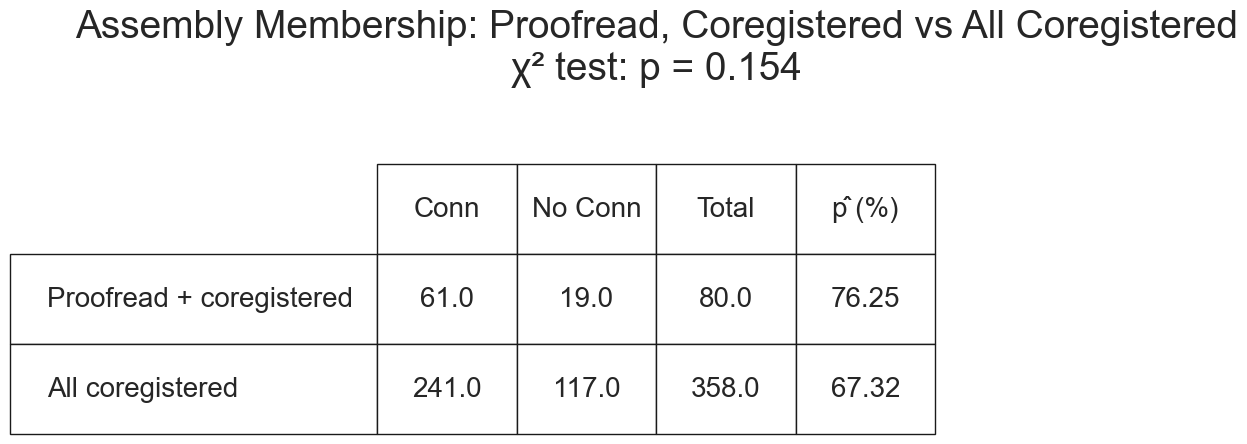

In [26]:
def assembly_sort_key(a):
    if a == 'No A':
        return (1, float('inf'))
    else:
        return (0, int(a.split()[1]))

rows = []

for assembly, roots in assembly_to_root_ids.items():
    roots_set = set(roots)

    pre_count = len(roots_set & pre_root_ids)
    post_count = len(roots_set & post_root_ids)
    total_count = len(roots_set & (post_root_ids | pre_root_ids))

    rows.append({
        'Assembly': assembly,
        'Pre': pre_count,
        'Post': post_count,
        # 'Total': total_count,
        'Pre / Post': pre_count / post_count if post_count > 0 else np.nan
    })

contingency_df = (
    pd.DataFrame(rows)
    .sort_values(by='Assembly', key=lambda col: col.map(assembly_sort_key))
)

print(contingency_df)

pre_root_ids = set(pre_root_ids)

assembly_pre_cells = set()
noA_pre_cells = set()

for assembly, roots in assembly_to_root_ids.items():
    roots_set = set(roots)
    pre_in_assembly = roots_set & pre_root_ids

    if assembly == "No A":
        noA_pre_cells |= pre_in_assembly
    else:
        assembly_pre_cells |= pre_in_assembly

NA_pr = len(noA_pre_cells)
A_pr = len(assembly_pre_cells)
print()
print("Num assembly pre-cells:", A_pr)
print("Num No A pre-cells:", NA_pr)
print("Total pre-cells:", len(pre_root_ids))
print('Total Assembly Cells Proportion', A_pr / len(pre_root_ids))

# Counts for all coregistered
A_all = len(assembly_root_ids_excluding_no_A)
NA_all = len(no_A)

tab = pd.DataFrame(
    [[A_pr, NA_pr],
     [A_all, NA_all]],
    index=["Proofread + coregistered", "All coregistered"],
    columns=["Assembly", "No assembly"],
)

# Add totals and proportions to match your plotting style
tab["Total"] = tab.sum(axis=1)
tab["p̂ (%)"] = 100 * tab["Assembly"] / tab["Total"]

chi2_stat, p_val, dof, expected = chi2_contingency(
    tab[["Assembly", "No assembly"]].values,
    correction=True,
)

chi2 = {
    "chi2": chi2_stat,
    "p_value": p_val,
    "dof": dof,
    "n": tab["Total"].sum(),
    "yates": True,
}

p_pr = A_pr / (A_pr + NA_pr)
p_all = A_all / (A_all + NA_all)

eff = {
    "p_proofread": p_pr,
    "p_all": p_all,
    "RD": p_pr - p_all,
    "RR": p_pr / p_all if p_all > 0 else np.nan,
}

out = {
    "table": tab,
    "chi2": chi2,
    "effect": eff,
}

title = "Assembly Membership: Proofread, Coregistered vs All Coregistered"

pretty_print(out, title)

tab_plot = tab.copy()
tab_plot = tab_plot.rename(
    columns={
        "Assembly": "Conn",
        "No assembly": "No Conn",
    }
)
tab_plot["p_hat"] = tab_plot["Conn"] / tab_plot["Total"]

# ---- plot ----
plot_and_save_contingency(
    tab_plot,
    title,
    out["chi2"]["p_value"],
    save_name="assembly_status_proofread_v_all",
)

## Synaptic Count Distributions By Connection Type

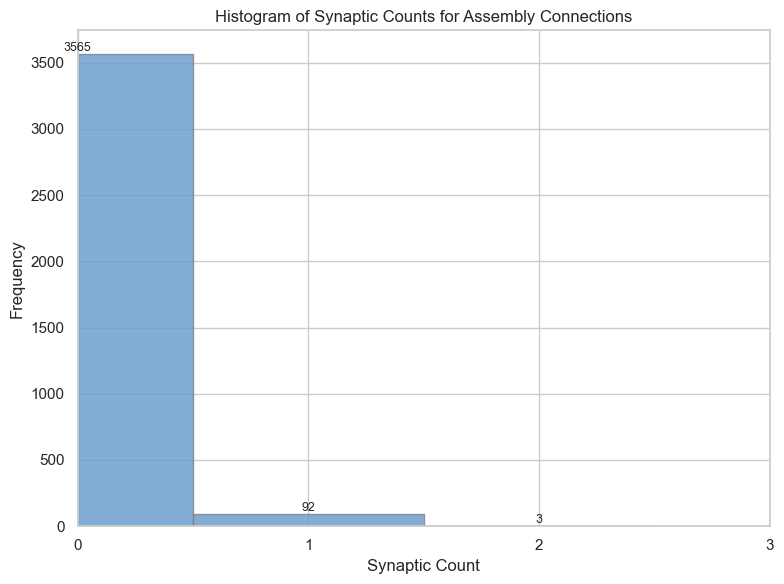

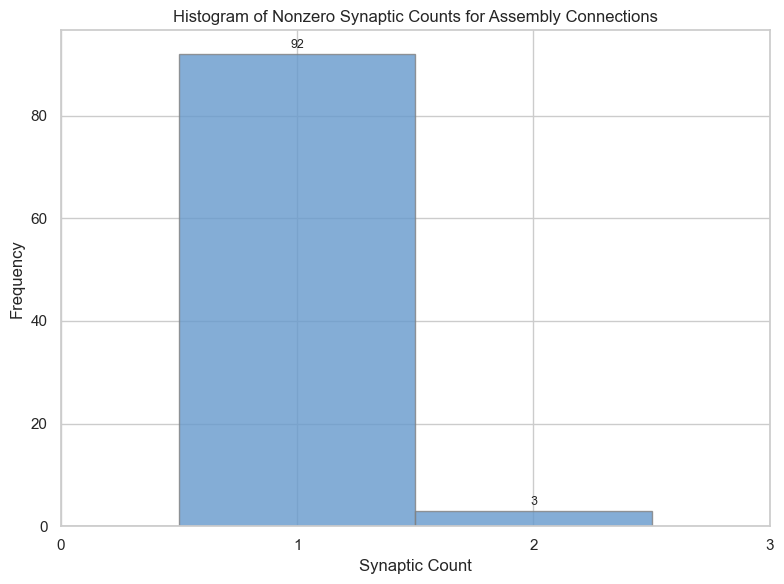

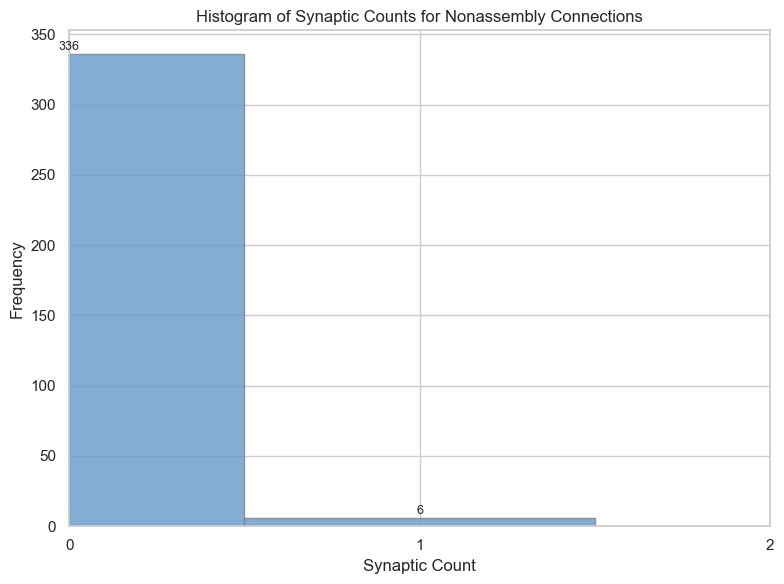

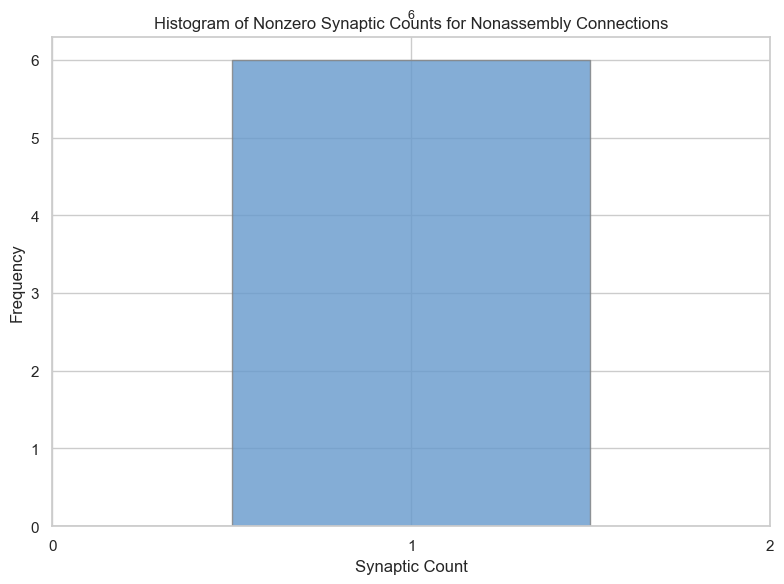

In [27]:
for group in all_connection_types:
    synaptic_count_histogram(
        values_dict=S_pairwise[group],
        connection_type=group,
        save=True,
        figure_name=f'synaptic_count_{group}'
    )
    synaptic_count_histogram(
        values_dict=S_pairwise[group],
        connection_type=group,
        save=True,
        figure_name=f'nonzero_synaptic_count_{group}',
        nonzero=True,
    )

# Primary Results

## Monosynaptic


Monosynaptic Connectivity By Connection Type
Chi-squared test (Yates=False): χ²=0.5903, dof=1, n=4002, p=0.4423

Effect sizes (95% BCa CI):
  Risk difference (pp): 0.841 [-1.101, 2.012]
  Risk ratio: 1.480 [nan, nan]


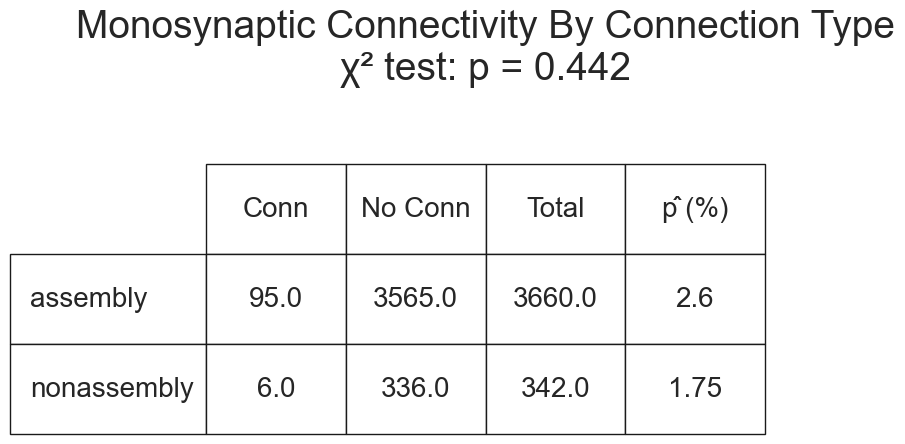

In [28]:
y, group = build_y_group_monosynaptic(B_pairwise)

out = run_pairwise_chi2_BCa(y, group, B=10_000, seed=747)

title = "Monosynaptic Connectivity By Connection Type"
pretty_print(out, title)
plot_and_save_contingency(out["table"], title, out["chi2"]["p_value"], save_name="mono_connectivity")

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.704, P-value: 0.7593

[UNPAIRED] Effect sizes (pos = 'greater')  n1=95, n2=6
  Test p-value: 0.7593
  Assembly median = 0.00702429, Nonassembly median = 0.00780971

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00238589 : CI [-0.00868838, 0.00192861]
    PS:       0.414 : CI [0.221, 0.596]   (δ=-0.172 : CI [-0.558, 0.193])
    Cohen's d: -0.295 : CI [-1.314, 0.431]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00238589 : CI [-0.0147345, 0.00112837]
    PS:       0.414 : CI [0.202, 0.582]   (δ=-0.172 : CI [-0.596, 0.165])
    Cohen's d: -0.295 : CI [-1.666, 0.340]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=95) vs. NonAssembly
(n=6): Custom statistical test, P_val:7.593e-01


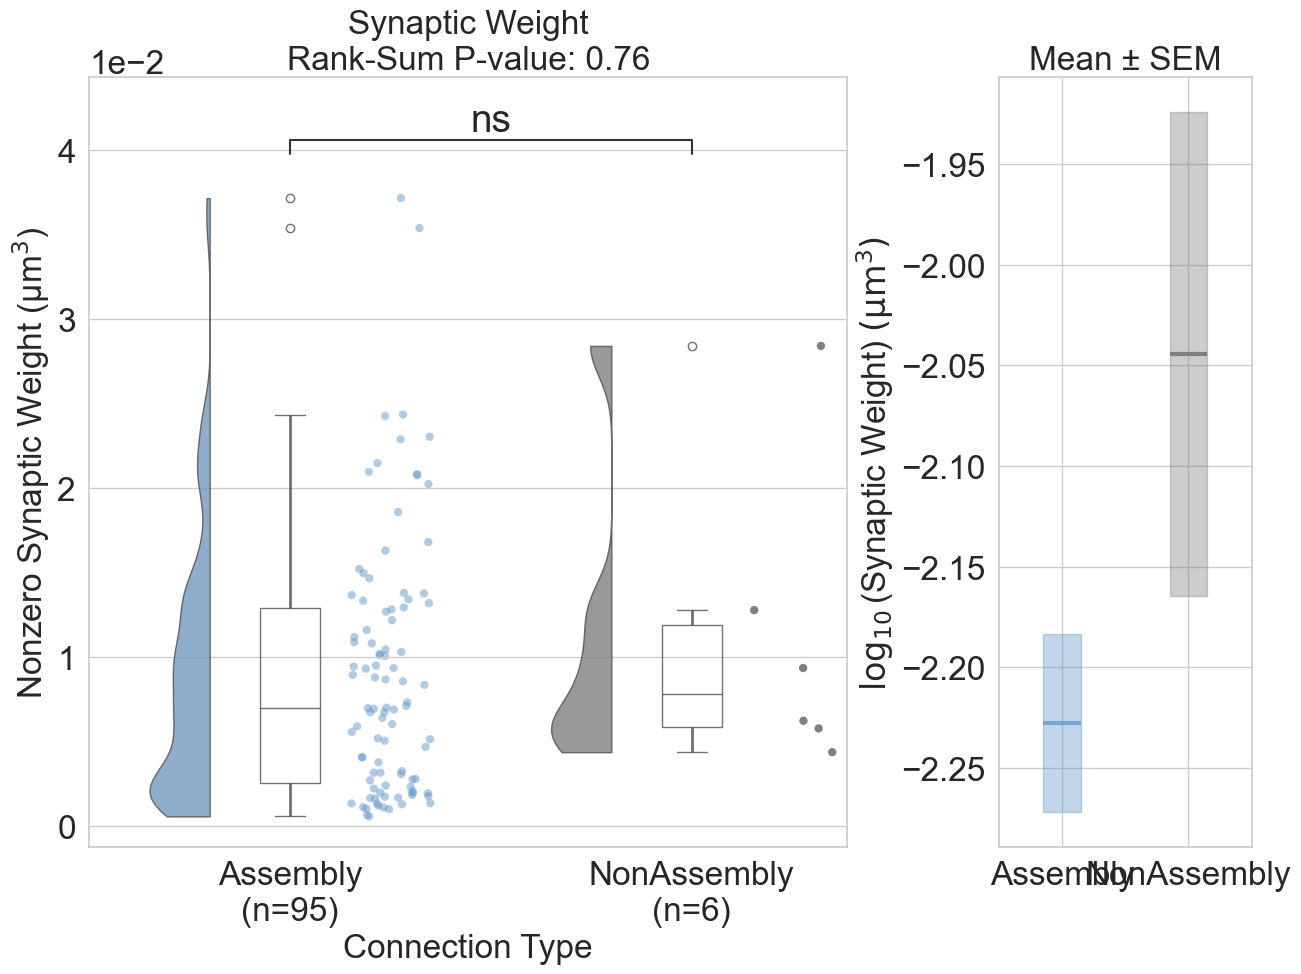

{'p_value': 0.7592717669599593,
 'alternative': 'greater',
 'statistic': -0.7039619560036722,
 'n_shared': 95,
 'n_disjoint': 6}

In [29]:
ranksum_signedrank_two_group_comparison(W_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.1293, P-value: 0.4486

[UNPAIRED] Effect sizes (pos = 'greater')  n1=95, n2=6
  Test p-value: 0.4486
  Assembly median = 1, Nonassembly median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.516 : CI [0.500, 0.537]   (δ=0.032 : CI [0.000, 0.074])
    Cohen's d: 0.184 : CI [nan, nan]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.516 : CI [0.500, 0.537]   (δ=0.032 : CI [0.000, 0.074])
    Cohen's d: 0.184 : CI [nan, nan]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=95) vs. NonAssembly
(n=6): Custom statistical test, P_val:4.486e-01


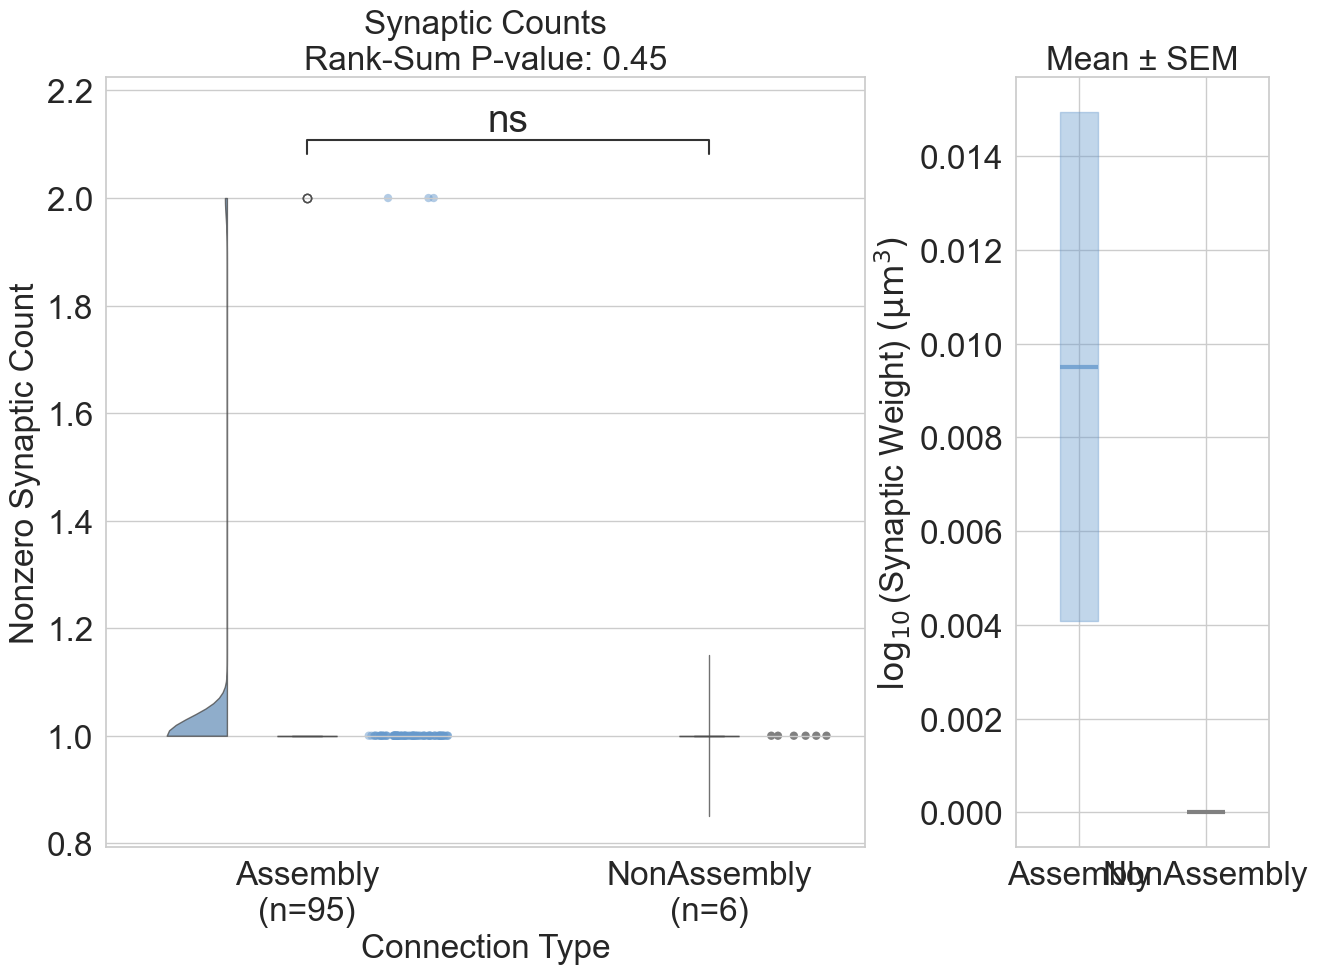

{'p_value': 0.4485604780181976,
 'alternative': 'greater',
 'statistic': 0.12929913477618468,
 'n_shared': 95,
 'n_disjoint': 6}

In [30]:
ranksum_signedrank_two_group_comparison(S_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 2.719, P-value: 0.003273

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.003273
  Assembly median = 0.0166667, Nonassembly median = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.0166667 : CI [0, 0.0166667]
    PS:       0.708 : CI [0.537, 0.857]   (δ=0.415 : CI [0.073, 0.714])
    Cohen's d: 0.318 : CI [-0.332, 1.139]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.0166667 : CI [-0.0277778, 0.0166667]
    PS:       0.708 : CI [0.513, 0.841]   (δ=0.415 : CI [0.027, 0.682])
    Cohen's d: 0.318 : CI [-0.485, 1.008]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:3.273e-03


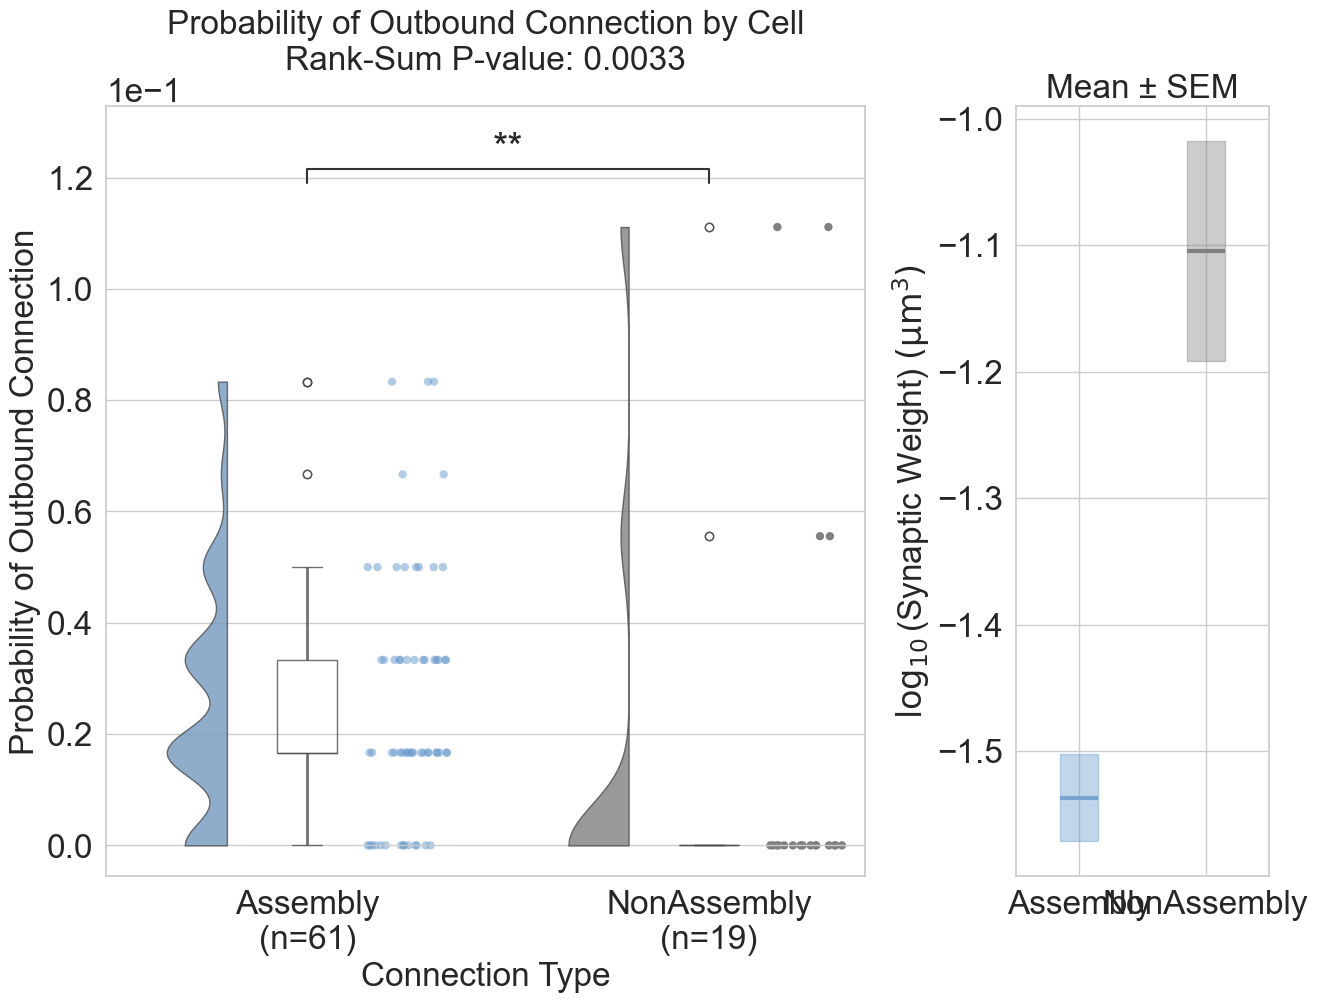

{'p_value': 0.003273220194082175,
 'alternative': 'greater',
 'statistic': 2.7190768122459894,
 'n_shared': 61,
 'n_disjoint': 19}

In [31]:
ranksum_signedrank_two_group_comparison(B_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Outbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.7357, P-value: 0.7691

[UNPAIRED] Effect sizes (pos = 'greater')  n1=47, n2=4
  Test p-value: 0.7691
  Assembly median = 0.00853796, Nonassembly median = 0.0101892

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00257219 : CI [-0.00808492, 0.00321259]
    PS:       0.388 : CI [0.085, 0.691]   (δ=-0.223 : CI [-0.830, 0.383])
    Cohen's d: -0.428 : CI [-1.585, 0.555]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00257219 : CI [-0.0081943, 0.002014]
    PS:       0.388 : CI [0.085, 0.691]   (δ=-0.223 : CI [-0.830, 0.383])
    Cohen's d: -0.428 : CI [-1.580, 0.556]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=47) vs. NonAssembly
(n=4): Custom statistical test, P_val:7.691e-0

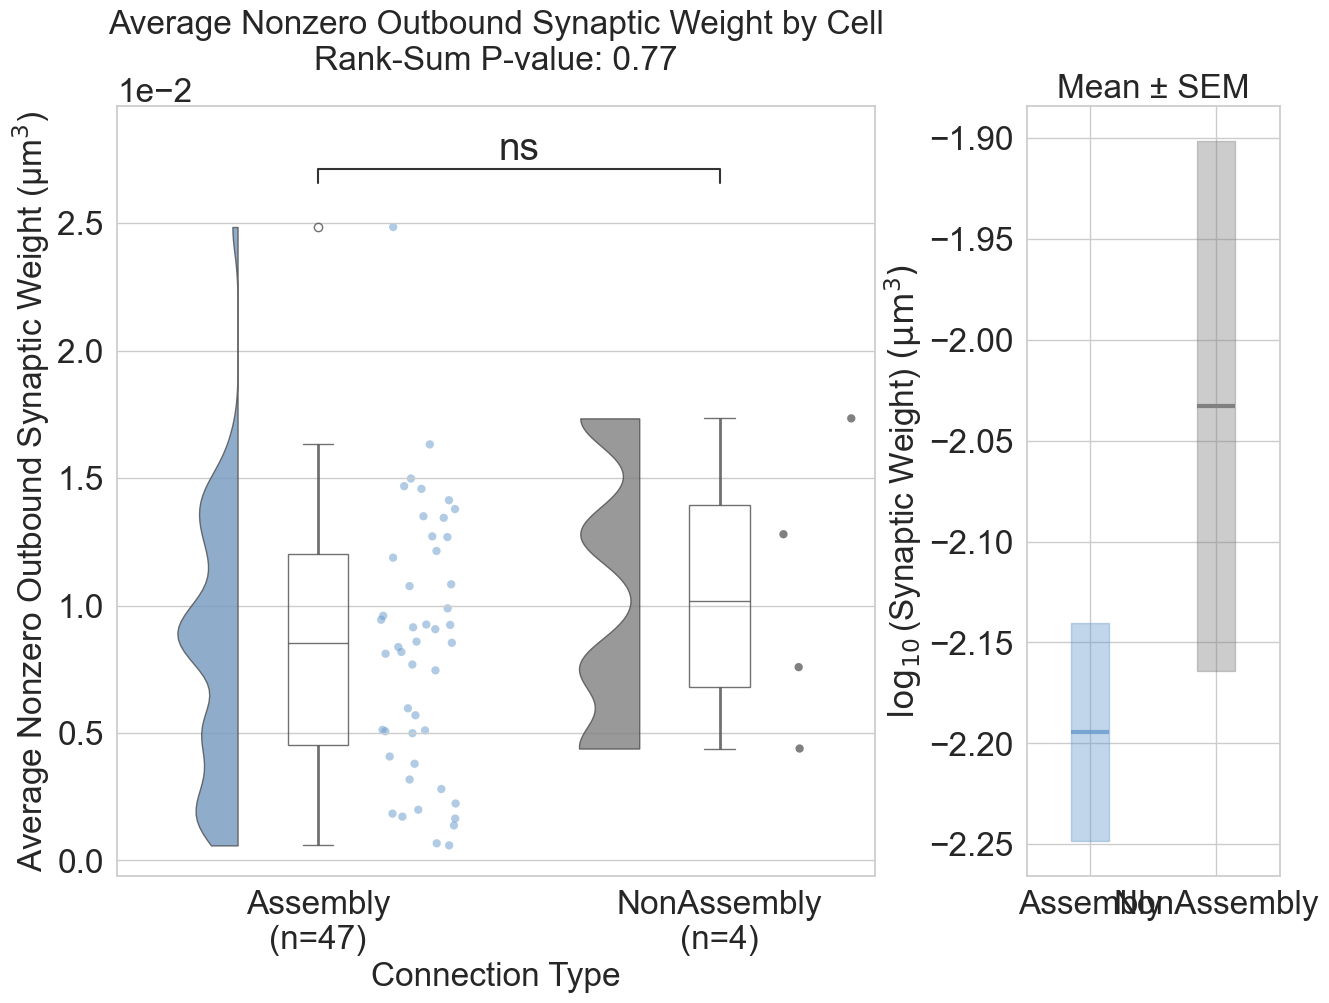

{'p_value': 0.7690580830167072,
 'alternative': 'greater',
 'statistic': -0.7357483914906064,
 'n_shared': 47,
 'n_disjoint': 4}

In [32]:
ranksum_signedrank_two_group_comparison(W_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name = 'Avg_Nonzero_Outbound_PSD'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.2102, P-value: 0.4168

[UNPAIRED] Effect sizes (pos = 'greater')  n1=47, n2=4
  Test p-value: 0.4168
  Assembly median = 1, Nonassembly median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.532 : CI [0.500, 0.574]   (δ=0.064 : CI [0.000, 0.149])
    Cohen's d: 0.240 : CI [nan, nan]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.532 : CI [0.500, 0.564]   (δ=0.064 : CI [0.000, 0.128])
    Cohen's d: 0.240 : CI [nan, nan]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=47) vs. NonAssembly
(n=4): Custom statistical test, P_val:4.168e-01


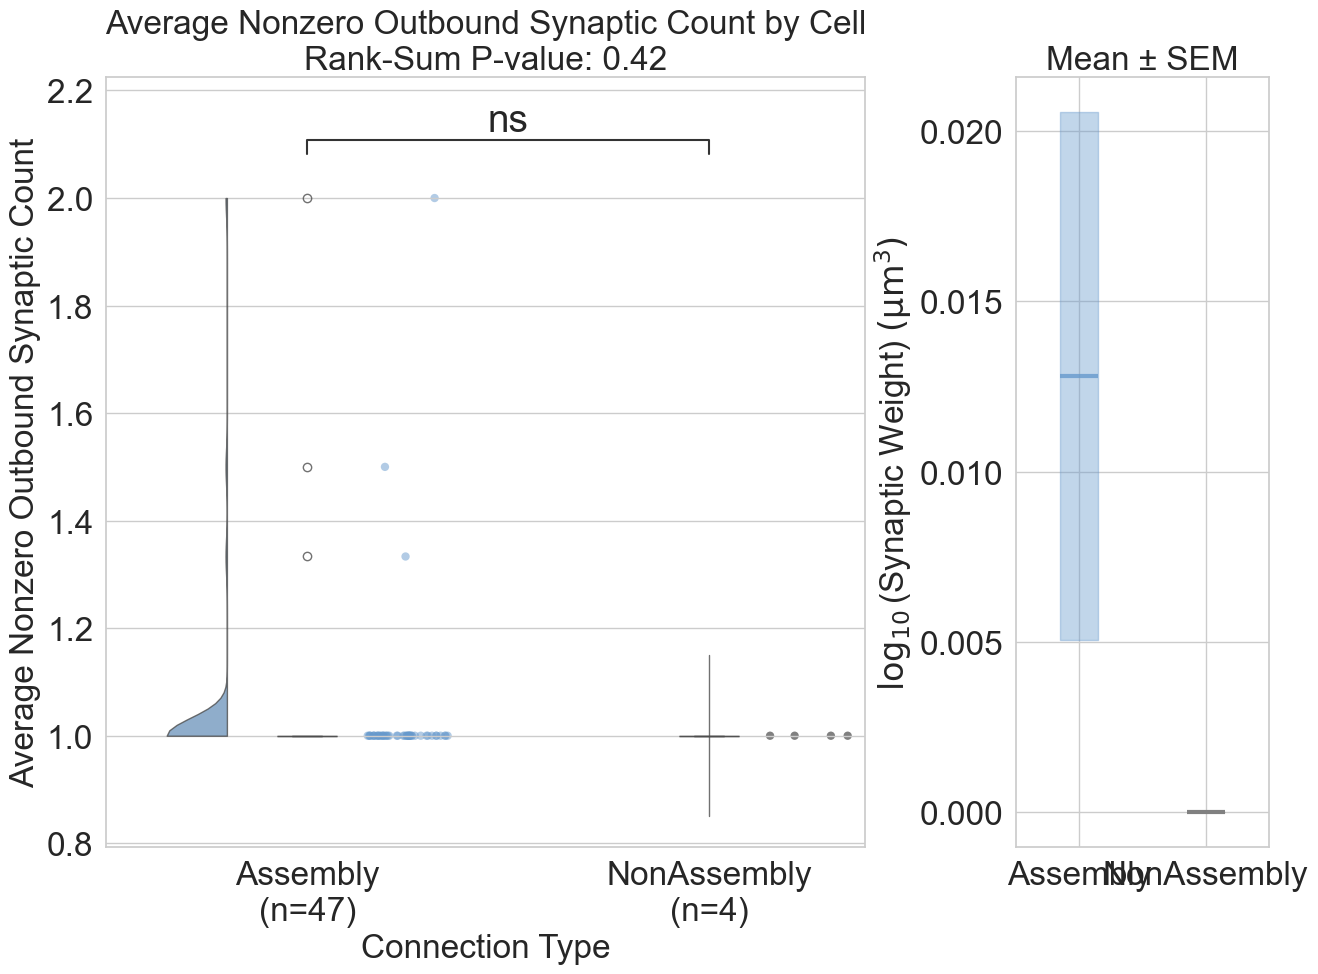

{'p_value': 0.4167503944772122,
 'alternative': 'greater',
 'statistic': 0.21021382614017328,
 'n_shared': 47,
 'n_disjoint': 4}

In [33]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 2.691, P-value: 0.003564

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.003564
  Assembly median = 0.0166667, Nonassembly median = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.0166667 : CI [0, 0.0333333]
    PS:       0.705 : CI [0.538, 0.852]   (δ=0.411 : CI [0.075, 0.703])
    Cohen's d: 0.292 : CI [-0.375, 1.136]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.0166667 : CI [-0.0222222, 0.0166667]
    PS:       0.705 : CI [0.507, 0.836]   (δ=0.411 : CI [0.015, 0.672])
    Cohen's d: 0.292 : CI [-0.678, 0.946]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:3.564e-03


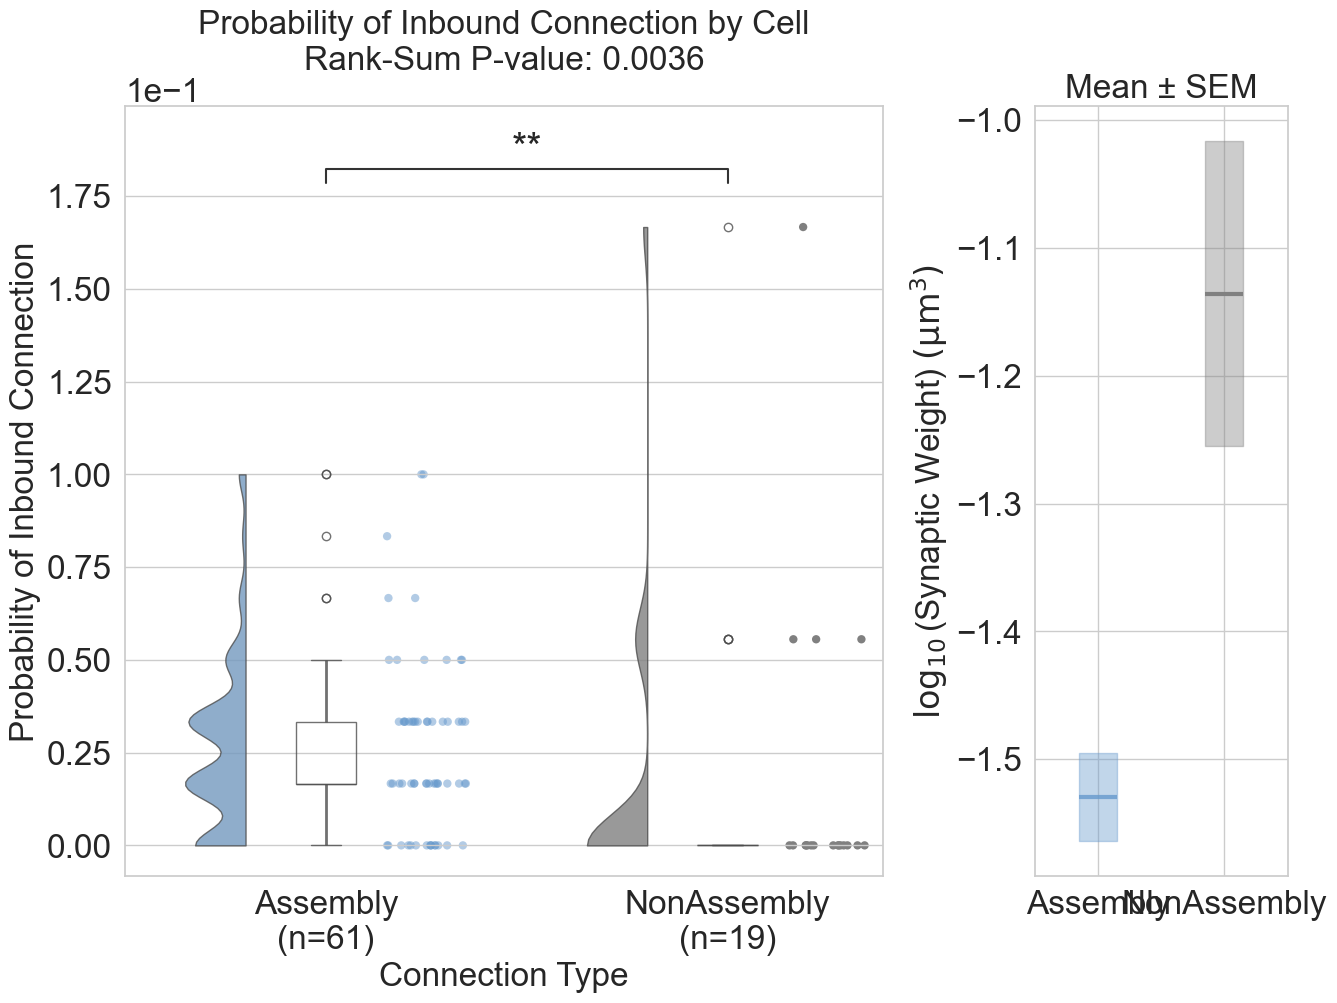

{'p_value': 0.0035639177032116736,
 'alternative': 'greater',
 'statistic': 2.6908119805178607,
 'n_shared': 61,
 'n_disjoint': 19}

In [34]:
ranksum_signedrank_two_group_comparison(B_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Inbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.2861, P-value: 0.6126

[UNPAIRED] Effect sizes (pos = 'greater')  n1=46, n2=4
  Test p-value: 0.6126
  Assembly median = 0.0091085, Nonassembly median = 0.00882517

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000630873 : CI [-0.0172347, 0.00358695]
    PS:       0.457 : CI [0.152, 0.728]   (δ=-0.087 : CI [-0.696, 0.457])
    Cohen's d: -0.423 : CI [-2.097, 0.660]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000630873 : CI [-0.0172347, 0.00358695]
    PS:       0.457 : CI [0.125, 0.707]   (δ=-0.087 : CI [-0.750, 0.413])
    Cohen's d: -0.423 : CI [-2.599, 0.584]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=46) vs. NonAssembly
(n=4): Custom statistical test, P_val:6.126

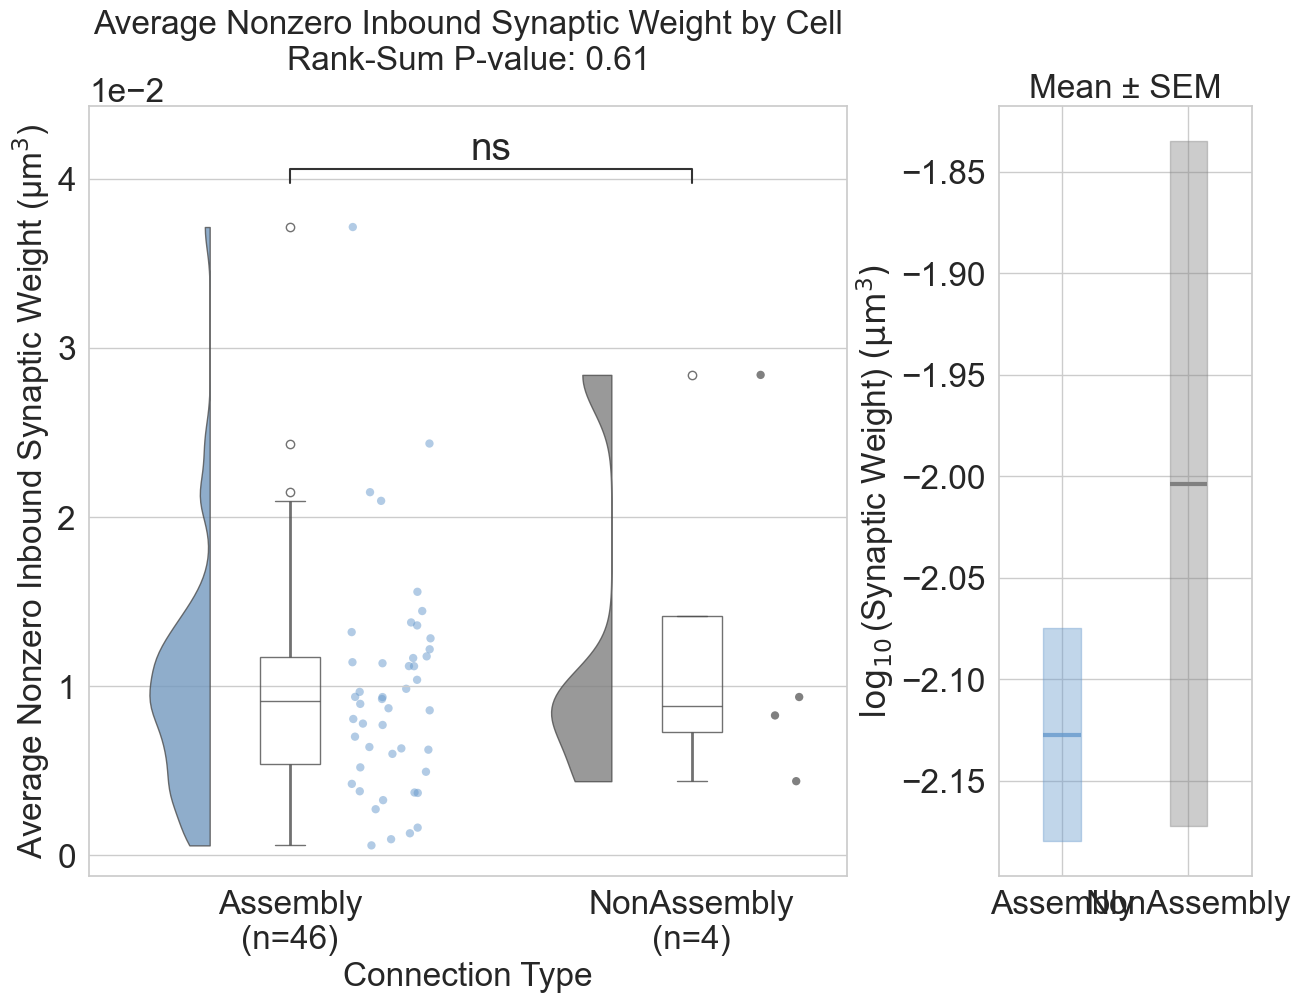

{'p_value': 0.612591351647327,
 'alternative': 'greater',
 'statistic': -0.2860794159408606,
 'n_shared': 46,
 'n_disjoint': 4}

In [35]:
ranksum_signedrank_two_group_comparison(W_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.2146, P-value: 0.4151

[UNPAIRED] Effect sizes (pos = 'greater')  n1=46, n2=4
  Test p-value: 0.4151
  Assembly median = 1, Nonassembly median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.533 : CI [0.500, 0.576]   (δ=0.065 : CI [0.000, 0.152])
    Cohen's d: 0.212 : CI [nan, nan]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.533 : CI [0.500, 0.565]   (δ=0.065 : CI [0.000, 0.130])
    Cohen's d: 0.212 : CI [nan, nan]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=46) vs. NonAssembly
(n=4): Custom statistical test, P_val:4.151e-01


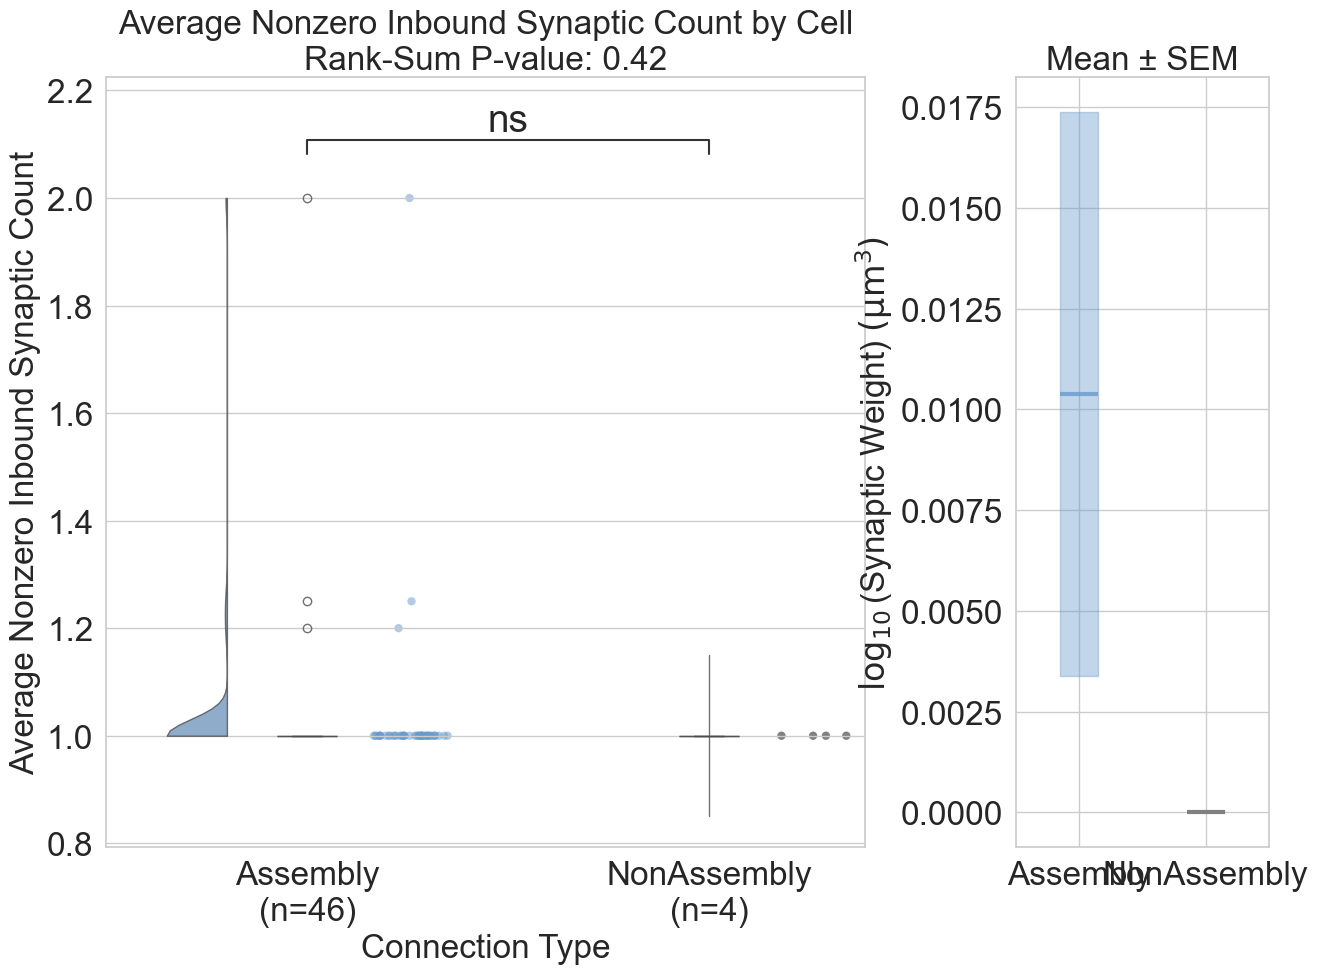

{'p_value': 0.41505536225042033,
 'alternative': 'greater',
 'statistic': 0.21455956195564546,
 'n_shared': 46,
 'n_disjoint': 4}

In [36]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

## Centrality

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.86, P-value: 0.03146

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.03146
  Shared median = 0.0481786, Disjoint median = 0.0434783

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00822562 : CI [0, 0.0176263]
    PS:       0.642 : CI [0.497, 0.771]   (δ=0.284 : CI [-0.006, 0.542])
    Cohen's d: 0.544 : CI [0.118, 0.986]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00822562 : CI [-0.00117509, 0.0152761]
    PS:       0.642 : CI [0.494, 0.768]   (δ=0.284 : CI [-0.013, 0.536])
    Cohen's d: 0.544 : CI [0.110, 0.972]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.146e-02


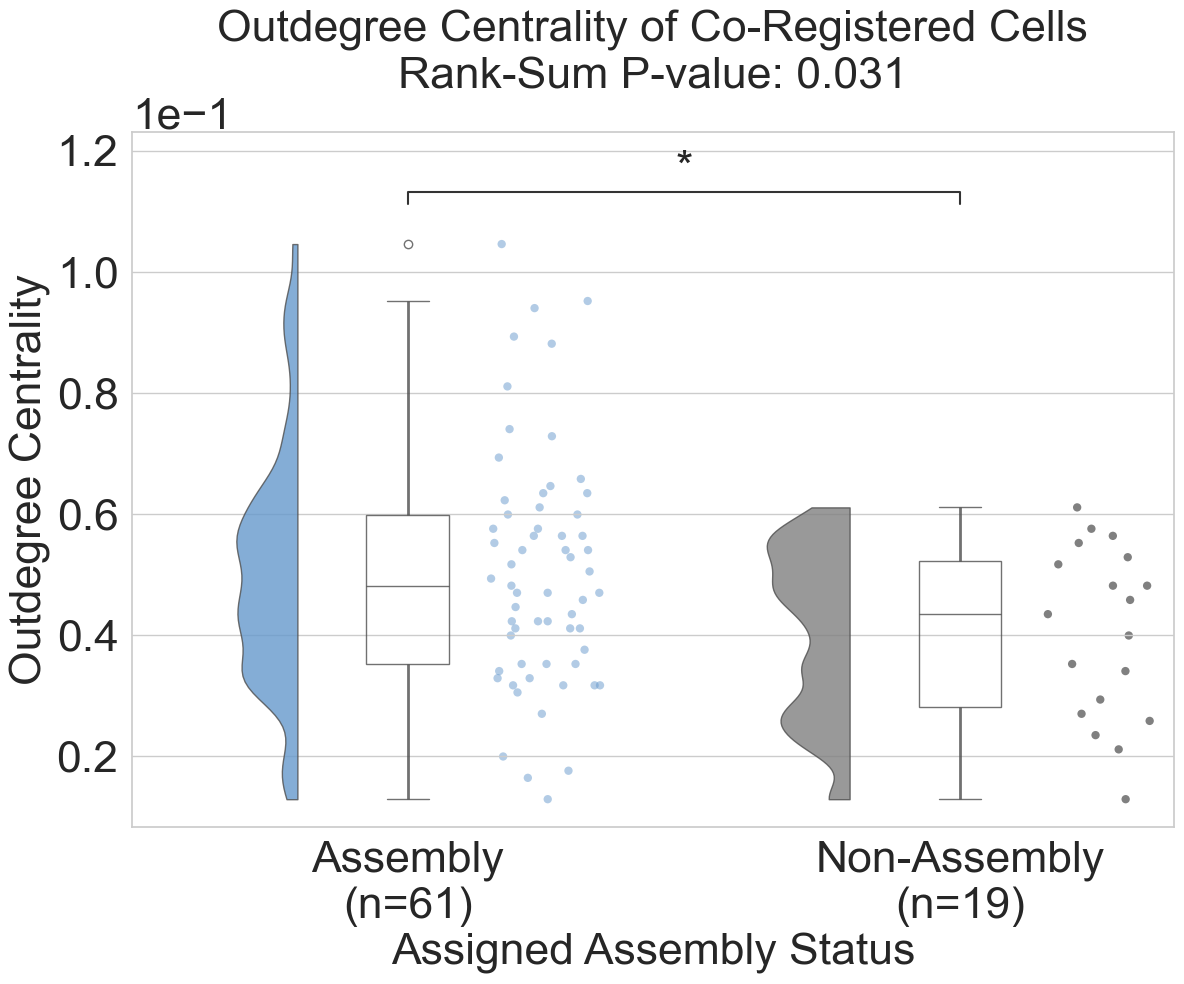

In [37]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True, save=True, figure_name='Outdegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.747, P-value: 0.04034

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.04034
  Shared median = 0.0857814, Disjoint median = 0.0740306

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.0141011 : CI [-0.00117509, 0.0282021]
    PS:       0.633 : CI [0.488, 0.769]   (δ=0.267 : CI [-0.024, 0.538])
    Cohen's d: 0.491 : CI [-0.010, 1.040]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.0141011 : CI [-0.00352526, 0.027027]
    PS:       0.633 : CI [0.459, 0.753]   (δ=0.267 : CI [-0.082, 0.506])
    Cohen's d: 0.491 : CI [-0.088, 0.963]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:4.034e-02


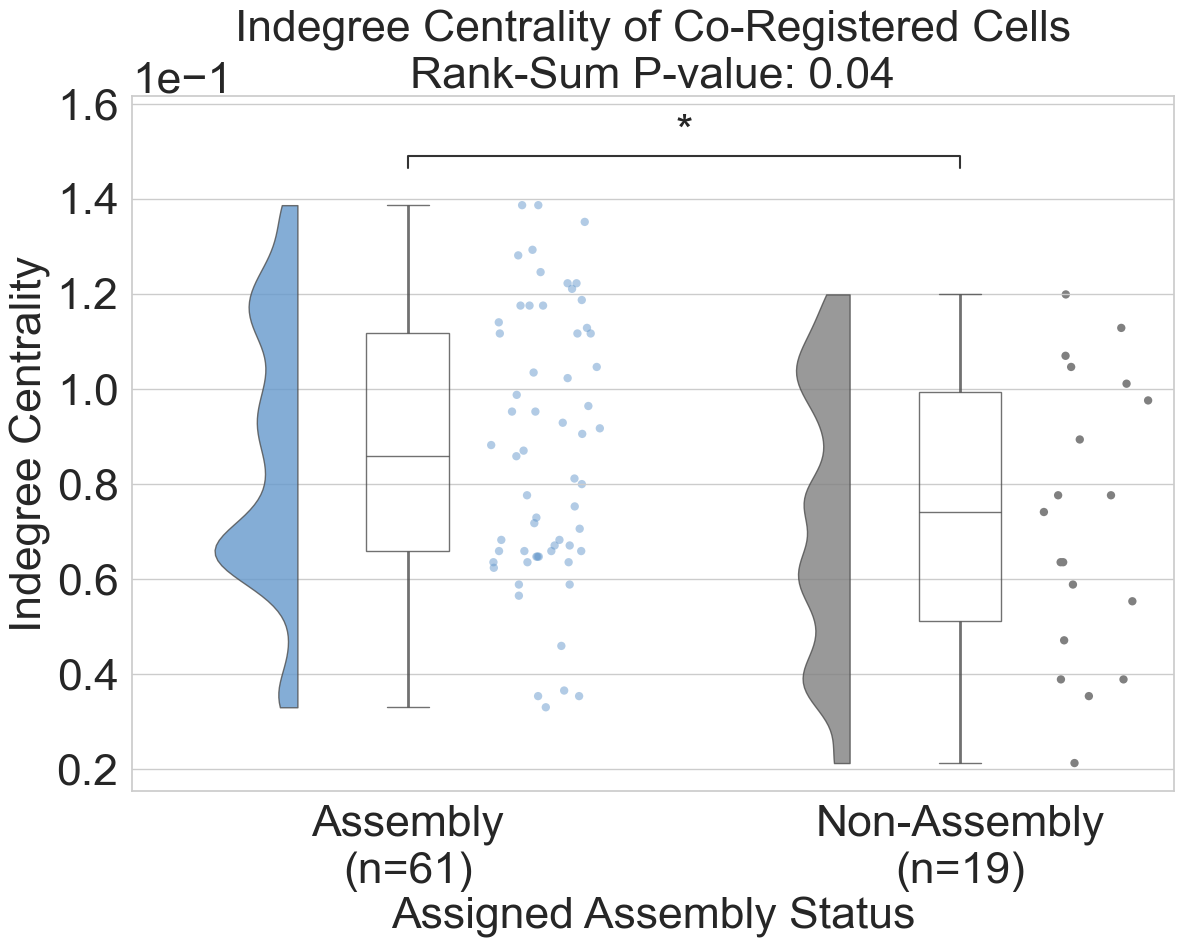

In [38]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True, save=True, figure_name='Indegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 2.719, P-value: 0.003273

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.003273
  Shared median = 0.000274487, Disjoint median = 0.000159944

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168546]
    PS:       0.708 : CI [0.563, 0.838]   (δ=0.415 : CI [0.125, 0.676])
    Cohen's d: 0.635 : CI [0.221, 1.023]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168535]
    PS:       0.708 : CI [0.544, 0.821]   (δ=0.415 : CI [0.087, 0.641])
    Cohen's d: 0.635 : CI [0.087, 0.955]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.273e-03


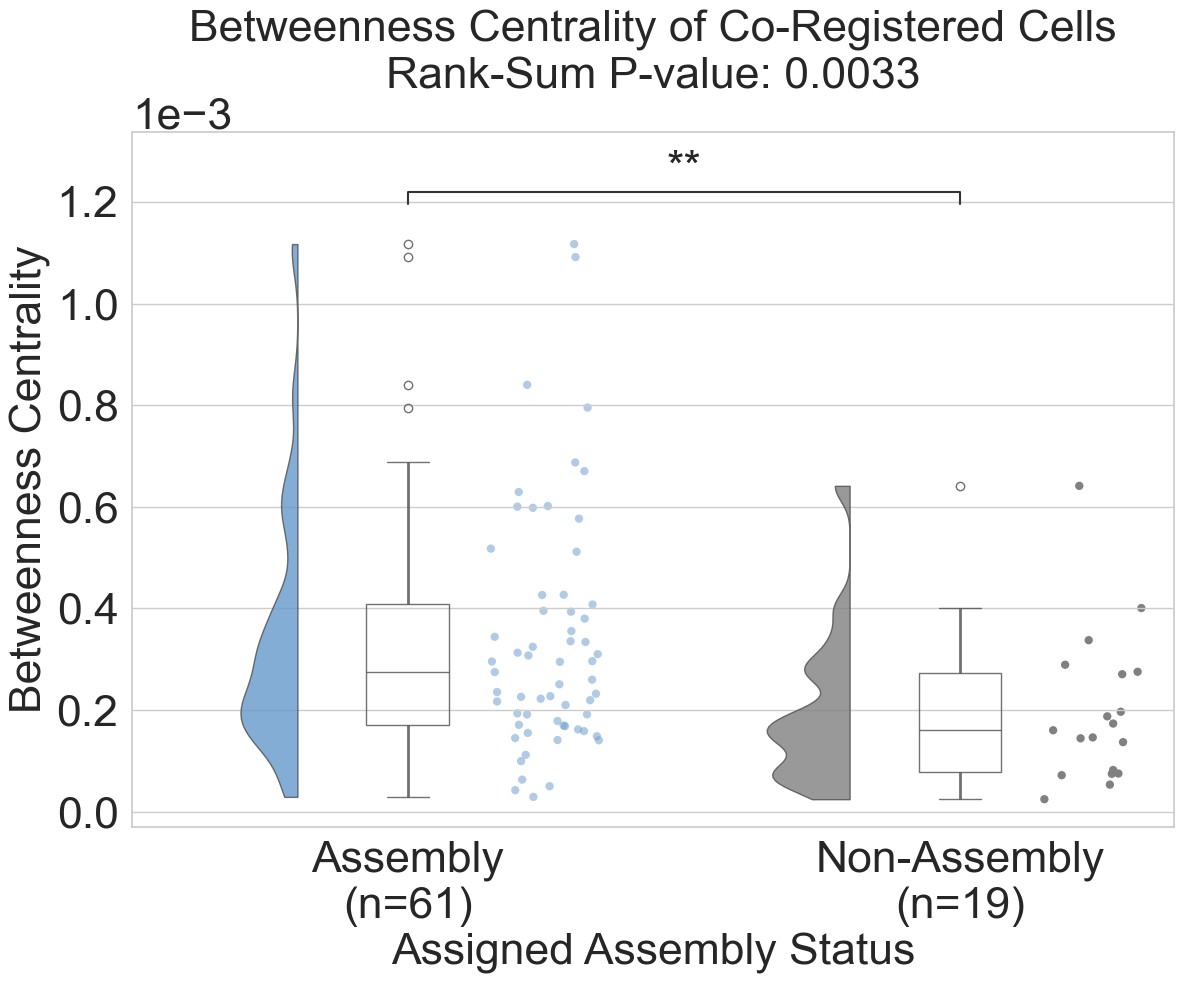

In [39]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.413, P-value: 0.07879

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.07879
  Shared median = 0.491889, Disjoint median = 0.48459

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00577382 : CI [-0.00209518, 0.0154273]
    PS:       0.608 : CI [0.462, 0.745]   (δ=0.216 : CI [-0.075, 0.490])
    Cohen's d: 0.391 : CI [-0.119, 0.945]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00577382 : CI [-0.00233917, 0.0142508]
    PS:       0.608 : CI [0.459, 0.738]   (δ=0.216 : CI [-0.083, 0.475])
    Cohen's d: 0.391 : CI [-0.119, 0.945]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:7.879e-02


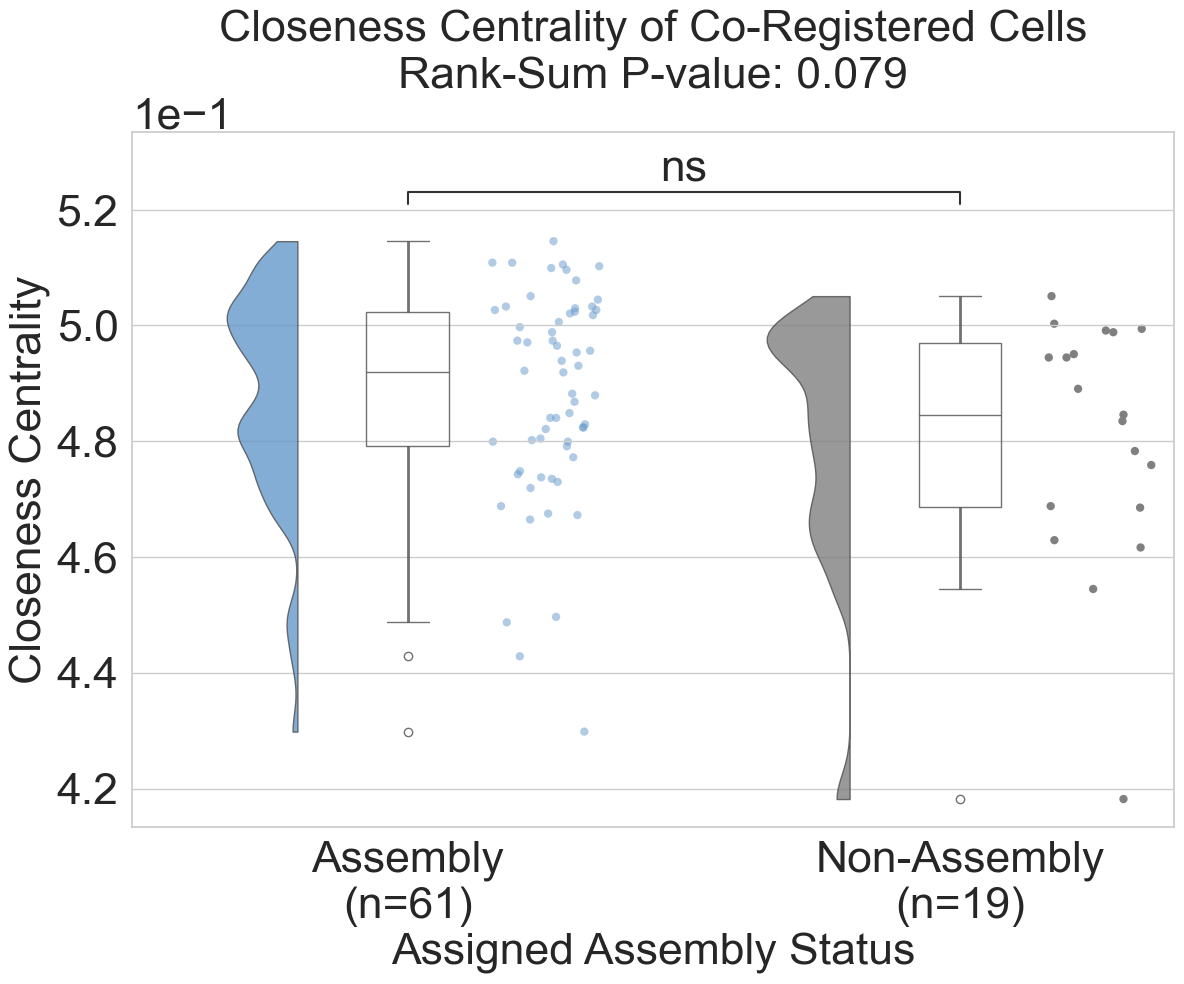

In [40]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_All')

## Disynaptic


Disynaptic Chain Connectivity By Connection Type – excitatory
Chi-squared test (Yates=False): χ²=15.34, dof=1, n=4002, p=8.965e-05

Effect sizes (95% BCa CI):
  Risk difference (pp): 7.900 [4.543, 10.585]
  Risk ratio: 2.126 [1.443, 3.249]


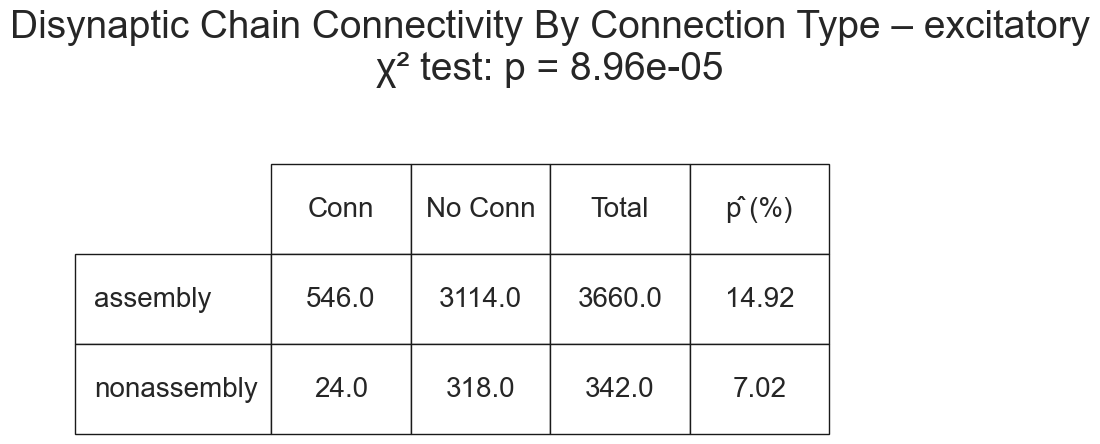


Disynaptic Chain Connectivity By Connection Type – inhibitory
Chi-squared test (Yates=True): χ²=15.42, dof=1, n=4002, p=8.614e-05

Effect sizes (95% BCa CI):
  Risk difference (pp): 1.088 [0.228, 2.789]
  Risk ratio: 1.011 [1.002, 1.029]


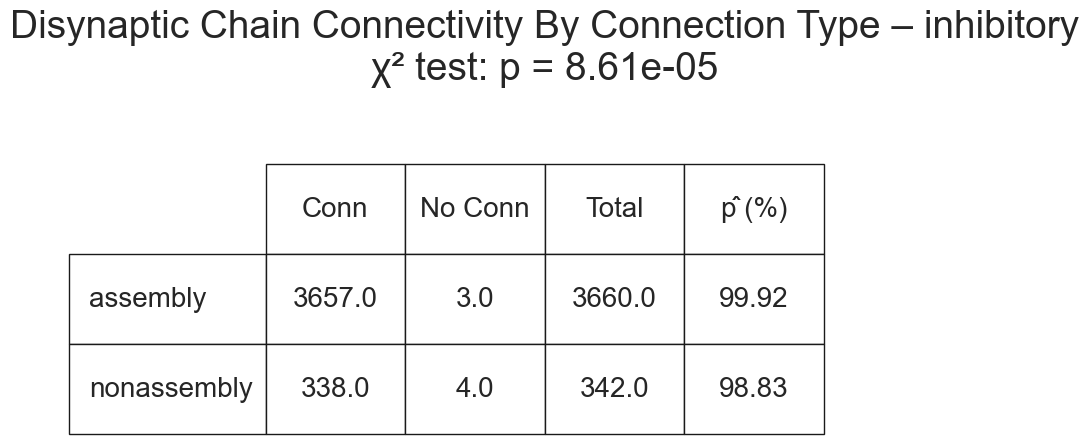

In [41]:
for chain_group in ["excitatory", "inhibitory"]:
    y, group = build_y_group_chains(B_pairwise, R_pairwise_chain, chain_group)

    out = run_pairwise_chi2_BCa(y, group, B=10_000, seed=747)

    title = f"Disynaptic Chain Connectivity By Connection Type – {chain_group}"
    pretty_print(out, title)
    plot_and_save_contingency(out["table"], title, out["chi2"]["p_value"], save_name=f"chains_{chain_group}")

In [42]:
chain_types = ['excitatory', 'inhibitory', 'DistTC', 'InhTC', 'ProxTC', 'SparTC']

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 1.399, P-value: 0.08095

[UNPAIRED] Effect sizes (pos = 'greater')  n1=546, n2=24
  Test p-value: 0.08095
  Assembly median = 5.08136e-05, Nonassembly median = 3.84589e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 1.22323e-05 : CI [-4.84353e-06, 2.70408e-05]
    PS:       0.584 : CI [0.472, 0.690]   (δ=0.169 : CI [-0.056, 0.379])
    Cohen's d: 0.262 : CI [-0.025, 0.499]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 1.22323e-05 : CI [-6.41391e-06, 2.61522e-05]
    PS:       0.584 : CI [0.466, 0.686]   (δ=0.169 : CI [-0.067, 0.371])
    Cohen's d: 0.262 : CI [-0.126, 0.463]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=546) vs. NonAssembly
(n=24): Custom statistical test, P_val:8.095e-02


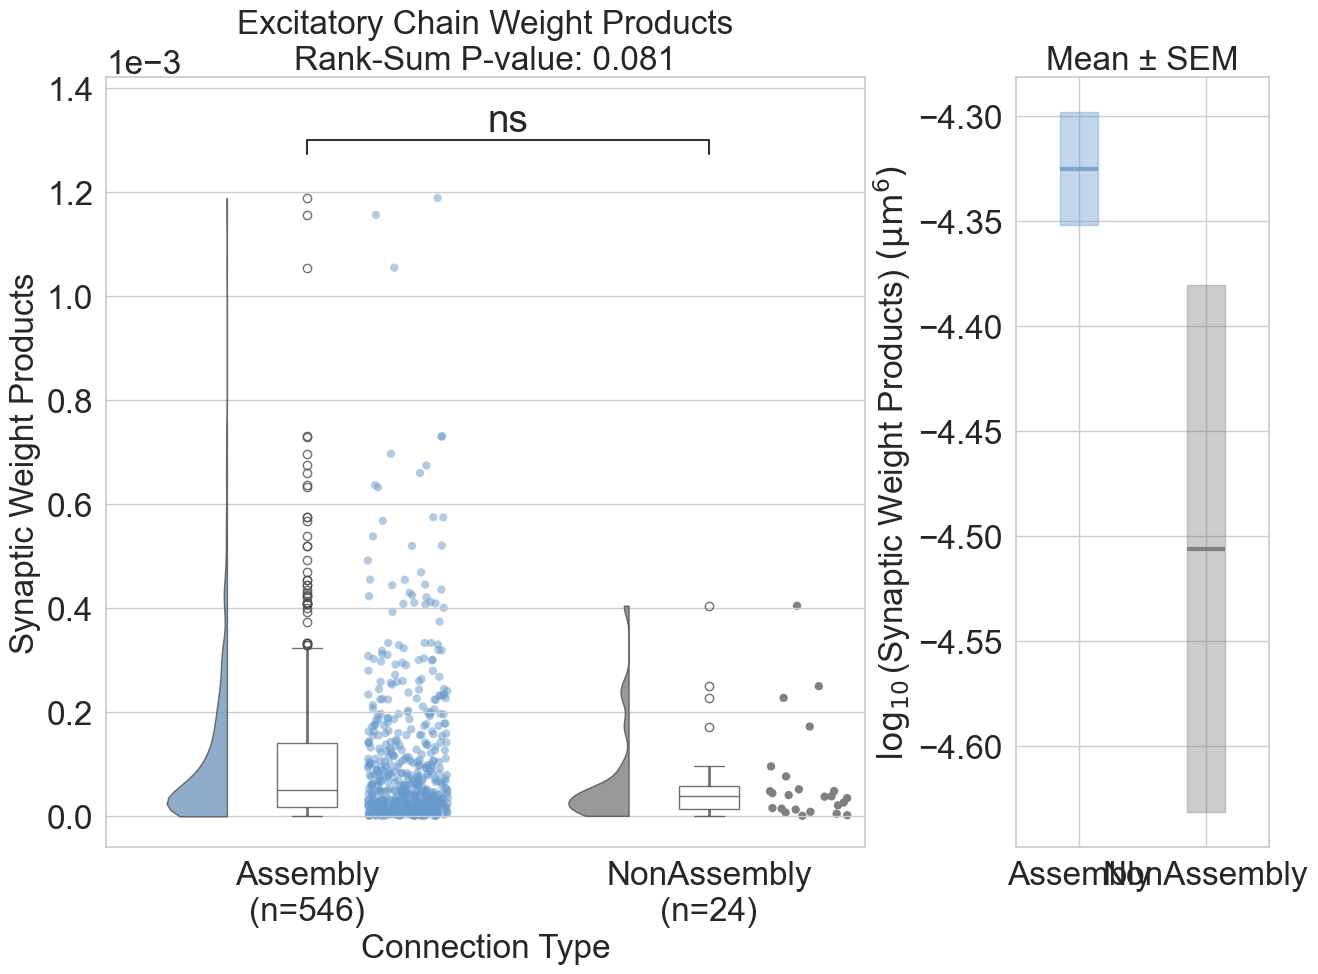

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 8.905, P-value: 1

[UNPAIRED] Effect sizes (pos = 'less')  n1=3657, n2=338
  Test p-value: 1
  Assembly median = 0.00095337, Nonassembly median = 0.000615285

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000314506 : CI [-0.000375061, -0.000252414]
    PS:       0.354 : CI [0.323, 0.384]   (δ=-0.292 : CI [-0.353, -0.231])
    Cohen's d: -0.451 : CI [-0.533, -0.368]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000314506 : CI [-0.000375209, -0.000252605]
    PS:       0.354 : CI [0.324, 0.385]   (δ=-0.292 : CI [-0.353, -0.231])
    Cohen's d: -0.451 : CI [-0.531, -0.365]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=3657) vs. NonAssembly
(n=338): Custom statistical test, P_val:1.000e+00


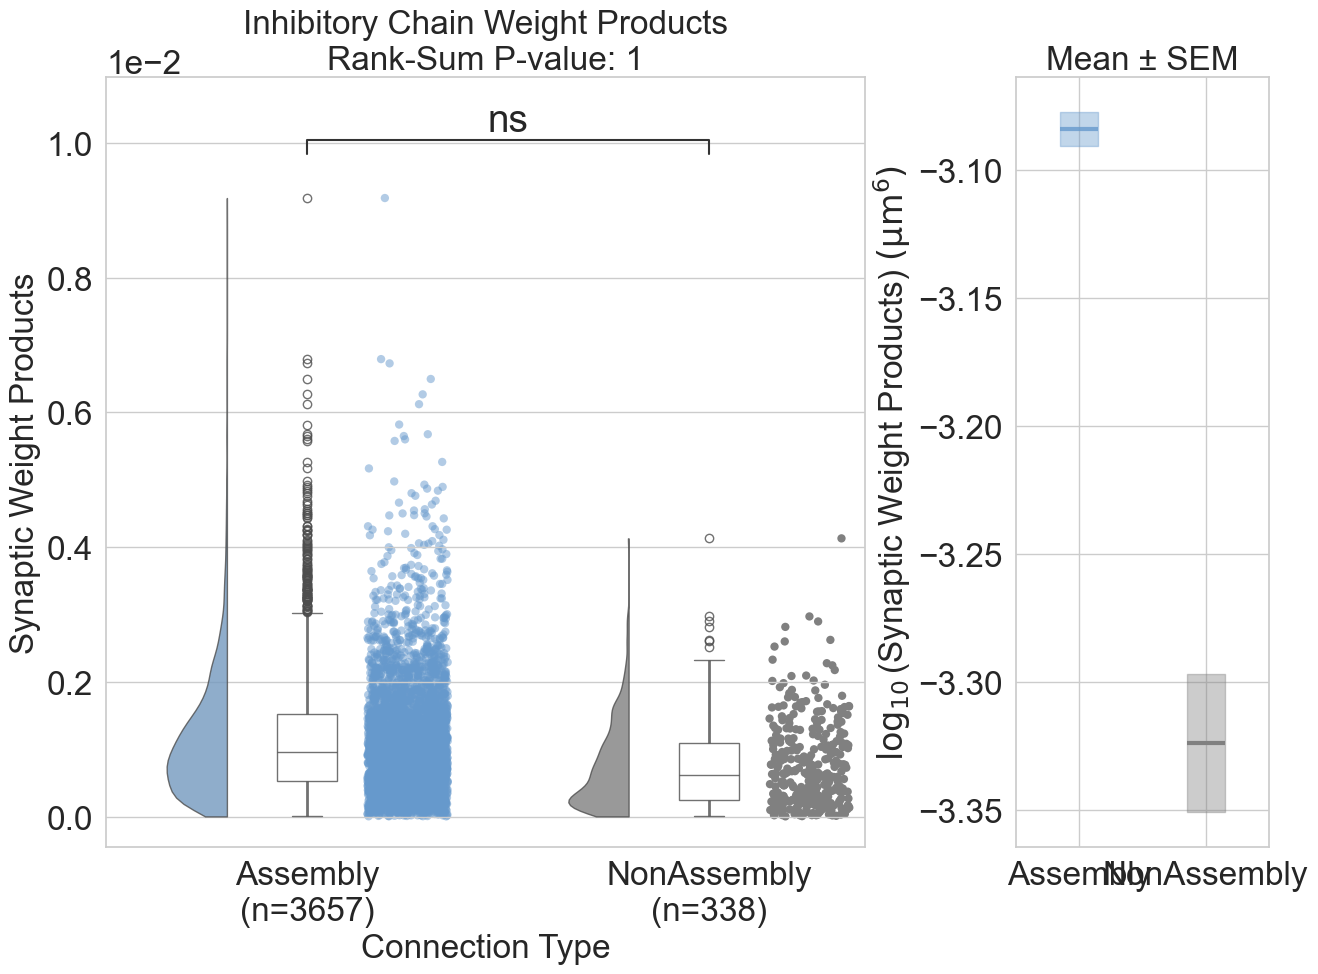

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 10.51, P-value: 1

[UNPAIRED] Effect sizes (pos = 'less')  n1=3654, n2=333
  Test p-value: 1
  Assembly median = 0.000535248, Nonassembly median = 0.00029226

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000206942 : CI [-0.000239896, -0.000173635]
    PS:       0.326 : CI [0.296, 0.357]   (δ=-0.348 : CI [-0.408, -0.286])
    Cohen's d: -0.520 : CI [-0.593, -0.447]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000206942 : CI [-0.000239766, -0.000173565]
    PS:       0.326 : CI [0.297, 0.358]   (δ=-0.348 : CI [-0.406, -0.285])
    Cohen's d: -0.520 : CI [-0.591, -0.445]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=3654) vs. NonAssembly
(n=333): Custom statistical test, P_val:1.000e+00


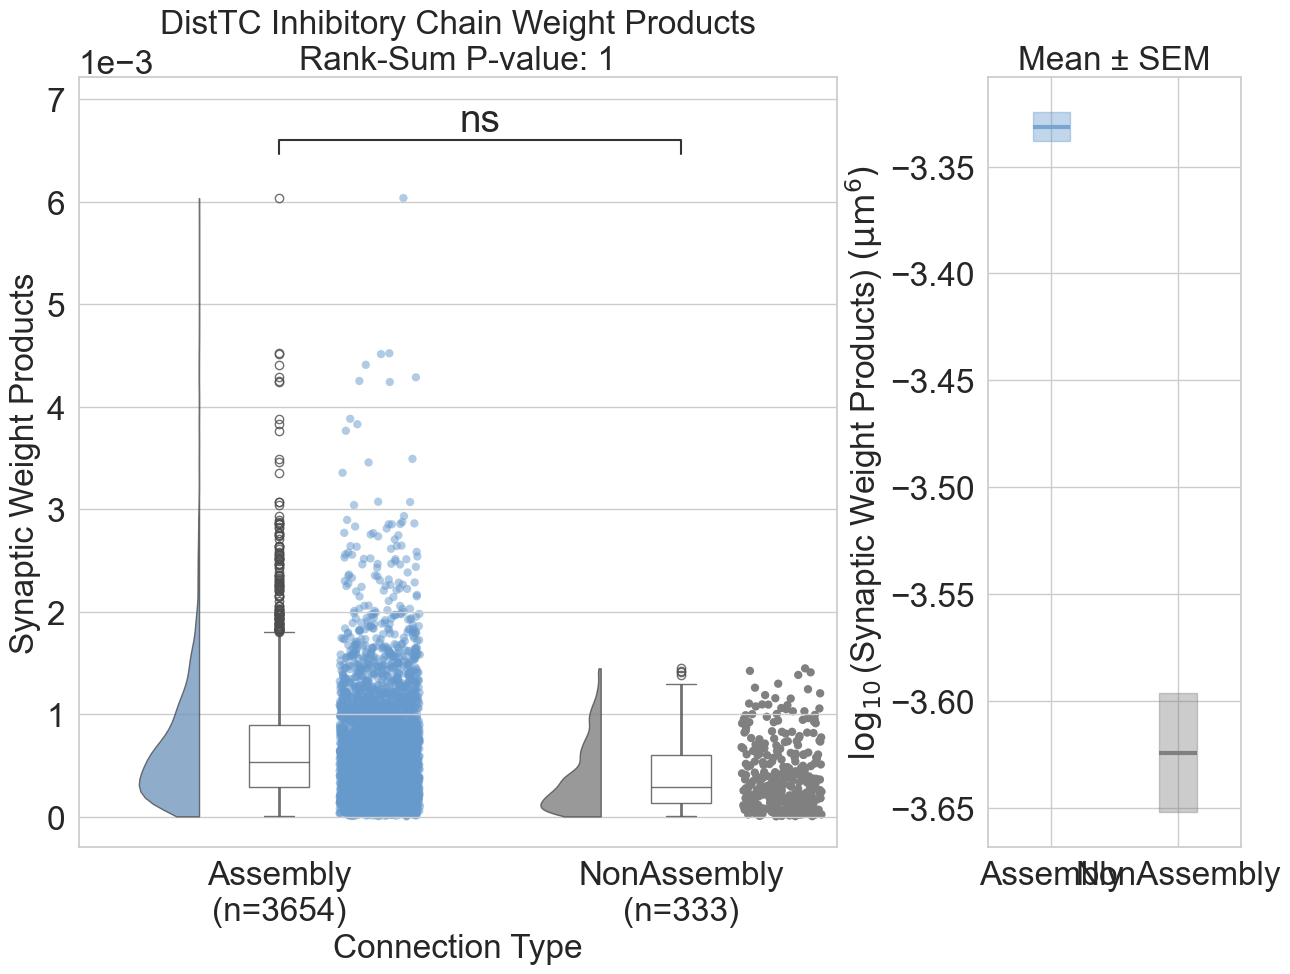

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 2.345, P-value: 0.9905

[UNPAIRED] Effect sizes (pos = 'less')  n1=159, n2=10
  Test p-value: 0.9905
  Assembly median = 1.44814e-05, Nonassembly median = 4.28685e-06

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -6.61798e-06 : CI [-1.20069e-05, 1.68084e-06]
    PS:       0.279 : CI [0.082, 0.527]   (δ=-0.443 : CI [-0.835, 0.054])
    Cohen's d: -0.032 : CI [-0.933, 1.055]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -6.61798e-06 : CI [-1.15116e-05, 3.76799e-06]
    PS:       0.279 : CI [0.104, 0.582]   (δ=-0.443 : CI [-0.791, 0.164])
    Cohen's d: -0.032 : CI [-0.880, 1.467]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=159) vs. NonAssembly
(n=10): Custom statistical test, P_val:9.905e-01


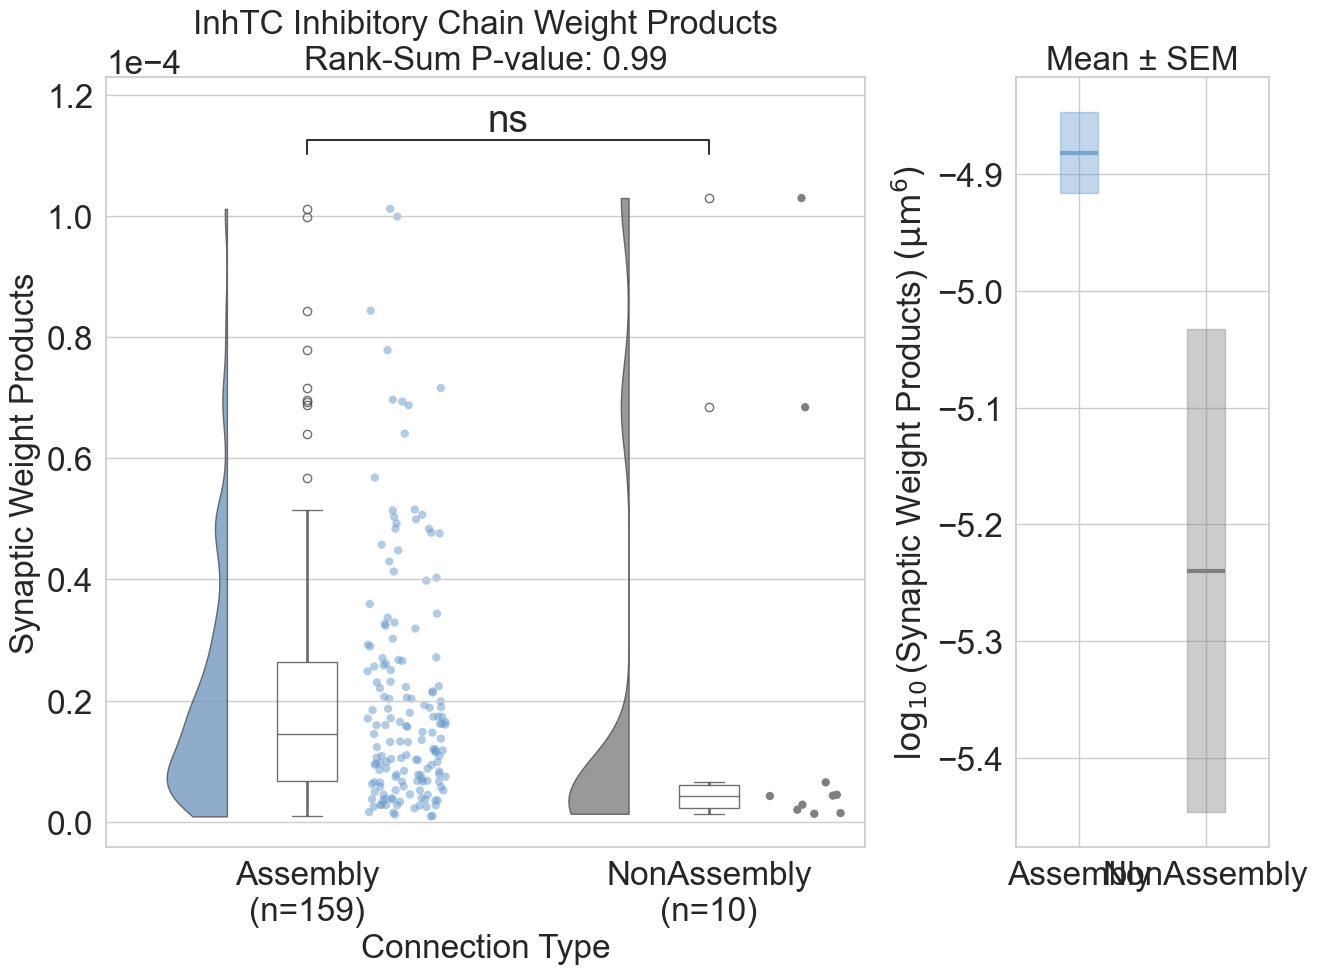

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.307, P-value: 0.9995

[UNPAIRED] Effect sizes (pos = 'less')  n1=3556, n2=310
  Test p-value: 0.9995
  Assembly median = 0.000361051, Nonassembly median = 0.000305885

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -5.51592e-05 : CI [-8.63408e-05, -2.32381e-05]
    PS:       0.443 : CI [0.410, 0.477]   (δ=-0.113 : CI [-0.179, -0.047])
    Cohen's d: -0.188 : CI [-0.288, -0.084]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -5.51592e-05 : CI [-8.61571e-05, -2.31902e-05]
    PS:       0.443 : CI [0.411, 0.477]   (δ=-0.113 : CI [-0.179, -0.046])
    Cohen's d: -0.188 : CI [-0.282, -0.078]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=3556) vs. NonAssembly
(n=310): Custom statistical test, P_val:9.995e-01


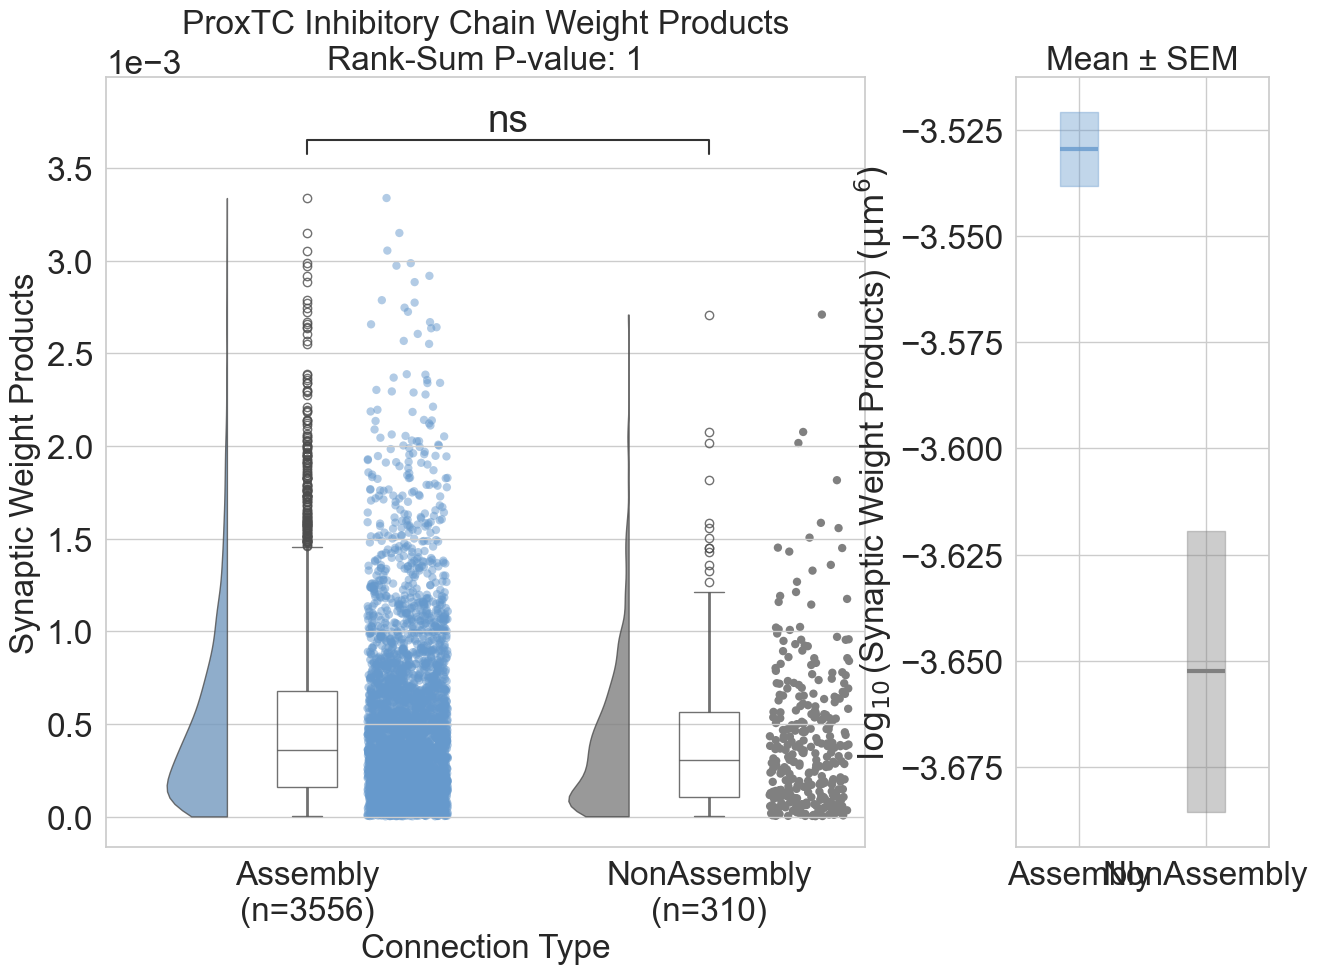

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: nan, P-value: nan


ValueError: Empty group(s) for unpaired analysis after filtering.

In [43]:
stouffers_results = []

for chain_type in chain_types:
    if chain_type == "excitatory":
        chain_description = "Excitatory"
        prefix = ""
    elif chain_type == "inhibitory":
        chain_description = "Inhibitory"
        prefix = ""
    elif chain_type.endswith("P"):
        chain_description = "Excitatory"
        prefix = f"{chain_type} "
    else:
        chain_description = "Inhibitory"
        prefix = f"{chain_type} "

    out = ranksum_signedrank_two_group_comparison(
        W_pairwise_chain[chain_type],
        aggregation_method="connection",
        data_type="summed_psd",
        non_zero=True,
        chain_test=True,
        chain_description=chain_description,
        save=True,
        figure_name=f"Nonzero_PSD_by_Conn_{chain_type}_Chain",
        title_prefix=prefix,
    )

    stouffers_results.append({
        "chain_type": chain_type,
        "p_value": out["p_value"],
        "alternative": out["alternative"],
        "n_shared": out["n_shared"],
        "n_disjoint": out["n_disjoint"],
    })

In [44]:
out_dir = Path("master_outputs\square\stouffers_jsons\a_n")
out_dir.mkdir(exist_ok=True)

out_path = out_dir / "chain_nonzero_psd_scan13.json"

with open(out_path, "w") as f:
    json.dump(stouffers_results, f, indent=2)

print(f"Saved Stouffer inputs to {out_path.resolve()}")

OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'master_outputs\\square\\stouffers_jsons\x07_n'

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.6294, P-value: 0.2645

[UNPAIRED] Effect sizes (pos = 'greater')  n1=546, n2=24
  Test p-value: 0.2645
  Assembly median = 2, Nonassembly median = 2

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.538 : CI [0.462, 0.603]   (δ=0.076 : CI [-0.077, 0.207])
    Cohen's d: 0.295 : CI [0.121, 0.443]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.538 : CI [0.451, 0.596]   (δ=0.076 : CI [-0.099, 0.193])
    Cohen's d: 0.295 : CI [0.095, 0.428]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=546) vs. NonAssembly
(n=24): Custom statistical test, P_val:2.645e-01


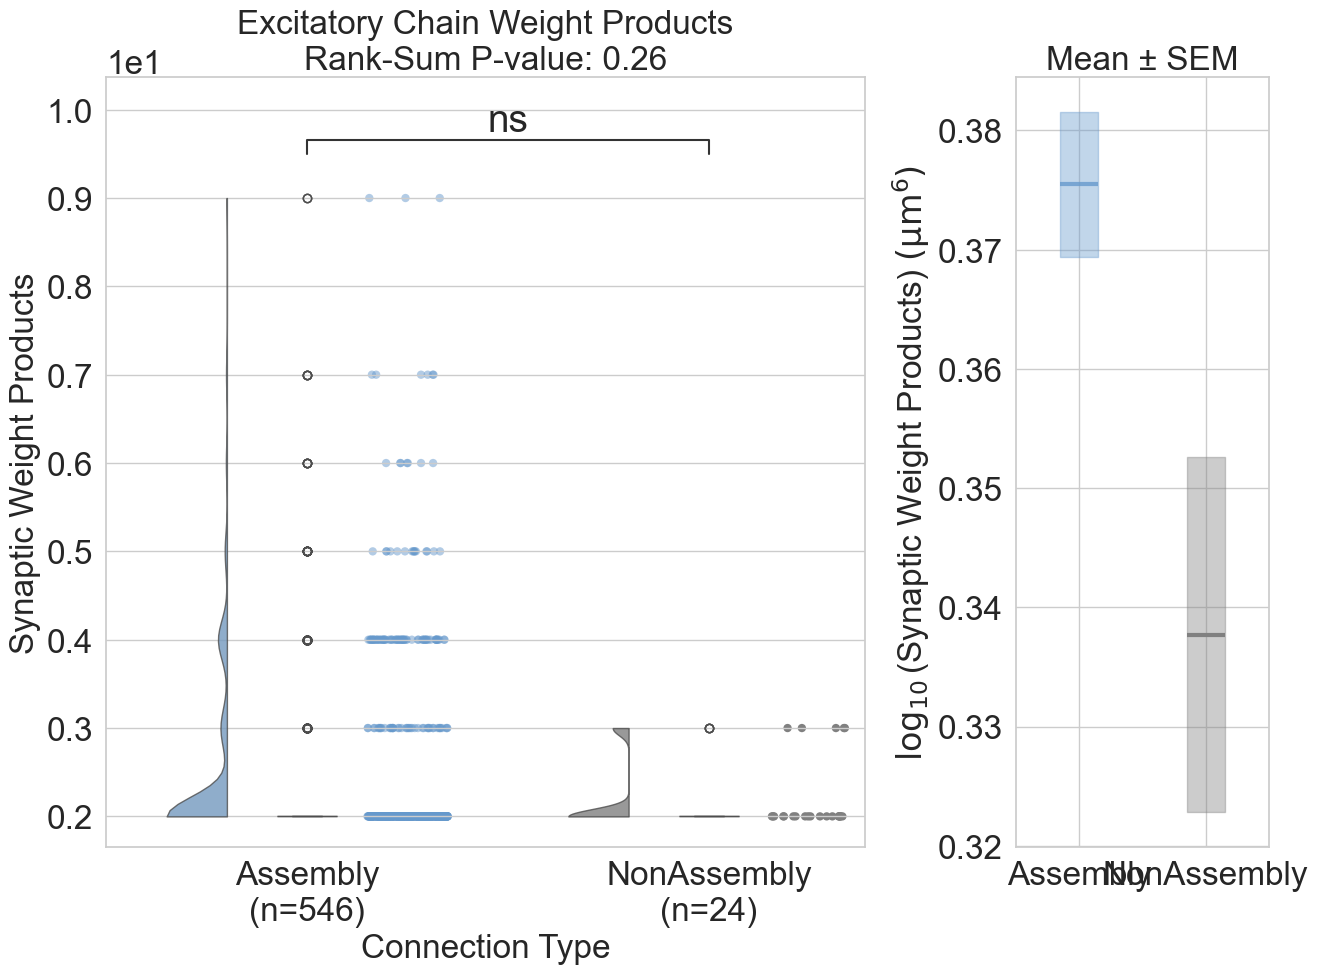

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 9.939, P-value: 1

[UNPAIRED] Effect sizes (pos = 'less')  n1=3657, n2=338
  Test p-value: 1
  Assembly median = 64, Nonassembly median = 41.5

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -20 : CI [-23, -16]
    PS:       0.337 : CI [0.306, 0.367]   (δ=-0.326 : CI [-0.388, -0.266])
    Cohen's d: -0.539 : CI [-0.634, -0.447]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -20 : CI [-25, -18]
    PS:       0.337 : CI [0.306, 0.368]   (δ=-0.326 : CI [-0.388, -0.265])
    Cohen's d: -0.539 : CI [-0.633, -0.446]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=3657) vs. NonAssembly
(n=338): Custom statistical test, P_val:1.000e+00


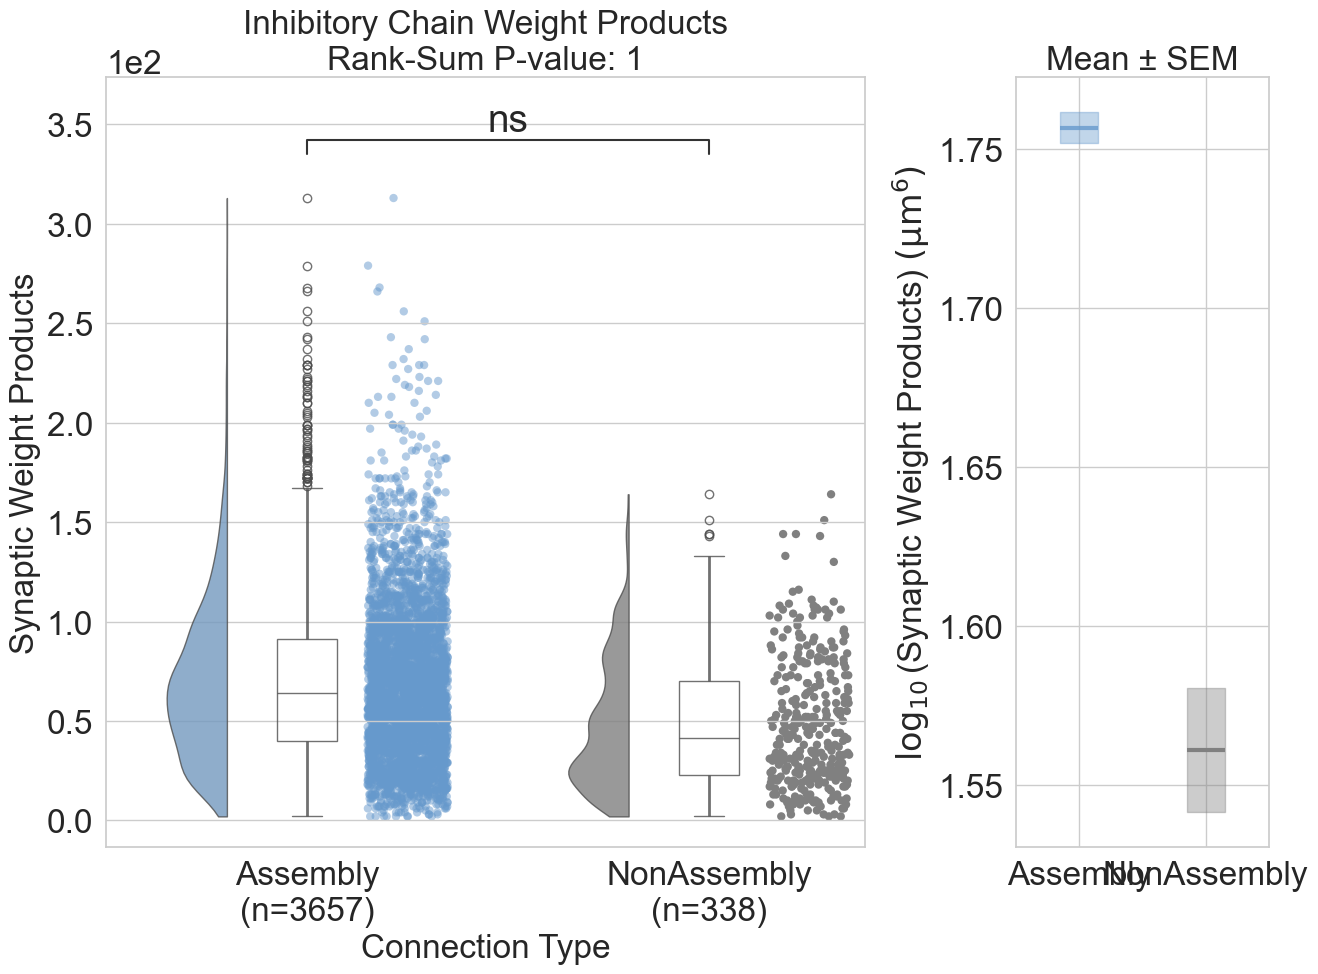

{'p_value': 1.0,
 'alternative': 'less',
 'statistic': 9.938967717392899,
 'n_shared': 3657,
 'n_disjoint': 338}

In [45]:
ranksum_signedrank_two_group_comparison(
        S_pairwise_chain['excitatory'],
        aggregation_method="connection",
        data_type="synaptic_count",
        non_zero=True,
        chain_test=True,
        chain_description="Excitatory",
        save=True,
        figure_name=f"Nonzero_Syn_Count_by_Conn_{chain_type}_Chain",
    )

ranksum_signedrank_two_group_comparison(
        S_pairwise_chain['inhibitory'],
        aggregation_method="connection",
        data_type="synaptic_count",
        non_zero=True,
        chain_test=True,
        chain_description="Inhibitory",
        save=True,
        figure_name=f"Nonzero_Syn_Count_by_Conn_{chain_type}_Chain",
    )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 3.262, P-value: 0.0005536

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.0005536
  Assembly median = 0.000291758, Nonassembly median = 0.000121566

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.000170192 : CI [7.29395e-05, 0.000255288]
    PS:       0.749 : CI [0.626, 0.857]   (δ=0.498 : CI [0.253, 0.714])
    Cohen's d: 0.796 : CI [0.524, 1.113]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.000170192 : CI [6.07829e-05, 0.000255288]
    PS:       0.749 : CI [0.615, 0.850]   (δ=0.498 : CI [0.230, 0.700])
    Cohen's d: 0.796 : CI [0.489, 1.079]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:5.

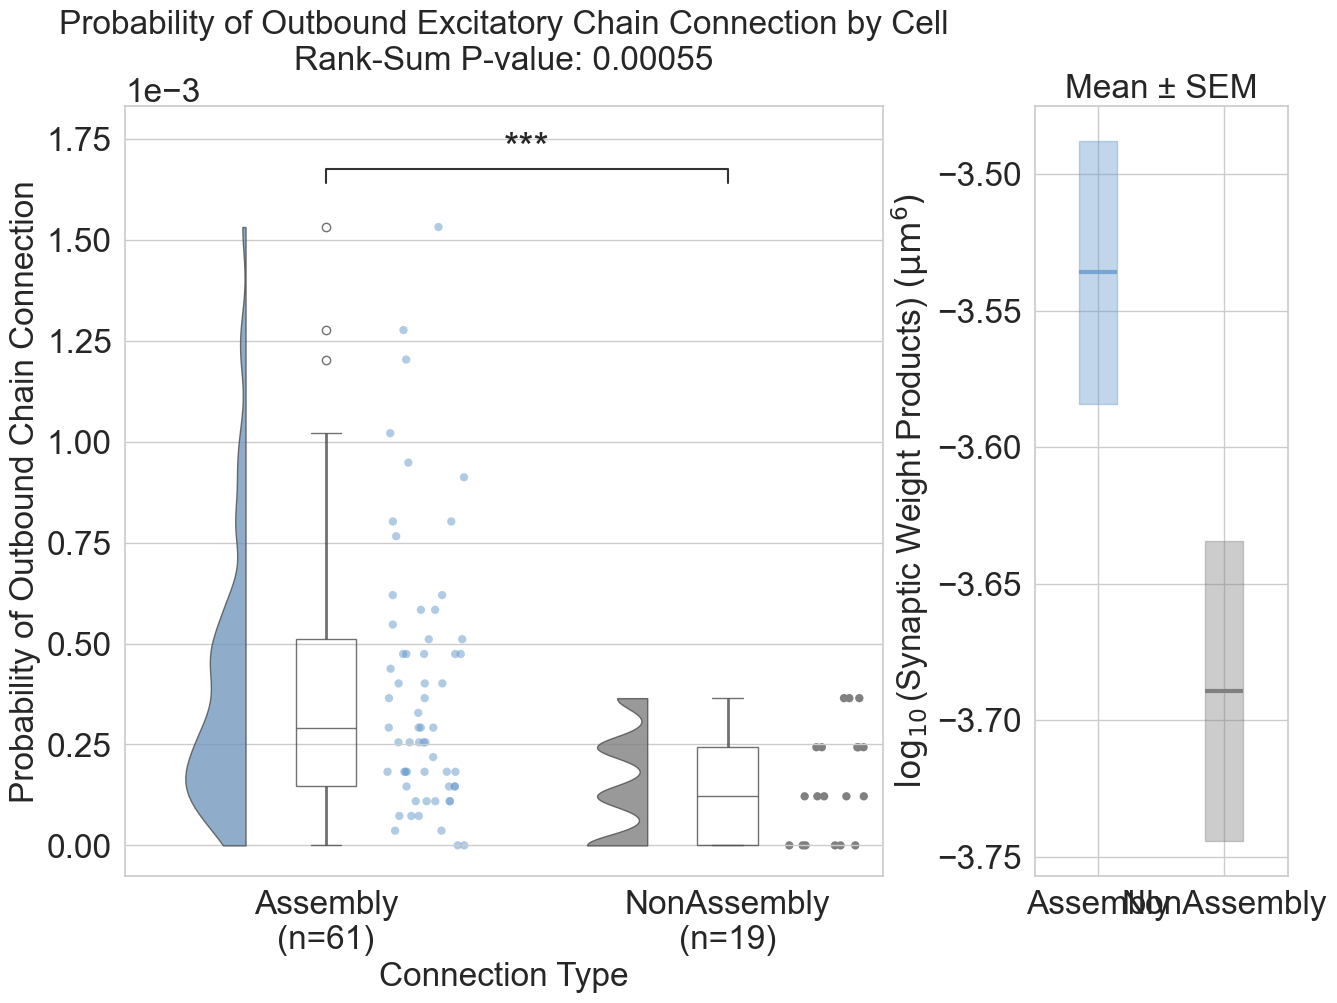

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.058, P-value: 0.9989

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9989
  Assembly median = 0.0360475, Nonassembly median = 0.0278485

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00925926 : CI [-0.015352, -0.00409952]
    PS:       0.267 : CI [0.152, 0.396]   (δ=-0.467 : CI [-0.696, -0.208])
    Cohen's d: -0.856 : CI [-1.355, -0.420]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00925926 : CI [-0.0155499, -0.00421261]
    PS:       0.267 : CI [0.156, 0.402]   (δ=-0.467 : CI [-0.688, -0.196])
    Cohen's d: -0.856 : CI [-1.336, -0.401]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:9.989e

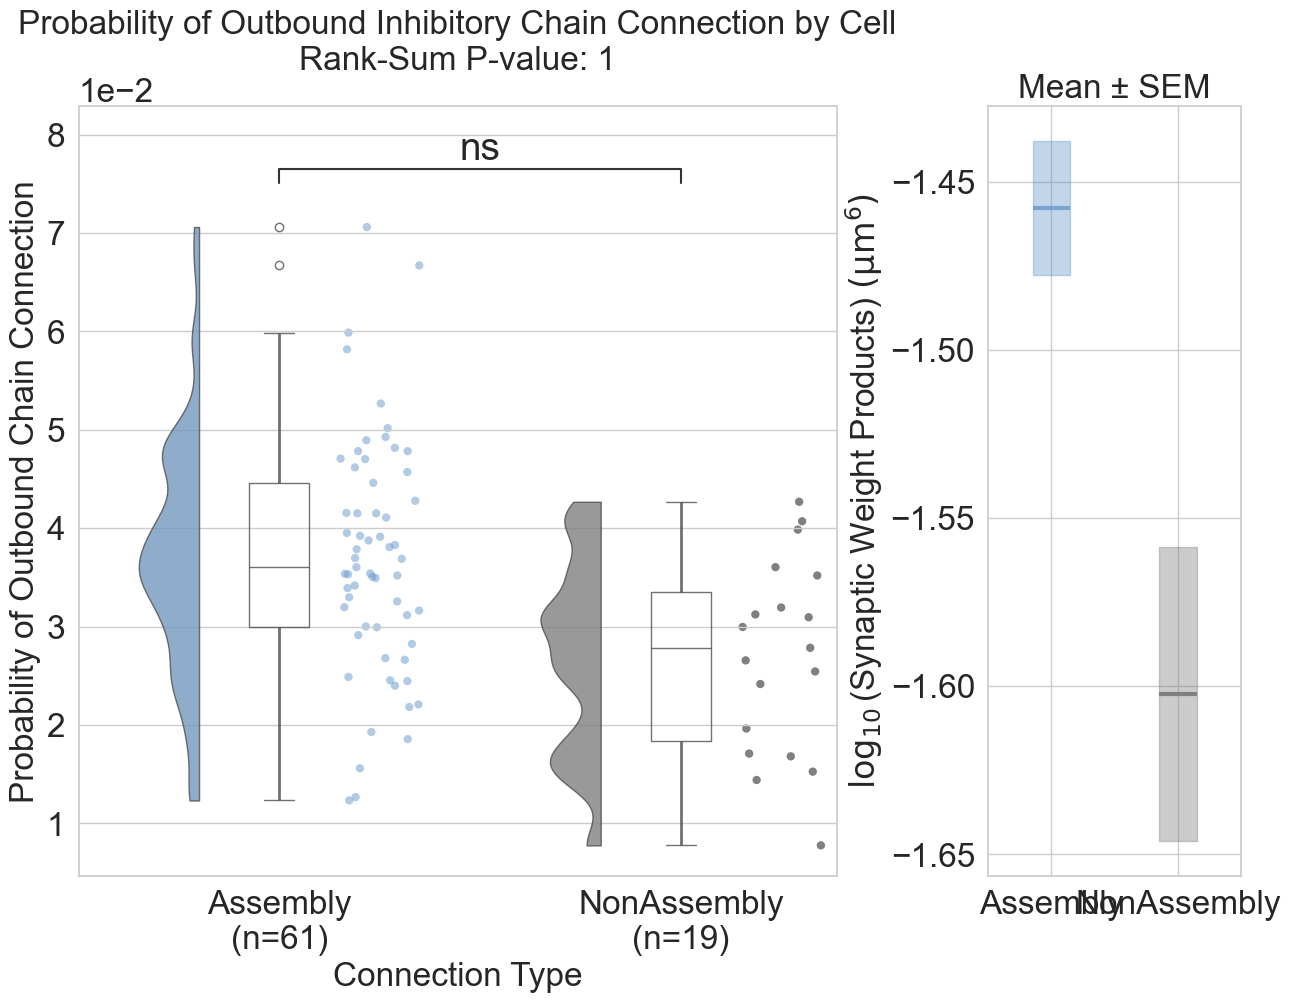

{'p_value': 0.9988868490225726,
 'alternative': 'less',
 'statistic': 3.0582547929835346,
 'n_shared': 61,
 'n_disjoint': 19}

In [46]:
ranksum_signedrank_two_group_comparison(B_out_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_out_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 2.247, P-value: 0.01231

[UNPAIRED] Effect sizes (pos = 'greater')  n1=59, n2=13
  Test p-value: 0.01231
  Assembly median = 9.48989e-05, Nonassembly median = 2.56461e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 4.39616e-05 : CI [-6.38114e-07, 7.33765e-05]
    PS:       0.700 : CI [0.495, 0.880]   (δ=0.400 : CI [-0.009, 0.760])
    Cohen's d: 0.267 : CI [-0.596, 1.302]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 4.39616e-05 : CI [-3.98326e-06, 7.17263e-05]
    PS:       0.700 : CI [0.463, 0.862]   (δ=0.400 : CI [-0.074, 0.724])
    Cohen's d: 0.267 : CI [-0.979, 1.107]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=59) vs. NonAssembly
(n=13): Custom statistical test, P_val:

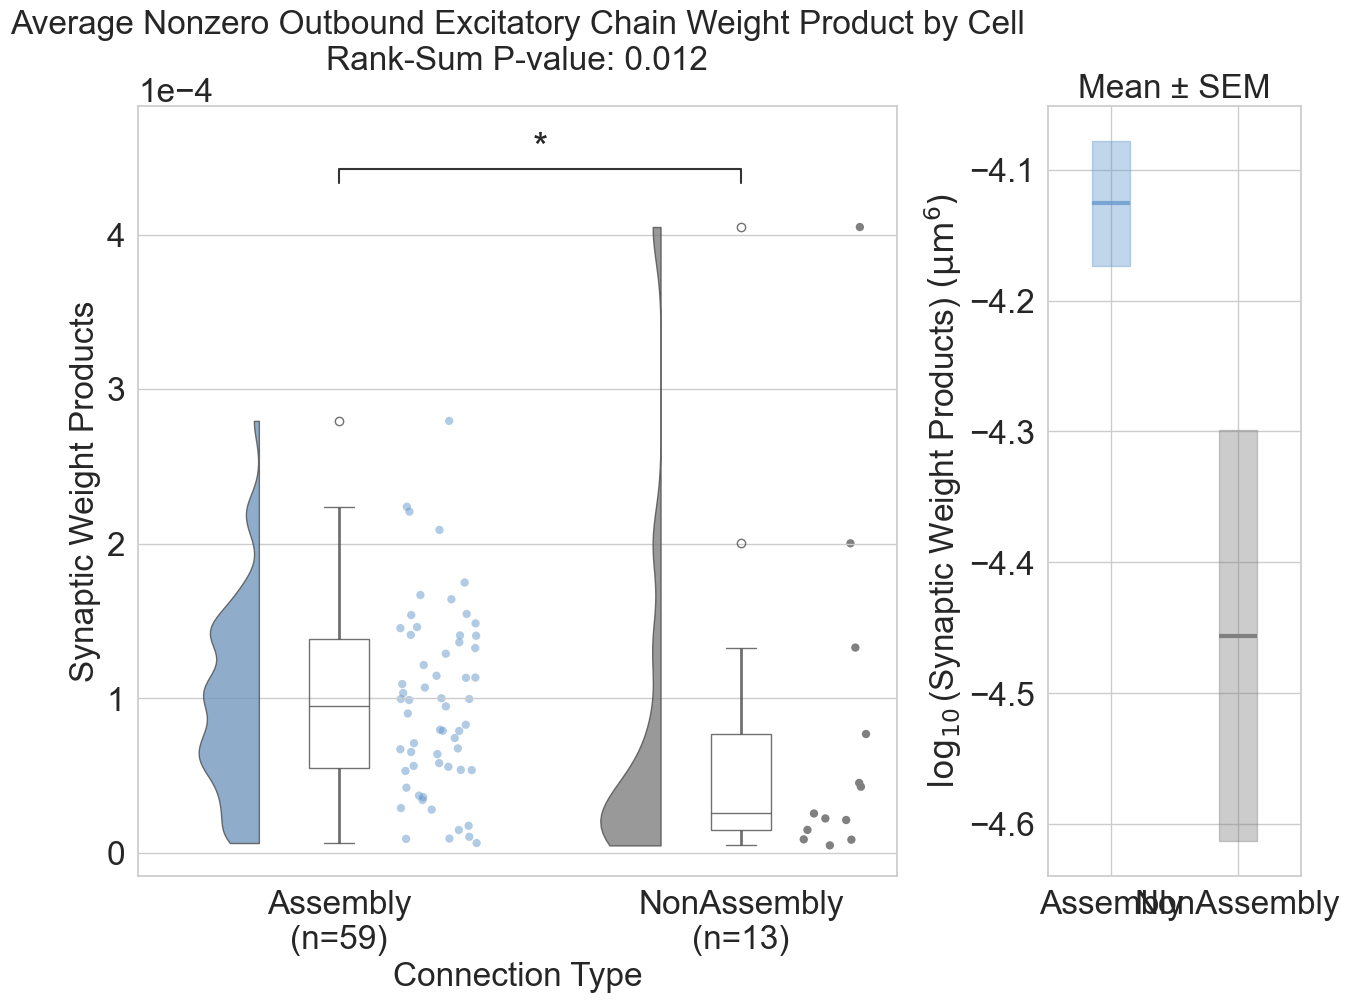

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.036, P-value: 0.9988

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9988
  Assembly median = 0.00107228, Nonassembly median = 0.000716544

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000328831 : CI [-0.000509095, -0.000162156]
    PS:       0.268 : CI [0.157, 0.391]   (δ=-0.463 : CI [-0.686, -0.218])
    Cohen's d: -0.822 : CI [-1.207, -0.484]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000328831 : CI [-0.000512294, -0.000165379]
    PS:       0.268 : CI [0.164, 0.399]   (δ=-0.463 : CI [-0.672, -0.203])
    Cohen's d: -0.822 : CI [-1.178, -0.453]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, 

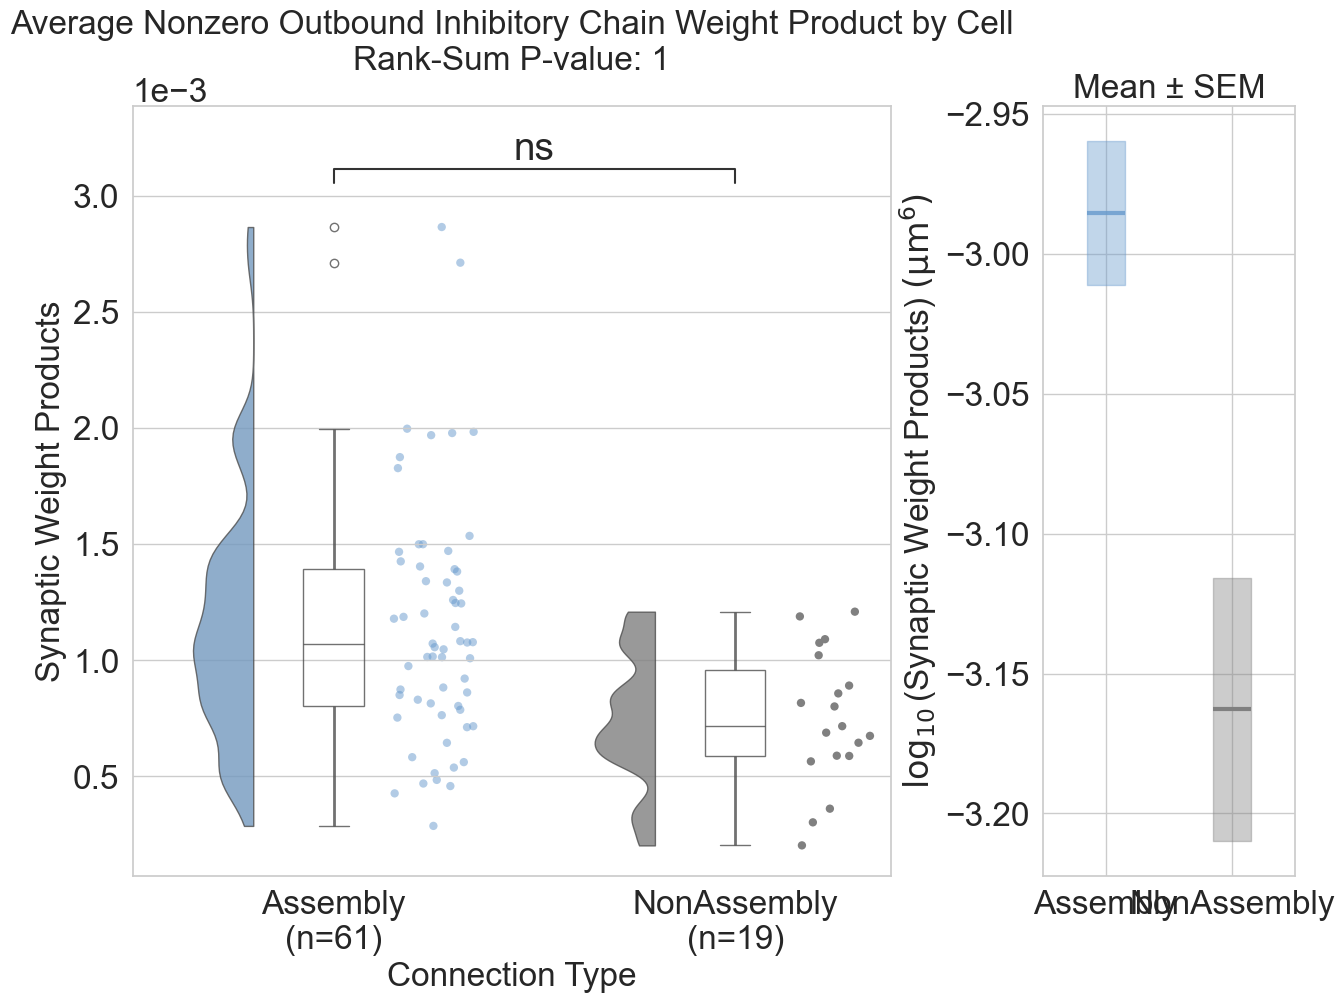

{'p_value': 0.9987998828413169,
 'alternative': 'less',
 'statistic': 3.0356429276010317,
 'n_shared': 61,
 'n_disjoint': 19}

In [47]:
ranksum_signedrank_two_group_comparison(W_out_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_out_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 1.296, P-value: 0.09755

[UNPAIRED] Effect sizes (pos = 'greater')  n1=59, n2=13
  Test p-value: 0.09755
  Assembly median = 2.35714, Nonassembly median = 2

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0.357143]
    PS:       0.615 : CI [0.449, 0.770]   (δ=0.231 : CI [-0.103, 0.540])
    Cohen's d: 0.411 : CI [-0.139, 0.935]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [-0.333333, -0.0714286]
    PS:       0.615 : CI [0.432, 0.757]   (δ=0.231 : CI [-0.137, 0.514])
    Cohen's d: 0.411 : CI [-0.239, 0.862]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=59) vs. NonAssembly
(n=13): Custom statistical test, P_val:9.755e-02


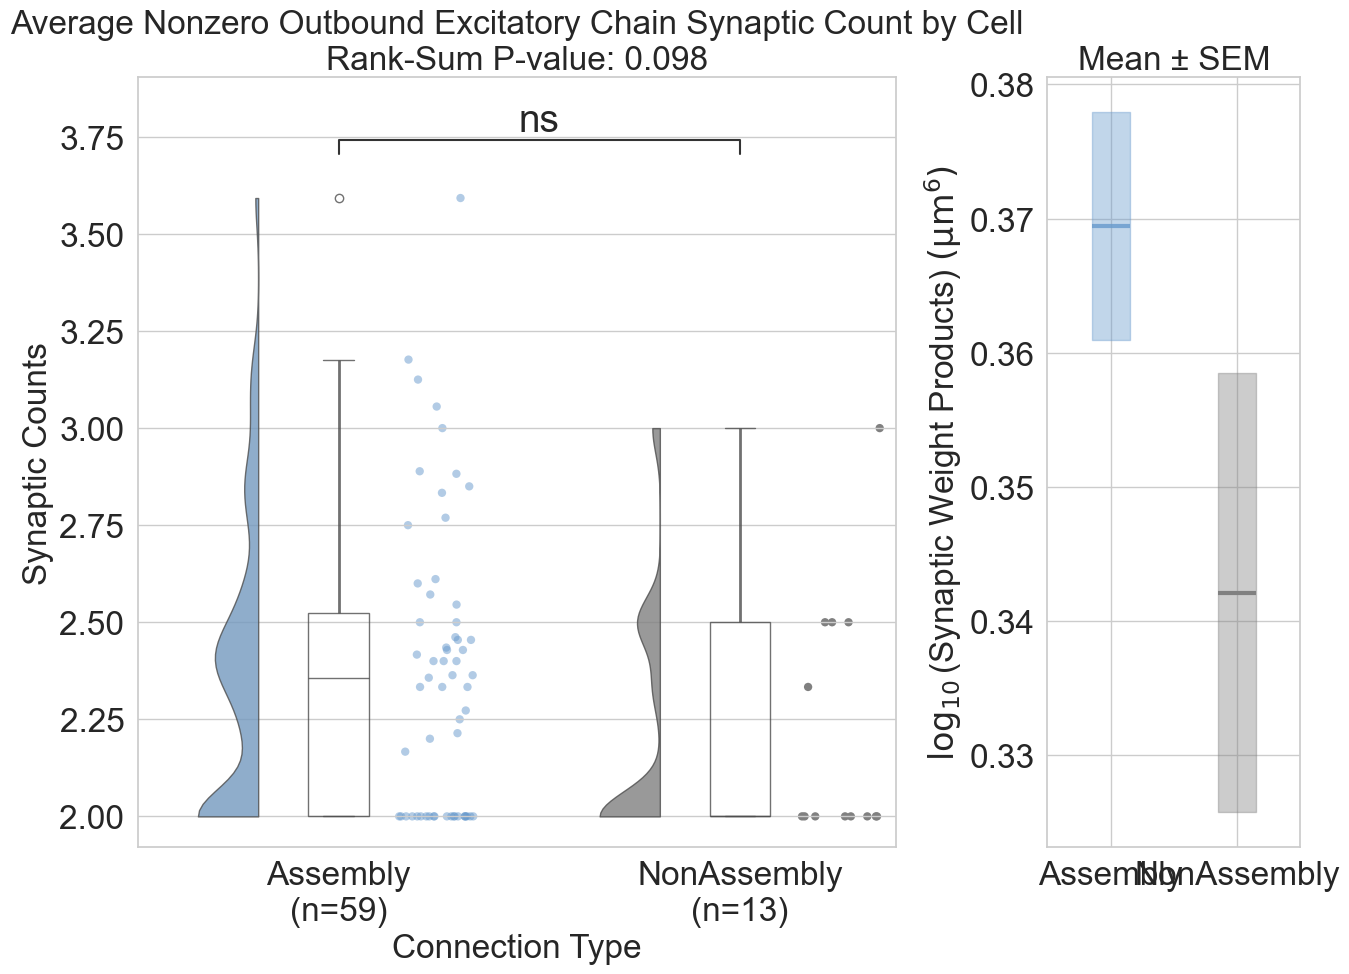

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.426, P-value: 0.9997

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9997
  Assembly median = 67.6833, Nonassembly median = 46.6471

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -19.9278 : CI [-29.7722, -9.92222]
    PS:       0.239 : CI [0.133, 0.357]   (δ=-0.523 : CI [-0.734, -0.286])
    Cohen's d: -0.905 : CI [-1.367, -0.514]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -19.9278 : CI [-29.9722, -10.3333]
    PS:       0.239 : CI [0.139, 0.368]   (δ=-0.523 : CI [-0.722, -0.263])
    Cohen's d: -0.905 : CI [-1.342, -0.490]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:9.997e-01


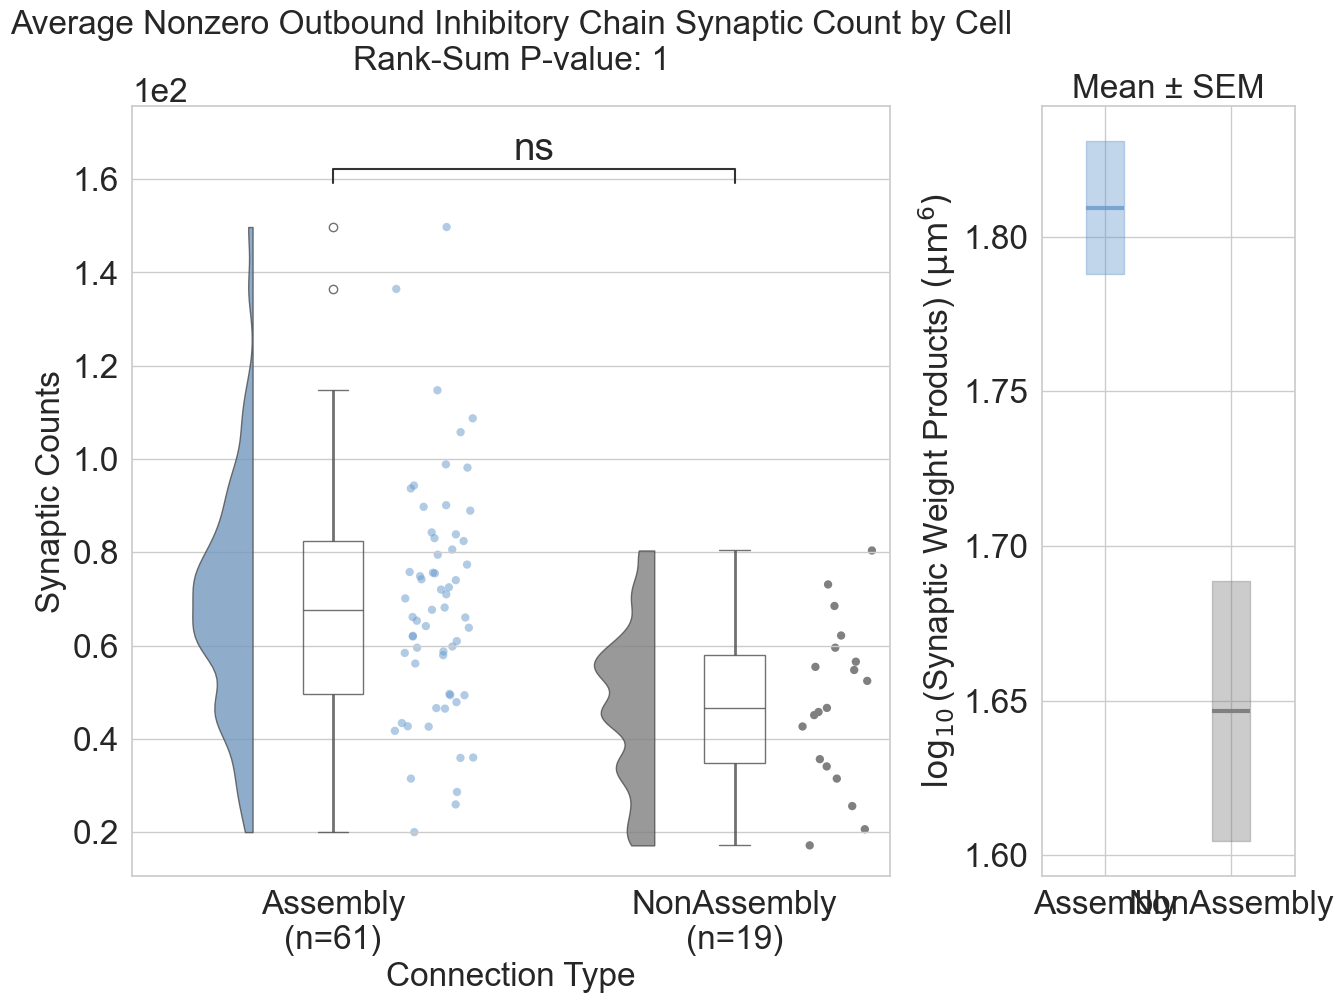

{'p_value': 0.9996933886564742,
 'alternative': 'less',
 'statistic': 3.425697605449209,
 'n_shared': 61,
 'n_disjoint': 19}

In [48]:
ranksum_signedrank_two_group_comparison(S_out_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_Syn_Count_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(S_out_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 3.256, P-value: 0.0005648

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.0005648
  Assembly median = 0.000328228, Nonassembly median = 0.000121566

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.000182349 : CI [7.29395e-05, 0.000316071]
    PS:       0.748 : CI [0.614, 0.865]   (δ=0.497 : CI [0.229, 0.730])
    Cohen's d: 0.830 : CI [0.449, 1.223]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.000182349 : CI [0, 0.000218818]
    PS:       0.748 : CI [0.602, 0.857]   (δ=0.497 : CI [0.204, 0.714])
    Cohen's d: 0.830 : CI [0.414, 1.191]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:5.648e-04


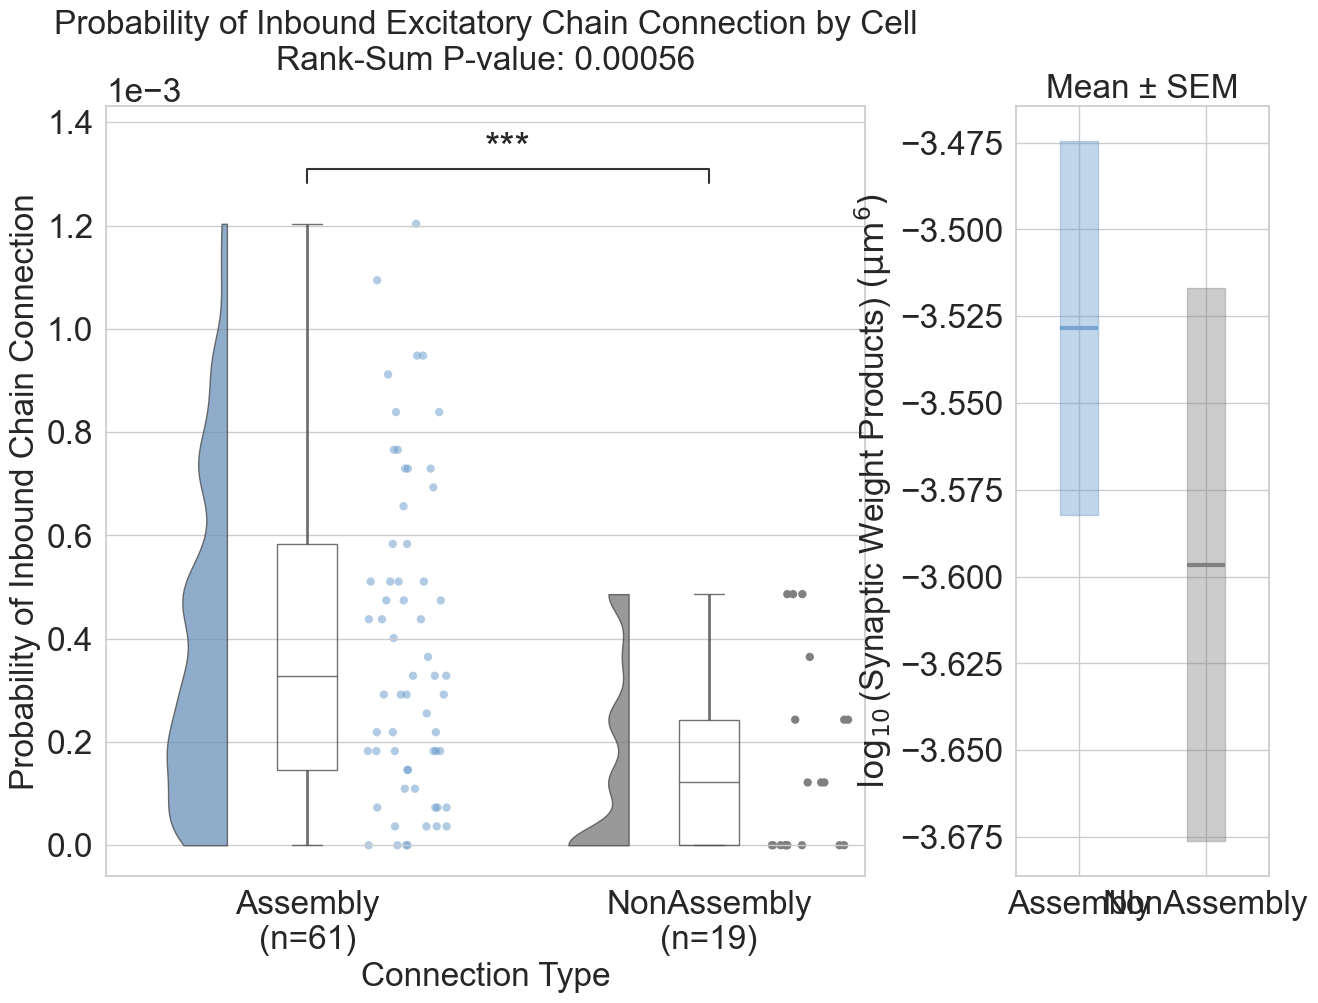

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.205, P-value: 0.9993

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9993
  Assembly median = 0.0382103, Nonassembly median = 0.0292621

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00995194 : CI [-0.0158609, -0.00497597]
    PS:       0.255 : CI [0.150, 0.378]   (δ=-0.489 : CI [-0.700, -0.244])
    Cohen's d: -0.930 : CI [-1.499, -0.450]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00995194 : CI [-0.0158326, -0.00496183]
    PS:       0.255 : CI [0.154, 0.384]   (δ=-0.489 : CI [-0.691, -0.232])
    Cohen's d: -0.930 : CI [-1.458, -0.412]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:9.993

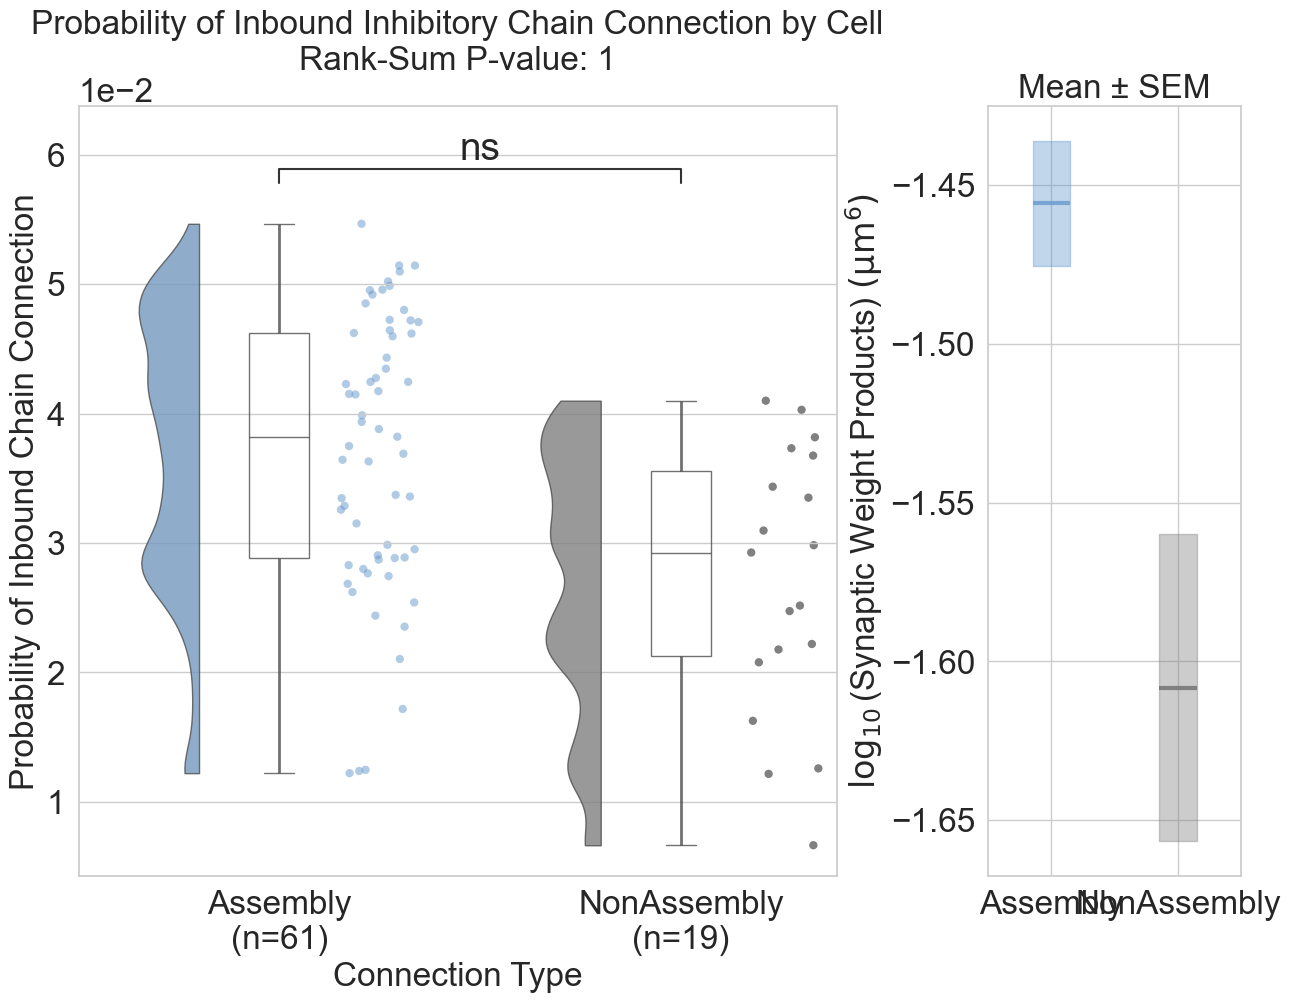

{'p_value': 0.9993252315247695,
 'alternative': 'less',
 'statistic': 3.2052319179698046,
 'n_shared': 61,
 'n_disjoint': 19}

In [49]:
ranksum_signedrank_two_group_comparison(B_in_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_in_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 1.32, P-value: 0.09348

[UNPAIRED] Effect sizes (pos = 'greater')  n1=57, n2=10
  Test p-value: 0.09348
  Assembly median = 8.04929e-05, Nonassembly median = 4.53525e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 2.80046e-05 : CI [-2.29605e-05, 5.48343e-05]
    PS:       0.632 : CI [0.411, 0.833]   (δ=0.263 : CI [-0.179, 0.667])
    Cohen's d: 0.213 : CI [-0.653, 1.078]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 2.80046e-05 : CI [-3.60781e-05, 5.37968e-05]
    PS:       0.632 : CI [0.365, 0.809]   (δ=0.263 : CI [-0.270, 0.618])
    Cohen's d: 0.213 : CI [-0.903, 0.941]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=57) vs. NonAssembly
(n=10): Custom statistical test, P_val:9

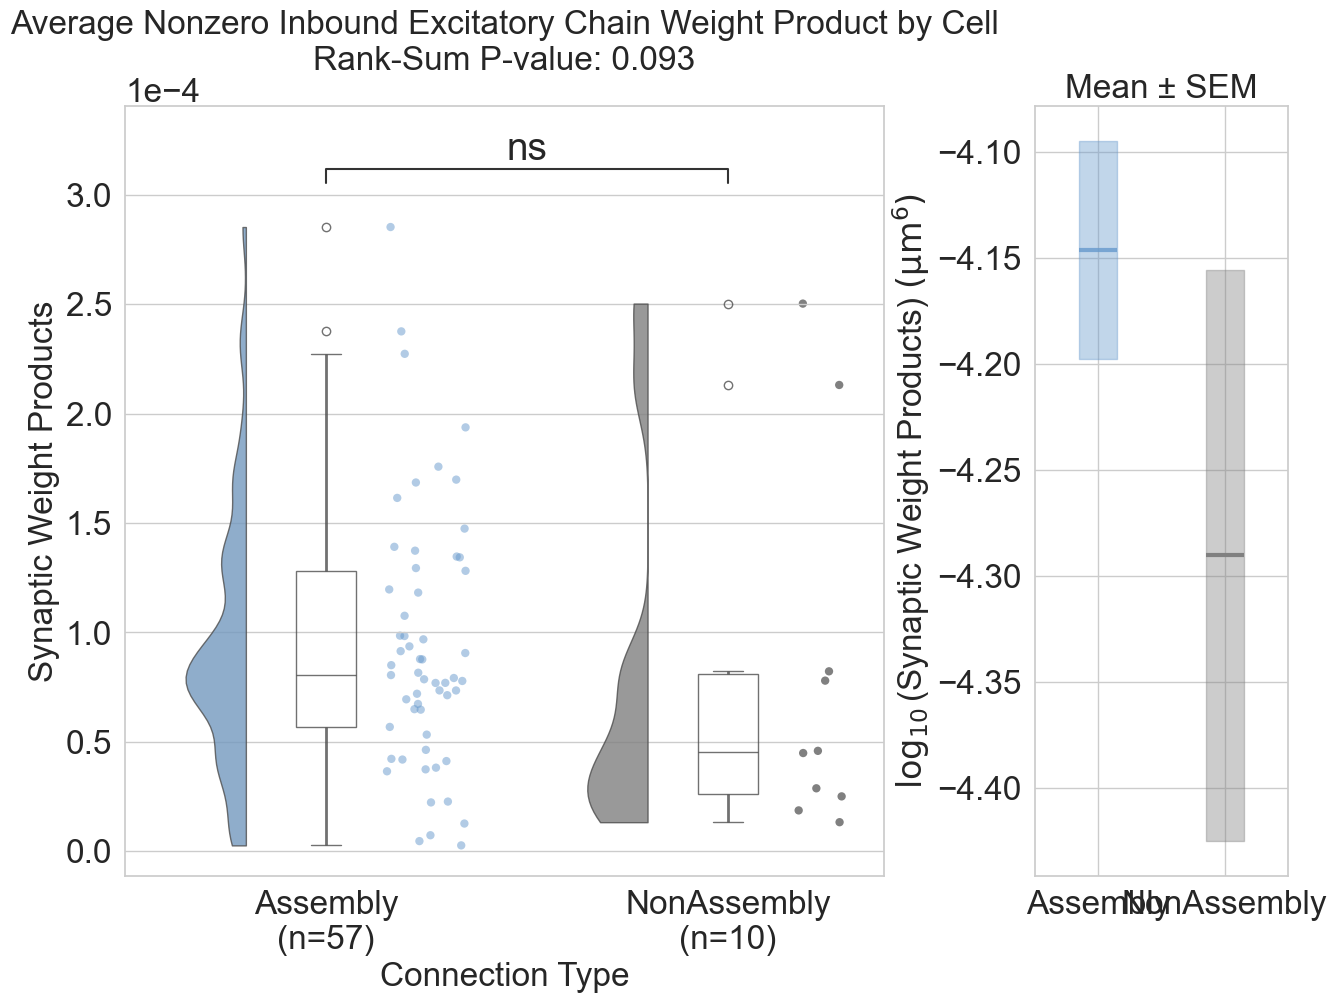

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 2.911, P-value: 0.9982

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9982
  Assembly median = 0.00112122, Nonassembly median = 0.0007304

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000387686 : CI [-0.000633229, -0.000151375]
    PS:       0.278 : CI [0.156, 0.412]   (δ=-0.444 : CI [-0.688, -0.177])
    Cohen's d: -0.827 : CI [-1.343, -0.370]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000387686 : CI [-0.000634345, -0.000151375]
    PS:       0.278 : CI [0.163, 0.421]   (δ=-0.444 : CI [-0.674, -0.158])
    Cohen's d: -0.827 : CI [-1.300, -0.340]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_

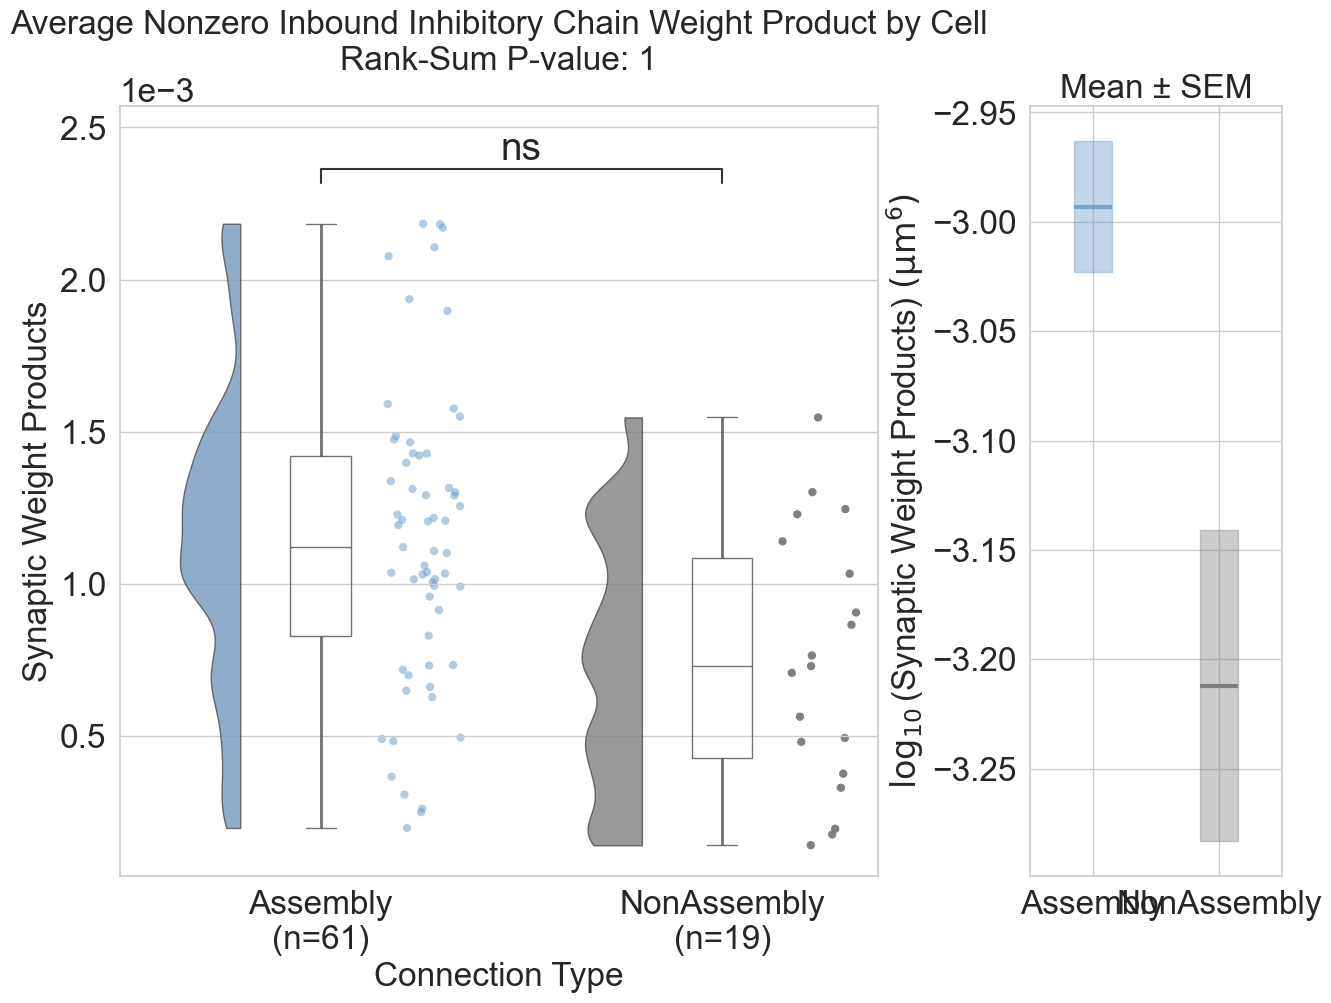

{'p_value': 0.9982002301032925,
 'alternative': 'less',
 'statistic': 2.911277667997265,
 'n_shared': 61,
 'n_disjoint': 19}

In [50]:
ranksum_signedrank_two_group_comparison(W_in_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_in_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 1.654, P-value: 0.04907

[UNPAIRED] Effect sizes (pos = 'greater')  n1=57, n2=10
  Test p-value: 0.04907
  Assembly median = 2.33333, Nonassembly median = 2

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.158333 : CI [0, 0.333333]
    PS:       0.665 : CI [0.497, 0.811]   (δ=0.330 : CI [-0.005, 0.623])
    Cohen's d: 0.586 : CI [0.134, 1.015]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.158333 : CI [0, 0.333333]
    PS:       0.665 : CI [0.481, 0.800]   (δ=0.330 : CI [-0.039, 0.600])
    Cohen's d: 0.586 : CI [0.086, 0.980]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=57) vs. NonAssembly
(n=10): Custom statistical test, P_val:4.907e-02


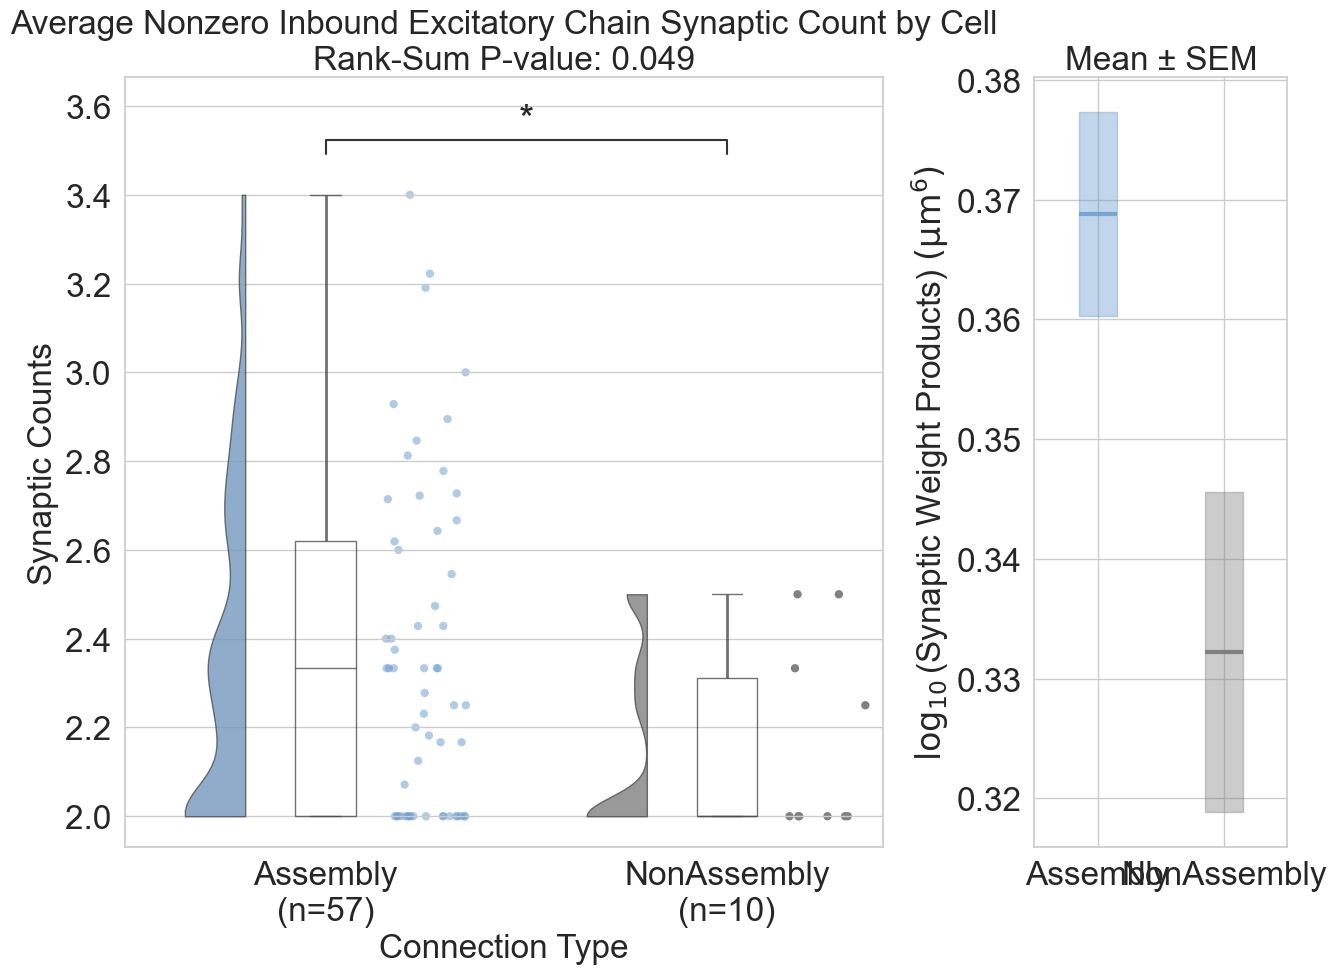

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 3.126, P-value: 0.9991

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=19
  Test p-value: 0.9991
  Assembly median = 69.9167, Nonassembly median = 43.5

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -22.0278 : CI [-33.9667, -9.05556]
    PS:       0.261 : CI [0.147, 0.393]   (δ=-0.477 : CI [-0.707, -0.213])
    Cohen's d: -0.899 : CI [-1.444, -0.422]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -22.0278 : CI [-33.9667, -9.15556]
    PS:       0.261 : CI [0.152, 0.402]   (δ=-0.477 : CI [-0.696, -0.196])
    Cohen's d: -0.899 : CI [-1.409, -0.398]
No common observations found for paired analysis.
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. NonAssembly
(n=19): Custom statistical test, P_val:9.991e-01


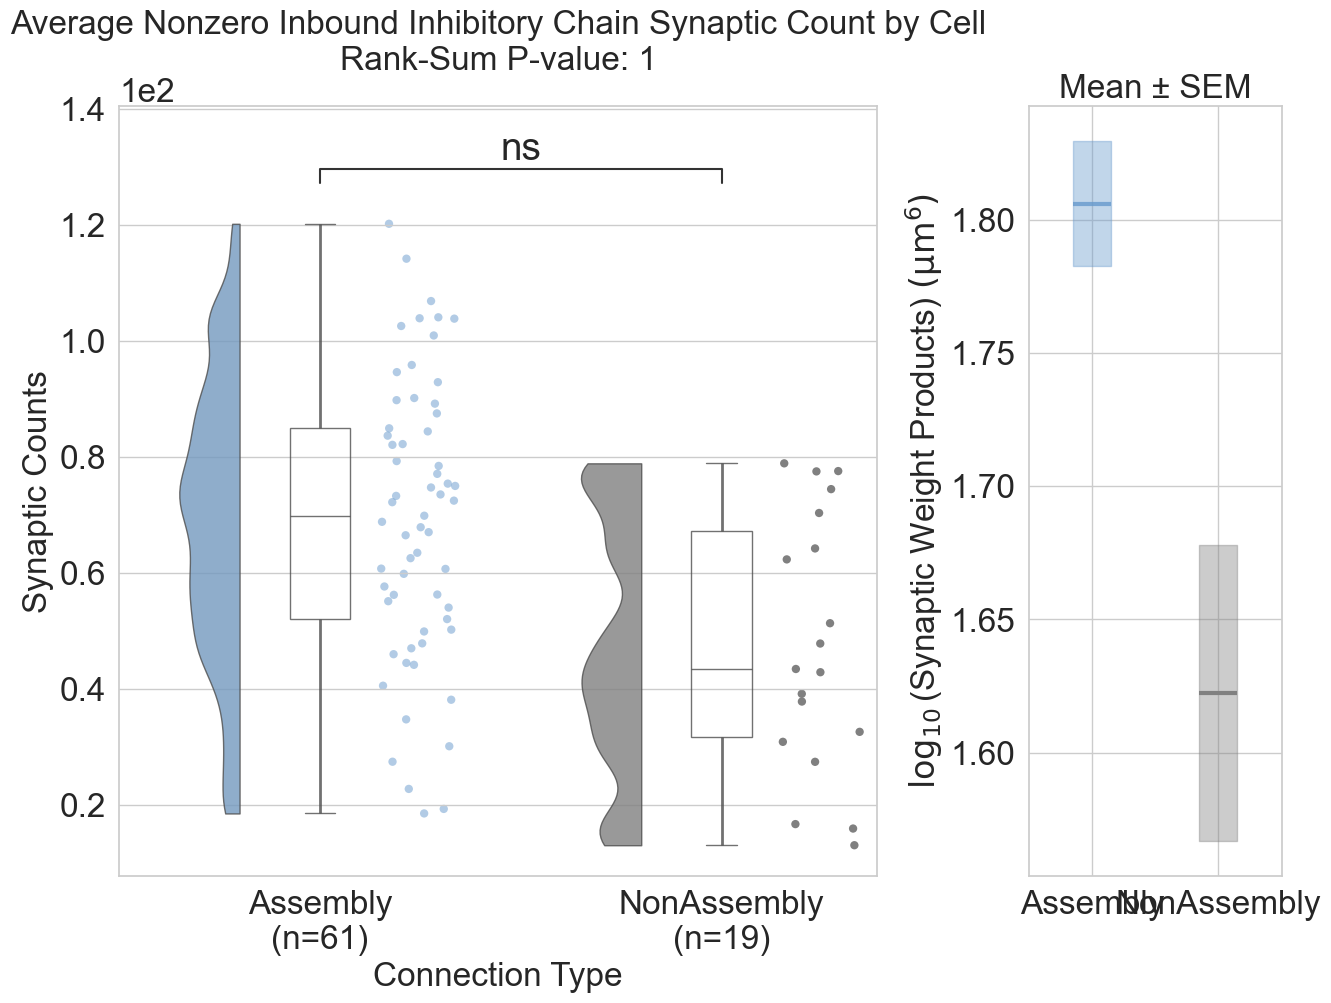

{'p_value': 0.9991142645293793,
 'alternative': 'less',
 'statistic': 3.126090389131044,
 'n_shared': 61,
 'n_disjoint': 19}

In [51]:
ranksum_signedrank_two_group_comparison(S_in_chain['excitatory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(S_in_chain['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_Syn_Count_I_Chain'
                                        )

# Extended Analysis

## Functions

In [ ]:
def perform_standard_em(x, K, seed=747, weights_init=None, means_init=None, precisions_init=None):
    """
    Estimate GMM's parameters by using the standard EM algorithm, with k-means clustering initialization.

    Args:
        x (1D numpy array): The observed data.
        K (int): The number of mixture components.
        seed (int): The random seed.
        weights_init (array): Optional initial weights for GMM components.
        means_init (array): Optional initial means for GMM components.
        precisions_init (array): Optional initial precisions for GMM components.

    Returns:
        results (dict): A dictionary containing estimated parameters (weights, means, std deviations).
    """
    # Convert input to DataFrame for compatibility with GaussianMixture
    x = pd.DataFrame(x)
    
    # Fit Gaussian Mixture Model
    model = mixture.GaussianMixture(
        n_components=K,
        random_state=seed,
        covariance_type='diag',
        weights_init=weights_init,
        means_init=means_init,
        precisions_init=precisions_init
    )
    model.fit(x)

    # Extract parameters and flatten
    weights = model.weights_.tolist()  # Flatten weights
    means = model.means_.flatten().tolist()  # Flatten means
    std = np.sqrt(model.covariances_.flatten()).tolist()  # Flatten std deviations

    results = {
        'pp': weights,
        'mu': means,
        'std': std
    }

    return results

def gmm_pdf_cdf(x, weights, means, std_devs):
    """
    Compute the PDF and CDF for a Gaussian Mixture Model (GMM).

    Parameters:
        x (np.ndarray): Points at which to evaluate the PDF and CDF.
        means (list): Means of the Gaussian components.
        stds (list): Standard deviations of the Gaussian components.
        weights (list): Weights of the Gaussian components.

    Returns:
        pdf (np.ndarray): PDF values for the GMM.
        cdf (np.ndarray): CDF values for the GMM.
    """
    pdf = np.zeros_like(x)
    cdf = np.zeros_like(x)
    for weight, mean, std_dev in zip(weights, means, std_devs):
        pdf += weight * norm.pdf(x, mean, std_dev)
        cdf += weight * norm.cdf(x, mean, std_dev)
    return pdf, cdf

def gmm_ppf(q, x, weights, means, std_devs):
    """
    Compute the PPF (percent-point function) for a Gaussian Mixture Model (GMM).

    Parameters:
        q (np.ndarray): Quantiles at which to compute the PPF.
        x (np.ndarray): Points used to evaluate the CDF.
        means (list): Means of the Gaussian components.
        stds (list): Standard deviations of the Gaussian components.
        weights (list): Weights of the Gaussian components.

    Returns:
        ppf (np.ndarray): PPF values for the GMM.
    """
    cdf_vals = gmm_pdf_cdf(x, weights, means, std_devs)[1]
    cdf_func = interp1d(cdf_vals, x, bounds_error=False, fill_value=(x[0], x[-1]))
    return cdf_func(q)

def hist_with_GMM_fit_plus_qqplot_with_decision_boundary(PSD, means, std_devs, weights,save=True):
    """
    Plots a histogram of the provided data along with a Gaussian Mixture Model (GMM) fit,
    includes the decision boundary, and generates a QQ plot comparing empirical and theoretical quantiles.

    Parameters:
    PSD (np.ndarray): An array of data values (e.g., log10(PSD) values) to be plotted and fitted with the GMM.
    means (np.ndarray): The means of the Gaussian components in the GMM.
    std_devs(np.ndarray): The standard deviations of the Gaussian components in the GMM.
    weights(np.ndarray): The weights of the Gaussian components in the GMM.

    """
    # Calculate the decision boundary (quadratic formula for intersection)
    a = (1 / (2 * std_devs[0]**2)) - (1 / (2 * std_devs[1]**2))
    b = -(means[0] / (std_devs[0]**2)) + (means[1] / (std_devs[1]**2))
    c = ((means[0]**2) / (2 * std_devs[0]**2)) - ((means[1]**2) / (2 * std_devs[1]**2)) - \
        np.log(std_devs[1] / std_devs[0]) - np.log(weights[1] / weights[0])
    roots = np.roots([a, b, c])
    decision_boundary = max(roots)  # Take the smaller root as the decision boundary
    print('Decision Boundary: ', decision_boundary)
    
    # Initialize plots
    fig = plt.figure(figsize=(24, 12))
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 2], wspace=0.3)
    
    # Set up styling
    hist = fig.add_subplot(gs[0])
    qq = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # Get x range
    xmin, xmax = np.min(PSD), np.max(PSD)
    x_range = np.linspace(xmin, xmax, 500)

    # Fit GMM
    pdf, cdf = gmm_pdf_cdf(x_range, weights, means, std_devs)

    # Histogram with GMM fit overlaid
    hist.hist(PSD, bins='rice', density=True, alpha=0.6, color= (.4, .6, .8, .5), label="Empirical Data")
    hist.plot(x_range, pdf, color="gold", alpha=0.5, linewidth = 5, label="GMM Fit")
    hist.axvline(decision_boundary, color="red", linestyle="--", linewidth = 5, label=f"Decision Boundary ({decision_boundary:.2g})")
    hist.set_title("Distribution of Post-Synaptic Densities", fontsize=32)
    hist.set_xlabel(r"$\log_{10}$(Post-Synaptic Density)", fontsize=32)
    hist.set_ylabel("Density", fontsize=32)
    hist.tick_params(axis='both', which='major', labelsize=32)
    hist.legend(prop = { "size": 22 })

    # Generate Quantiles of Empirical, Theoretical Distributions
    empirical_quantiles = np.percentile(PSD, np.linspace(0, 100, len(PSD)))
    theoretical_quantiles = gmm_ppf(np.linspace(0, 1, len(PSD)), x_range, weights, means, std_devs)

    # QQ Plot
    qq.plot(theoretical_quantiles, empirical_quantiles, 'o', color="grey", markersize=5, label='Quantiles')
    qq.plot([min(theoretical_quantiles), max(theoretical_quantiles)], 
             [min(theoretical_quantiles), max(theoretical_quantiles)], 'g--', label='Y=X', linewidth=4, color = (.4, .6, .8, .5))
    qq.set_xlabel('Theoretical Quantiles', fontsize=32)
    qq.set_ylabel('Empirical Quantiles', fontsize=32)
    qq.set_title('Quantile-Quantile Plot', fontsize=32)
    qq.tick_params(axis='both', which='major', labelsize=32)
    qq.legend(prop = { "size": 22 })

    plt.tight_layout()
    if save == True:
        save_figure("GMM_Fit_and_Decision_Boundary")
    plt.show()
    return decision_boundary

## Cotravel

In [ ]:
# full = {}

# for (pre, post), cotravel_nm in c.items():

#     # Detect connectivity
#     conn = b.get((pre, post), 0)

#     # Determine assembly connection type
#     if shared(pre, post, A):
#         ctype = "Shared"
#     elif disjoint(pre, post, A):
#         ctype = "Disjoint"
#     else:
#         ctype = "Other"

#     # Build record
#     full[(pre, post)] = {
#         "cotravel_nm": cotravel_nm,
#         "cotravel_um": cotravel_nm / 1000.0,
#         "connected": int(conn),
#         "ctype": ctype
#     }


# records = []

# for (pre, post), vals in full.items():
#     records.append({
#         "pre": pre,
#         "post": post,
#         "cotravel_um": vals["cotravel_um"],
#         "connected": vals["connected"],
#         "ctype": vals["ctype"]
#     })

# cotravel_df = pd.DataFrame(records)

In [ ]:
# nonzero_cotravel_df = cotravel_df[
#     (cotravel_df.cotravel_um > 0)
# ].copy()

# min_dists = []

# for _, row in nonzero_cotravel_df.iterrows():
#     md = compute_min_distance(row.pre, row.post)
#     min_dists.append(md)

# zero_conn = cotravel_df[
#     (cotravel_df.connected == 1) &
#     (cotravel_df.cotravel_um == 0)
# ].copy()

# print("Zero-cotravel connected pairs:")
# display(zero_conn)

# min_dists = []

# for _, row in zero_conn.iterrows():
#     md = compute_min_distance(row.pre, row.post)
#     min_dists.append(md)

# zero_conn["min_dist_nm"] = min_dists

# print(zero_conn[["pre", "post", "min_dist_nm"]])

# for _, row in zero_conn.iterrows():
#     print(f"Plotting zero-cotravel pair {row.pre} → {row.post}")
#     compute_cotravel_length(row.pre, row.post, plot=True)

Zero-cotravel connected pairs:


,pre,post,cotravel_um,connected,ctype
1436,864691132646510668,864691132598451263,0.0,1,Disjoint


                     pre                post  min_dist_nm
1436  864691132646510668  864691132598451263  9443.634311
Plotting zero-cotravel pair 864691132646510668 → 864691132598451263


In [ ]:
# # SUMMARY STATISTICS & SANITY CHECKS FOR COTRAVEL_DF

# print("-----------------------------------------------------")
# print("Basic Shapes & Counts")
# print("-----------------------------------------------------")
# print(f"Total pairs:           {len(cotravel_df)}")
# print(f"Connected pairs:       {cotravel_df.connected.sum()}")
# print(f"Non-connected pairs:   {len(cotravel_df) - cotravel_df.connected.sum()}")

# # Basic arrays
# all_vals = cotravel_df.cotravel_um.values
# nonzero_vals = cotravel_df[cotravel_df.cotravel_um > 0].cotravel_um.values

# C_all  = cotravel_df[cotravel_df.connected == 1].cotravel_um.values
# NC_all = cotravel_df[cotravel_df.connected == 0].cotravel_um.values

# C_nonzero  = cotravel_df[(cotravel_df.connected == 1) & (cotravel_df.cotravel_um > 0)].cotravel_um.values
# NC_nonzero = cotravel_df[(cotravel_df.connected == 0) & (cotravel_df.cotravel_um > 0)].cotravel_um.values

# def summary(name, arr):
#     print(f"\n{name}")
#     print("-----------------------------------------------------")
#     print(f"n = {len(arr)}")
#     if len(arr) == 0:
#         print("EMPTY GROUP")
#         return
#     print(f"min    = {arr.min():.2f}")
#     print(f"max    = {arr.max():.2f}")
#     print(f"median = {np.median(arr):.2f}")
#     print(f"mean   = {np.mean(arr):.2f}")
#     print(f"sd     = {np.std(arr):.2f}")


# print("\n==================== SUMMARY STATS ====================\n")

# summary("ALL cotravel values (including zeros)", all_vals)
# summary("NONZERO cotravel values ONLY", nonzero_vals)

# summary("CONNECTED pairs (all cotravel)", C_all)
# summary("NON-CONNECTED pairs (all cotravel)", NC_all)

# summary("CONNECTED pairs (nonzero cotravel only)", C_nonzero)
# summary("NON-CONNECTED pairs (nonzero cotravel only)", NC_nonzero)


# print("\n==================== SANITY CHECKS ====================\n")

# # ------------------------------------------------------
# # Check 1: Connected with ZERO cotravel (should be rare)
# # ------------------------------------------------------
# zero_conn_df = cotravel_df[
#     (cotravel_df.connected == 1) &
#     (cotravel_df.cotravel_um == 0)
# ][["pre", "post", "ctype"]]

# print(f"Connected pairs with ZERO cotravel: {len(zero_conn_df)}")
# if len(zero_conn_df) > 0:
#     display(zero_conn_df)


# # ------------------------------------------------------
# # Check 2: Non-connected with NONZERO cotravel
# # ------------------------------------------------------
# nonzero_nonconn_df = cotravel_df[
#     (cotravel_df.connected == 0) &
#     (cotravel_df.cotravel_um > 0)
# ][["pre", "post", "ctype"]]

# print(f"Non-connected pairs with NONZERO cotravel: {len(nonzero_nonconn_df)}")
# if len(nonzero_nonconn_df) > 0:
#     display(nonzero_nonconn_df)

-----------------------------------------------------
Basic Shapes & Counts
-----------------------------------------------------
Total pairs:           6320
Connected pairs:       140
Non-connected pairs:   6180

==================== SUMMARY STATS ====================


ALL cotravel values (including zeros)
-----------------------------------------------------
n = 6320
min    = 0.00
max    = 398.38
median = 31.14
mean   = 46.14
sd     = 50.42

NONZERO cotravel values ONLY
-----------------------------------------------------
n = 5072
min    = 0.41
max    = 398.38
median = 43.71
mean   = 57.49
sd     = 50.15

CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 140
min    = 0.00
max    = 398.38
median = 81.22
mean   = 93.59
sd     = 65.06

NON-CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 6180
min    = 0.00
max    = 388.56
median = 30.11
mean   = 45.06
sd     = 49.51

CONNECTED pairs (nonzero cotravel only)


,pre,post,ctype
1436,864691132646510668,864691132598451263,Disjoint


Non-connected pairs with NONZERO cotravel: 4933


,pre,post,ctype
0,864691132807412738,864691132919547915,Disjoint
1,864691132807412738,864691132636193294,Disjoint
2,864691132807412738,864691132669608977,Other
3,864691132807412738,864691132771662867,Shared
4,864691132807412738,864691132578187284,Other
...,...,...,...
6313,864691132728731632,864691132604748205,Shared
6314,864691132728731632,864691132667436992,Other
6315,864691132728731632,864691132619024839,Shared
6316,864691132728731632,864691132619337159,Shared


### Reconstruction Bias By Assembly Membership

In [ ]:
#comparison_dict

{'shared': {0: 7549.428,
  1: 8032.224,
  2: 5436.993,
  3: 4276.9885,
  4: 7990.132,
  5: 7516.57,
  6: 11482.734,
  7: 4234.6135,
  8: 5402.084,
  9: 13175.626,
  10: 4888.499,
  11: 5709.796,
  12: 11394.4,
  13: 3837.057,
  14: 10064.448,
  15: 5883.074,
  16: 4832.24,
  17: 6794.467,
  18: 5252.774,
  19: 9055.606,
  20: 9807.644,
  21: 7360.238,
  22: 3498.0915,
  23: 5768.1195,
  24: 7701.265,
  25: 7198.307,
  26: 4909.7855,
  27: 8293.627,
  28: 8993.091,
  29: 3417.35375,
  30: 5845.129,
  31: 4953.024,
  32: 8013.831,
  33: 4823.71,
  34: 11259.039,
  35: 7312.698,
  36: 7723.044,
  37: 6122.926,
  38: 4389.6545,
  39: 7950.003,
  40: 10114.835,
  41: 4889.884,
  42: 7447.245,
  43: 5948.31,
  44: 11131.218,
  45: 5223.035,
  46: 5526.54,
  47: 5526.966,
  48: 1813.421375,
  49: 12344.585,
  50: 4682.028,
  51: 14921.129,
  52: 9396.554,
  53: 10601.864,
  54: 7587.188,
  55: 6583.669,
  56: 10150.258,
  57: 4846.838,
  58: 7732.8125,
  59: 10402.018,
  60: 8102.6005},
 'dis

In [ ]:
# assembly_root_ids = set()
# for group, roots in assembly_to_root_ids.items():
#     if group != 'No A':
#         assembly_root_ids.update(roots)

# nonassembly_root_ids = set(assembly_to_root_ids.get('No A', []))

# assembly_pre = list(pre_root_ids & assembly_root_ids)
# nonassembly_pre = list(pre_root_ids & nonassembly_root_ids)

# print(f"Assembly pre-cells: {len(assembly_pre)}")
# print(f"Non-Assembly pre-cells: {len(nonassembly_pre)}")


# # ---------------------------
# # 1. Function: compute axon length from cached .npz
# # ---------------------------

# def compute_axon_length_from_npz(pre_id):
#     """
#     Computes total axonal length (µm) from cached .npz files in your format:
#         coords_ax = axonal vertices (nm)
#         edges_ax  = axonal edges
#     """
#     try:
#         npz = np.load(CACHE_DIR / f"{pre_id}.npz")
#         verts = npz["coords_ax"]      # (N,3) nm
#         edges = npz["edges_ax"]       # (M,2)

#         if verts.size == 0 or edges.size == 0:
#             return 0.0

#         segs = verts[edges]   # shape (M,2,3)
#         lengths_nm = np.linalg.norm(segs[:,0] - segs[:,1], axis=1)

#         return lengths_nm.sum() / 1000.0   # convert nm → µm

#     except Exception as e:
#         print(f"⚠️ Failed {pre_id}: {e}")
#         return 0.0


# # ---------------------------
# # 2. Compute axonal lengths for all pre-cells
# # ---------------------------

# records = []

# for cid in tqdm(pre_root_ids, desc="Computing axonal lengths"):
#     axlen = compute_axon_length_from_npz(cid)
#     group = "assembly" if cid in assembly_root_ids else "nonassembly"

#     records.append({
#         "cell_id": cid,
#         "group": group,
#         "axon_len_um": axlen
#     })

# axon_df = pd.DataFrame(records)

# # ---------------------------
# # 3. Separate into groups
# # ---------------------------

# assembly = axon_df[axon_df.group=="assembly"]["axon_len_um"].values
# no_assembly = axon_df[axon_df.group=="nonassembly"]["axon_len_um"].values

# mw_stat, mw_p = stats.ranksums(assembly, no_assembly, alternative="two-sided")

# comparison_dict = {
#     "shared":   dict(enumerate(assembly)),
#     "disjoint": dict(enumerate(no_assembly)),
# }

# boot = bootstrap_effects_and_p(
#     comparison_dict,
#     B=10_000,
#     alternative="greater",
#     paired=False,
#     non_zero=False,
# )

# # ---------------------------
# # 5. Raincloud plot
# # ---------------------------

# label_A = f"Assembly\n(n={len(assembly)})"
# label_N = f"Non-Assembly\n(n={len(no_assembly)})"

# plot_df = pd.DataFrame({
#     "Values": np.concatenate([assembly, no_assembly]),
#     "Group": [label_A]*len(assembly) + [label_N]*len(no_assembly)
# })

# plt.figure(figsize=(12, 10))
# sns.set_theme(style="whitegrid")

# ax = pt.RainCloud(
#     x="Group",
#     y="Values",
#     data=plot_df,
#     palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
#     width_viol=0.3,
#     alpha=0.8,
#     move=0.25,
#     point_size=6,
#     orient="v"
# )

# # Significance annotation
# pairs = [(label_A, label_N)]
# annot = Annotator(ax,
#                   pairs,
#                   data=plot_df,
#                   x="Group",
#                   y="Values",
#                   order=[label_A, label_N])

# annot.set_pvalues([mw_p])
# annot.configure(text_format="star",
#                 loc="inside",
#                 fontsize=30)
# annot.annotate()

# plt.title(f"Total Axonal Length (µm): Assembly vs Non-Assembly Pre Cells\nRank-Sum P-value: {mw_p:.2g}", fontsize=30)
# plt.xlabel("", fontsize=26)
# plt.ylabel("Axonal Length (µm)", fontsize=26)
# plt.xticks(fontsize=26)
# plt.yticks(fontsize=26)

# plt.tight_layout()
# save_figure('axonal_skeleton_reconstruction_length_by_assembly_membership')
# plt.show()
# plt.close()

Assembly pre-cells: 61
Non-Assembly pre-cells: 19


Computing axonal lengths: 100%|██████████| 80/80 [00:00<00:00, 1095.74it/s]


KeyError: 'assembly'

# Cotravel Between Shared and disjoint Connection Type

In [ ]:
# shared_pairs = []
# disjoint_pairs = []

# for (pre,post), cotravel in c.items():
#     # if cotravel == 0:
#     #     continue

#     if shared(pre, post, A):
#         shared_pairs.append((pre, post))

#     elif disjoint(pre, post, A):
#         disjoint_pairs.append((pre, post))

# print(f"Shared pairs: {len(shared_pairs)}")
# print(f"Disjoint pairs: {len(disjoint_pairs)}")

# # ------------------------------------------------------
# # 1. Extract cached cotravel values from dict c
# # ------------------------------------------------------

# shared_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_pairs], float)
# disjoint_cotravel = np.array([c[(pre, post)] for (pre, post) in disjoint_pairs], float)
# # nonzero
# # shared_cotravel = shared_cotravel[shared_cotravel > 0]
# # disjoint_cotravel = disjoint_cotravel[disjoint_cotravel > 0]
# # Convert nm → µm
# shared_cotravel = shared_cotravel / 1000.0
# disjoint_cotravel = disjoint_cotravel / 1000.0

# S = shared_cotravel
# D = disjoint_cotravel

# print(f"Median Shared Co-Travel:   {np.median(S):.2f} µm")
# print(f"Median Disjoint Co-Travel: {np.median(D):.2f} µm")


# # ------------------------------------------------------
# # 2. Stats 
# # ------------------------------------------------------

# mw_stat, mw_p = stats.ranksums(S, D, alternative="greater")

# comparison_dict = {
#     "shared":   dict(enumerate(S)),
#     "disjoint": dict(enumerate(D)),
# }

# boot = bootstrap_effects_and_p(
#     comparison_dict,
#     B=10_000,
#     alternative="greater",
#     paired=False,
#     non_zero=False,
# )

# # ------------------------------------------------------
# # 3. Raincloud Plot (inline)
# # ------------------------------------------------------

# label_S = f"Shared\n(n={len(S)})"
# label_D = f"Disjoint\n(n={len(D)})"

# plot_df = pd.DataFrame({
#     "Values": np.concatenate([S, D]),
#     "Group": [label_S]*len(S) + [label_D]*len(D)
# })

# plt.figure(figsize=(12, 10))
# sns.set_theme(style="whitegrid")

# ax = pt.RainCloud(
#     x="Group",
#     y="Values",
#     hue="Group",
#     data=plot_df,
#     palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
#     width_viol=0.3,
#     alpha=0.8,
#     move=0.25,
#     point_size=6,
#     orient="v"
# )

# pairs = [(label_S, label_D)]
# annot = Annotator(
#     ax,
#     pairs,
#     data=plot_df,
#     x="Group",
#     y="Values",
#     order=[label_S, label_D]
# )

# annot.set_pvalues([mw_p])
# annot.configure(
#     text_format="star",
#     loc="inside",
#     fontsize=30
# )

# annot.annotate() 

# plt.title(f"Co-Travel Distance (µm): Shared vs Disjoint Assembly Connections\nRank-Sum P-value: {mw_p:.2g}", fontsize=30)
# plt.xlabel("", fontsize=26)
# plt.ylabel("Co-Travel Length (µm)", fontsize=26)
# plt.xticks(fontsize=26)
# plt.yticks(fontsize=26)

# plt.tight_layout()
# save_figure('cotravel_by_shared_disjoint')
# plt.show()
# plt.close()

Shared pairs: 1610
Disjoint pairs: 2050
Median Shared Co-Travel:   36.08 µm
Median Disjoint Co-Travel: 35.58 µm


KeyError: 'assembly'

# Cotravel Between Two Assembly Cells versus Two Non-Assembly Cells

In [ ]:
# # ======================================================
# # Cotravel: Shared A vs Shared No A
# # (point estimates + bootstrap effect sizes)
# # ======================================================

# shared_a_pairs = []
# shared_no_a_pairs = []

# for (pre, post), cotravel in c.items():
#     # if cotravel == 0:
#     #     continue

#     if shared_a(pre, post, A):
#         shared_a_pairs.append((pre, post))

#     elif shared_no_a(pre, post, A):
#         shared_no_a_pairs.append((pre, post))

# print(f"Assembly pairs: {len(shared_a_pairs)}")
# print(f"No Assembly pairs: {len(shared_no_a_pairs)}")

# # ------------------------------------------------------
# # 1. Extract cached cotravel values from dict c
# # ------------------------------------------------------

# a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_a_pairs], float)
# no_a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_no_a_pairs], float)

# # nonzero (optional)
# # a_cotravel = a_cotravel[a_cotravel > 0]
# # no_a_cotravel = no_a_cotravel[no_a_cotravel > 0]

# # Convert nm → µm
# a_cotravel /= 1000.0
# no_a_cotravel /= 1000.0

# S = a_cotravel
# D = no_a_cotravel

# mw_stat, mw_p = stats.ranksums(S, D, alternative="greater")

# comparison_dict = {
#     "shared":   dict(enumerate(S)),
#     "disjoint": dict(enumerate(D)),
# }

# boot = bootstrap_effects_and_p(
#     comparison_dict,
#     B=10_000,
#     alternative="greater",
#     paired=False,
#     non_zero=False,
# )

# # (Optional explicit access if you want programmatic use)
# # boot["CI95_bca"]["HL"]
# # boot["CI95_bca"]["delta"]
# # boot["CI95_bca"]["d"]

# # ------------------------------------------------------
# # 4. Raincloud Plot (UNCHANGED)
# # ------------------------------------------------------

# label_S = f"Both A\n(n={len(S)})"
# label_D = f"Both No A\n(n={len(D)})"

# plot_df = pd.DataFrame({
#     "Values": np.concatenate([S, D]),
#     "Group": [label_S]*len(S) + [label_D]*len(D)
# })

# plt.figure(figsize=(12, 10))
# sns.set_theme(style="whitegrid")

# ax = pt.RainCloud(
#     x="Group",
#     y="Values",
#     hue="Group",
#     data=plot_df,
#     palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
#     width_viol=0.3,
#     alpha=0.8,
#     move=0.25,
#     point_size=6,
#     orient="v"
# )

# pairs = [(label_S, label_D)]
# annot = Annotator(
#     ax,
#     pairs,
#     data=plot_df,
#     x="Group",
#     y="Values",
#     order=[label_S, label_D]
# )

# annot.set_pvalues([mw_p])
# annot.configure(
#     text_format="star",
#     loc="inside",
#     fontsize=30
# )

# annot.annotate()

# plt.title(
#     f"Co-Travel Distance (µm): Shared A v Shared No A Connections\n"
#     f"Rank-Sum P-value: {mw_p:.2g}",
#     fontsize=30
# )

# plt.xlabel("", fontsize=26)
# plt.ylabel("Co-Travel Length (µm)", fontsize=26)
# plt.xticks(fontsize=26)
# plt.yticks(fontsize=26)

# plt.tight_layout()
# save_figure("cotravel_by_both_assembly_vs_both_no_assembly")
# plt.show()
# plt.close()


Assembly pairs: 3660
No Assembly pairs: 342


KeyError: 'assembly'

# Distance Analysis

In [ ]:
'''---------------------When using LSMM-------------------------------------'''
cell_table = data_a['structural']['pre_cell']

weight_matrix = data_a['structural']['summed_size_connectome']

In [ ]:
cell_table['pt_position_x_trafo'] = cell_table['pt_position_x_trafo']/1000
cell_table['pt_position_y_trafo'] = cell_table['pt_position_y_trafo']/1000
cell_table['pt_position_z_trafo'] = cell_table['pt_position_z_trafo']/1000

x_pos = np.mean(cell_table['pt_position_x_trafo'])   # Centroid of the graph - cartesian co-ordinates system hence, centroid = mean
y_pos = np.mean(cell_table['pt_position_y_trafo'])
z_pos = np.mean(cell_table['pt_position_z_trafo'])
cent_dist_no_a = []
cent_dist_a = []

x_pos, y_pos, z_pos

In [ ]:
n_assembly, n_nonassembly = 0, 0
for cell in mappings_a['assemblies_by_connectome_index']:
    if mappings_a['assemblies_by_connectome_index'][cell] == ['No A']:
        cent_dist_no_a.append(np.linalg.norm([cell_table['pt_position_x_trafo'][cell] -  x_pos, cell_table['pt_position_y_trafo'][cell] - y_pos], axis = 0))
        n_nonassembly += 1
    else:
        cent_dist_a.append(np.linalg.norm([cell_table['pt_position_x_trafo'][cell] - x_pos, cell_table['pt_position_y_trafo'][cell] -  y_pos], axis = 0))
        n_assembly += 1

In [ ]:
# Perform Test
stat, p_val = stats.ranksums(cent_dist_a, cent_dist_no_a)
print(f"Rank-Sum Test Statistic: {stat:.4g}, P-value: {p_val:.4g}")

# Calculate sample sizes
y_labels = [f"Assembly\n(n={n_assembly})", f"Non-Assembly\n(n={n_nonassembly})"]

# Build a frame for easier plotting
data = pd.DataFrame({
    "Values": np.concatenate([cent_dist_a, cent_dist_no_a]),
    "Group": [y_labels[0]] * n_assembly + [y_labels[1]] * n_nonassembly
})

# Set up the plot
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# --- Main plot (original RainCloud) ---
ax = pt.RainCloud(
    y="Values",
    x="Group",
    data= data,
    palette=[(.4, .6, .8, .5), 'grey'],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v",
)

# Annotate significance
pairs = [(y_labels[0], y_labels[1])]
annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
annot.set_pvalues([p_val])
annot.configure(text_format="star", loc="inside", fontsize=30)
annot.annotate()

# Axis title and labels
# ax.text(0.5, 1.08, "Distance from Centroid of Connectome Network", 
#         transform=ax.transAxes, ha='center', va='bottom', fontsize=30, fontweight='bold')
ax.text(0.5, 1.01, f"Rank-Sum P-value: {p_val:.2g}", 
        transform=ax.transAxes, ha='center', va='bottom', fontsize=30)
# ax.set_title(r'\textbf{Distance from Centroid of Connectome Network}' + f"\nRank-Sum P-value: {p_val:.2g}", size=30)
ax.set_xlabel("Assigned Assembly Status", size=26)
ax.set_ylabel(r"Euclidean Distance from Centroid ($\mu$m)", size=26)
ax.tick_params(labelsize=26)
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('draft_figures/a_vs_nona_distance_from_centroid.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Tail Analysis

In [ ]:
connection_data = []

for connection_type, connections in W_nonzero_pairwise.items():
    for (pre, post), size in connections.items():
        connection_data.append({
            "pre": pre,
            "post": post,
            "size": size,
            "connection_type": connection_type
        })

connections_df = pd.DataFrame(connection_data)

connections_df['size'] = connections_df['size']
connections_df['log_size'] = np.log10(connections_df['size'])

# expectation-maximization for GMM fit 
component_params = perform_standard_em(connections_df['log_size'], K=2, seed=747)

# GMM plot and fit evaluation
decision_boundary = hist_with_GMM_fit_plus_qqplot_with_decision_boundary(
    connections_df['log_size'],
    component_params['mu'], 
    component_params['std'],
    component_params['pp']
)

# print component parameters
print("GMM Parameters:")
print(component_params)

# get tail boundary and tail df
tail_minimum = decision_boundary

connections_df_tail = connections_df[connections_df['log_size'] >= tail_minimum]

# expected and observed proportions of connection types
categories = ['Shared', 'Disjoint']
shared_count = len(connections_df[connections_df['connection_type'] == 'shared'])
disjoint_count = len(connections_df[connections_df['connection_type'] == 'disjoint'])
total_count = shared_count + disjoint_count

prop_shared = shared_count / total_count
prop_disjoint = disjoint_count / total_count

tail_shared_count = len(connections_df_tail[connections_df_tail['connection_type'] == 'shared'])
tail_disjoint_count = len(connections_df_tail[connections_df_tail['connection_type'] == 'disjoint'])

total_tail_count = tail_shared_count + tail_disjoint_count
expected_shared = total_tail_count * prop_shared
expected_disjoint = total_tail_count * prop_disjoint

observed = [tail_shared_count, tail_disjoint_count]
expected = [expected_shared, expected_disjoint]
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

observed_props = [tail_shared_count / total_tail_count, tail_disjoint_count / total_tail_count]
expected_props = [prop_shared, prop_disjoint]

# frequency table
frequency_table = tabulate(
    [[cat, obs, f"{exp:.2f}"] for cat, obs, exp in zip(categories, observed, expected)],
    headers=["Connection Type", "Observed Frequency", "Expected Frequency"],
    tablefmt="pretty"
)

# Construct the proportion table
proportion_table = tabulate(
    [[cat, f"{obs:.4g}", f"{exp:.4g}"] for cat, obs, exp in zip(categories, observed_props, expected_props)],
    headers=["Connection Type", "Observed Proportion", "Expected Proportion"],
    tablefmt="pretty"
)

In [ ]:
print('Observed vs Expected Frequencies:')
print(frequency_table, "\n")

print("Observed vs Expected Proportions:")
print(proportion_table, "\n")

print(f"Chi-squared statistic: {chi2_stat:.4g}")
print(f"P-value: {p_value}")

# Subsampling:

In [ ]:
# ---------------- Helpers ----------------

def extract_vals_keys(dod):
    """Flatten dict-of-dicts into arrays (values) + arrays (keys) for each stratum."""
    vals, keys = {}, {}
    for k in ('shared', 'disjoint'):
        items = list(dod.get(k, {}).items())
        if items:
            k_arr, v_arr = zip(*items)         # tuples
            vals[k] = np.asarray(v_arr, dtype=float)
            keys[k] = np.asarray(k_arr, dtype=object)
        else:
            vals[k] = np.empty(0, float)
            keys[k] = np.empty(0, object)
    return vals, keys

def subsample_indices(n_avail, n_take, rng):
    if n_take > n_avail:
        raise ValueError(f"Requesting {n_take} from only {n_avail} available.")
    return rng.choice(n_avail, size=n_take, replace=False)

def build_dict_from_indices(keys, vals, idx_s, idx_d):
    """Rebuild dict-of-dicts for plotting/test function (keeps original (pre,post) keys)."""
    return {
        'shared':   {tuple(keys['shared'][i]): float(vals['shared'][i])     for i in idx_s},
        'disjoint': {tuple(keys['disjoint'][i]): float(vals['disjoint'][i]) for i in idx_d},
    }

def one_draw_stats(I_vals, n_shared, n_disjoint, rng):
    """One subsample: returns test results and effect sizes."""
    idx_s = subsample_indices(I_vals['shared'].size,   n_shared,   rng)
    idx_d = subsample_indices(I_vals['disjoint'].size, n_disjoint, rng)
    s = I_vals['shared'][idx_s]
    d = I_vals['disjoint'][idx_d]

    # Wilcoxon Rank-Sum Z (direction shared < disjoint)
    U_s, p_mw = stats.ranksums(s, d, alternative='less')
    n1, n2 = s.size, d.size
    delta = 1.0 - (2.0 * U_s) / (n1 * n2)

    # Other effect sizes
    d_cohen = cohens_d(s, d, alternative='less')
    HL = hodges_lehmann(s, d, alternative='less')
    PS, _ = ps_and_delta(s, d, alternative='less')

    return {
        "p": p_mw,
        "delta": delta,
        "d": d_cohen,
        "HL": HL,
        "PS": PS,
        "idx_s": idx_s,
        "idx_d": idx_d,
        "s": s,
        "d_vals": d,
    }


def resample_many(I_vals, n_shared, n_disjoint, B=10_000, rng=None):
    """Repeat subsampling many times: return arrays of effect sizes + p-values."""
    if rng is None:
        rng = default_rng()
    results = {"p": [], "delta": [], "d": [], "HL": [], "PS": []}
    for b in range(B):
        out = one_draw_stats(I_vals, n_shared, n_disjoint, rng)
        for k in results:
            results[k].append(out[k])
    return {k: np.array(v) for k, v in results.items()}


# ---------------- Subsampling Workflow ----------------

target = {'shared': len(W_pairwise_chain['excitatory']['shared']), 'disjoint': len(W_pairwise_chain['excitatory']['disjoint'])}

# Flatten once
I_vals, I_keys = extract_vals_keys(W_pairwise_chain['inhibitory'])
# ---- One subsample ----
rng = default_rng(747)
one = one_draw_stats(I_vals, target['shared'], target['disjoint'], rng)
I_sub_for_plot = build_dict_from_indices(I_keys, I_vals, one['idx_s'], one['idx_d'])

print("SUBSAMPLED")
ranksum_signedrank_two_group_comparison(
    I_sub_for_plot,
    aggregation_method='connection',
    data_type='summed_psd',
    non_zero=True,
    chain_test=True,
    chain_description="Inhibitory",
    save=True,
    figure_name='Subsampled_Nonzero_PSD_by_Conn_I_Chain',
    title_prefix="Subsampled "
)

# ---- Many subsamples ----
B = 10_000
res = resample_many(I_vals, target['shared'], target['disjoint'], B=B, rng=rng)

alpha = 0.05
prop_sig = (res['p'] < alpha).mean()

def summarize(arr):
    return np.median(arr), np.percentile(arr, [2.5, 97.5])

HL_med, HL_ci = summarize(res['HL'])
PS_med, PS_ci = summarize(res['PS'])
d_med, d_ci = summarize(res['d'])
delta_med, delta_ci = summarize(res['delta'])

print(f"\nResampling (B={B}) summary, resampling percentile CIs")
print(f"Proportion significant (α={alpha}): {prop_sig:.3g}")
print(f"HL shift median: {HL_med:.3g} (95% CI {HL_ci[0]:.3g}–{HL_ci[1]:.3g})")
print(f"PS median: {PS_med:.3g} (95% CI {PS_ci[0]:.3g}–{PS_ci[1]:.3g})")
print(f"Cohen's d median: {d_med:.3g} (95% CI {d_ci[0]:.3g}–{d_ci[1]:.3g})")
print(f"δ median: {delta_med:.3g} (95% CI {delta_ci[0]:.3g}–{delta_ci[1]:.3g})")